In [ ]:
# Imports
import os
os.environ['OMP_NUM_THREADS'] = '1'

from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Union, Any
import json
import pickle
import warnings
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, mannwhitneyu, gaussian_kde, ttest_ind, f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Statistical packages
import pingouin as pg
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

In [30]:
def run_repeated_measures_anova_sd(self) -> Dict:
        """Run repeated measures ANOVA for stride length variability with covariates using pingouin."""
        # Prepare long-format data
        long_rows = []
        
        for _, row in self.filtered_df.iterrows():
            subject_id = row.name
            for col in self.filtered_df.columns:
                if '_sd_' in col and '_const' in col:
                    parts = col.split('_')
                    if len(parts) >= 3:
                        trial_type = parts[0]
                        condition = parts[2]
                        
                        if pd.notna(row[col]):
                            long_rows.append({
                                'subject': subject_id,
                                'trial_type': trial_type,
                                'condition': condition,
                                'stride_length_variability': row[col],
                                'age': row.get('age', np.nan),
                                'motor_noise': row.get('mot_noise', np.nan),
                                'pref_asymmetry': row.get('pref_asymmetry', np.nan)
                            })
        
        df_long = pd.DataFrame(long_rows).dropna()
        
        if df_long.empty:
            return {'error': 'No valid stride length variability data for analysis'}
        
        results = {}
        
        # Basic repeated measures ANOVA (without covariates)
        try:
            # Main effect of trial type
            if len(df_long['trial_type'].unique()) > 1:
                aov_trial = pg.rm_anova(data=df_long, dv='stride_length_variability', 
                                       within='trial_type', subject='subject', detailed=True)
                results['trial_type_effect'] = {
                    'F': float(aov_trial['F'].iloc[0]),
                    'p_value': float(aov_trial['p-unc'].iloc[0]),
                    'effect_size': float(aov_trial['ng2'].iloc[0])
                }
            
            # Main effect of condition
            if len(df_long['condition'].unique()) > 1:
                aov_condition = pg.rm_anova(data=df_long, dv='stride_length_variability', 
                                           within='condition', subject='subject', detailed=True)
                results['condition_effect'] = {
                    'F': float(aov_condition['F'].iloc[0]),
                    'p_value': float(aov_condition['p-unc'].iloc[0]),
                    'effect_size': float(aov_condition['ng2'].iloc[0])
                }
            
            # Interaction effect
            if len(df_long['trial_type'].unique()) > 1 and len(df_long['condition'].unique()) > 1:
                aov_interaction = pg.rm_anova(data=df_long, dv='stride_length_variability', 
                                             within=['trial_type', 'condition'], 
                                             subject='subject', detailed=True)
                interaction_row = aov_interaction[aov_interaction['Source'].str.contains('trial_type \\* condition')]
                if not interaction_row.empty:
                    results['interaction_effect'] = {
                        'F': float(interaction_row['F'].iloc[0]),
                        'p_value': float(interaction_row['p-unc'].iloc[0]),
                        'effect_size': float(interaction_row['ng2'].iloc[0])
                    }
        except Exception as e:
            results['basic_anova_error'] = str(e)
        
        # Covariate analysis
        try:
            # Check which covariates are available
            available_covariates = []
            if 'age' in df_long.columns and df_long['age'].notna().sum() > 0:
                available_covariates.append('age')
            if 'motor_noise' in df_long.columns and df_long['motor_noise'].notna().sum() > 0:
                available_covariates.append('motor_noise')
            if 'pref_asymmetry' in df_long.columns and df_long['pref_asymmetry'].notna().sum() > 0:
                available_covariates.append('pref_asymmetry')
            
            if available_covariates:
                results['ancova_covariates'] = available_covariates
                
                # Covariate correlations
                for cov in available_covariates:
                    cov_corr = df_long.groupby('subject').agg({
                        'stride_length_variability': 'mean',
                        cov: 'first'
                    }).reset_index()
                    if len(cov_corr) > 5:
                        from scipy.stats import pearsonr
                        r, p = pearsonr(cov_corr[cov], cov_corr['stride_length_variability'])
                        results[f'{cov}_covariate_effect'] = {
                            'correlation': float(r),
                            'p_value': float(p),
                            'interpretation': f'{cov} effect on stride length variability'
                        }
                
                # Mixed effects analysis
                try:
                    import statsmodels.api as sm
                    from statsmodels.formula.api import mixedlm
                    
                    covariate_terms = ' + '.join(available_covariates)
                    formula = f"stride_length_variability ~ trial_type * condition + {covariate_terms}"
                    
                    model = mixedlm(formula, df_long, groups=df_long['subject'])
                    fitted_model = model.fit()
                    
                    covariate_effects = {}
                    for cov in available_covariates:
                        if cov in fitted_model.params.index:
                            covariate_effects[f'{cov}_effect'] = {
                                'coefficient': float(fitted_model.params[cov]),
                                'p_value': float(fitted_model.pvalues[cov]),
                                'confidence_interval': [float(fitted_model.conf_int().loc[cov, 0]), 
                                                      float(fitted_model.conf_int().loc[cov, 1])],
                                'interpretation': f'Change in stride variability per unit increase in {cov}'
                            }
                    
                    results['mixed_effects_covariates'] = covariate_effects
                    
                except Exception as e:
                    results['mixed_effects_error'] = str(e)
            
        except Exception as e:
            results['ancova_error'] = str(e)
        
        # Add descriptive statistics
        results['descriptive_stats'] = {
            'n_subjects': len(df_long['subject'].unique()),
            'n_observations': len(df_long),
            'stride_variability_overall': float(df_long['stride_length_variability'].mean()),
            'std_stride_variability_overall': float(df_long['stride_length_variability'].std()),
            'by_trial_type': df_long.groupby('trial_type')['stride_length_variability'].agg(['mean', 'std', 'count']).to_dict(),
            'by_condition': df_long.groupby('condition')['stride_length_variability'].agg(['mean', 'std', 'count']).to_dict()
        }
        
        return results# CORRECTED MOTOR LEARNING ANALYSIS PIPELINE
# ============================================
# This corrected version fixes structural issues and improves organization

# ==============================================================================
# CONFIGURATION AND DATA STRUCTURES
# ==============================================================================

@dataclass
class AnalysisConfig:
    """Centralized configuration for all analysis parameters."""
    
    # Directories
    base_output_dir: Path = Path('motor_learning_output')
    
    # Thresholds
    min_complete_strides: int = 20
    motor_noise_strides: int = 20
    motor_noise_threshold: float = 0.3
    success_rate_threshold: float = 0.68
    target_size_threshold: float = 0.31
    max_strides_threshold: int = 415
    
    # Visualization
    figure_dpi: int = 300
    alpha_level: float = 0.05
    age_bins: List[int] = field(default_factory=lambda: [7, 10, 13, 16, 18])
    age_labels: List[str] = field(default_factory=lambda: ['7-10', '10-13', '13-16', '16-18'])
    
    # Trial mappings
    trial_type_mapping: Dict[str, str] = field(default_factory=lambda: {
        'primer': 'vis1',
        'trial': 'invis',
        'vis': 'vis2',
        'pref': 'pref'
    })
    
    def __post_init__(self):
        """Create directory structure."""
        self.figures_dir = self.base_output_dir / 'figures'
        self.individual_plots_dir = self.figures_dir / 'individual_plots'
        self.population_plots_dir = self.figures_dir / 'population_plots'
        self.statistical_plots_dir = self.figures_dir / 'statistical_plots'
        self.reports_dir = self.base_output_dir / 'reports'
        self.exports_dir = self.base_output_dir / 'exports'
        self.processed_data_dir = self.base_output_dir / 'processed_data'
        
        # Create all directories
        for directory in [self.figures_dir, self.individual_plots_dir, 
                         self.population_plots_dir, self.statistical_plots_dir,
                         self.reports_dir, self.exports_dir, self.processed_data_dir]:
            directory.mkdir(parents=True, exist_ok=True)
        
        self.processed_data_file = self.processed_data_dir / 'processed_data.pkl'

@dataclass
class SubjectData:
    """Container for individual subject data."""
    subject_id: str
    metadata: Dict[str, Any]
    trial_data: Dict[str, Dict[str, Any]]
    
    @property
    def age(self) -> float:
        """Get age in years."""
        return self.metadata.get('age_months', np.nan) / 12

@dataclass
class TrialData:
    """Container for trial data."""
    data: pd.DataFrame
    anomalies: Dict[int, List[str]]
    trial_type: str
    
    @property
    def is_valid(self) -> bool:
        """Check if trial data is valid."""
        return self.data is not None and not self.data.empty

# ==============================================================================
# BASE CLASSES
# ==============================================================================

class BaseProcessor(ABC):
    """Base class for all data processors."""
    
    def __init__(self, config: AnalysisConfig, debug: bool = True):
        self.config = config
        self.debug = debug
    
    def log(self, message: str, level: str = "info"):
        """Logging helper."""
        if self.debug:
            symbols = {"info": "📊", "warning": "⚠️", "error": "❌", "success": "✓"}
            print(f"{symbols.get(level, '•')} {message}")

class BaseVisualizer(ABC):
    """Base class for all visualizers."""
    
    def __init__(self, config: AnalysisConfig):
        self.config = config
        self.colors = {
            'primary': '#667eea',
            'secondary': '#764ba2',
            'success': '#28a745',
            'warning': '#ffc107',
            'danger': '#dc3545',
            'vis1': '#1f77b4',
            'invis': '#ff7f0e',
            'vis2': '#2ca02c'
        }
    
    def save_figure(self, fig: plt.Figure, filename: str, subdir: str = 'general'):
        """Save figure to appropriate directory."""
        if subdir == 'individual':
            save_path = self.config.individual_plots_dir / filename
        elif subdir == 'population':
            save_path = self.config.population_plots_dir / filename
        elif subdir == 'statistical':
            save_path = self.config.statistical_plots_dir / filename
        else:
            save_path = self.config.figures_dir / filename
        
        fig.savefig(save_path, dpi=self.config.figure_dpi, bbox_inches='tight')
        plt.close(fig)
        return save_path
    
    def add_trendline(self, ax, x, y):
        """Add trendline with correlation to plot."""
        x_clean = pd.to_numeric(x, errors='coerce')
        y_clean = pd.to_numeric(y, errors='coerce')
        valid = x_clean.notna() & y_clean.notna()
        
        if valid.sum() < 2:
            return
        
        x_vals = x_clean[valid]
        y_vals = y_clean[valid]
        
        try:
            coeffs = np.polyfit(x_vals, y_vals, 1)
            trendline = np.poly1d(coeffs)
            r, p = pearsonr(x_vals, y_vals)
            
            ax.plot(x_vals, trendline(x_vals), 'r--', alpha=0.8, linewidth=2)
            ax.text(0.05, 0.95, f'r² = {r**2:.3f}\np = {p:.3f}\nn = {len(x_vals)}', 
                   transform=ax.transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                   verticalalignment='top', fontsize=10)
        except Exception:
            pass

# ==============================================================================
# DATA PROCESSING COMPONENTS
# ==============================================================================

class DataValidator:
    """Handles data validation and anomaly detection."""
    
    @staticmethod
    def validate_dataframe(df: pd.DataFrame, required_cols: List[str] = None) -> bool:
        """Validate dataframe has required columns and data."""
        if df is None or df.empty:
            return False
        if required_cols and not all(col in df.columns for col in required_cols):
            return False
        return True
    
    @staticmethod
    def detect_anomalies(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
        """Detect and flag anomalies in stride data."""
        if df is None or df.empty:
            return df, {}
        
        df = df.copy()
        df['Anomalous'] = False
        anomalies = {}
        
        # Time-based anomalies
        time_col = next((col for col in ['Time', 'Timestamp', 'Time (s)'] 
                        if col in df.columns), None)
        if time_col:
            df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
            time_diff = df[time_col].diff()
            jump_mask = time_diff > time_diff.quantile(0.99) * 5
            
            for idx in df.index[jump_mask.fillna(False)]:
                df.at[idx, 'Anomalous'] = True
                anomalies.setdefault(idx, []).append('time_jump')
        
        # Sum of gains and steps anomalies
        if 'Sum of gains and steps' in df.columns:
            high_mask = df['Sum of gains and steps'] > 4
            zero_mask = df['Sum of gains and steps'] == 0
            
            for idx in df.index[high_mask]:
                df.at[idx, 'Anomalous'] = True
                anomalies.setdefault(idx, []).append('sum_gain_step_high')
            
            for idx in df.index[zero_mask]:
                df.at[idx, 'Anomalous'] = True
                anomalies.setdefault(idx, []).append('sum_gain_step_zero')
        
        return df, anomalies

class FileLoader:
    """Handles file loading operations."""
    
    @staticmethod
    def load_file(file_path: Path) -> Optional[pd.DataFrame]:
        """Load and validate a single data file."""
        try:
            df = pd.read_csv(file_path, sep='\t')
            
            # Basic cleaning
            if 'Stride Number' in df.columns:
                df['Stride Number'] = pd.to_numeric(df['Stride Number'], errors='coerce')
                df = df.dropna(subset=['Stride Number'])
                df = df.drop_duplicates(subset=['Stride Number'])
                df = df.sort_values('Stride Number')
            
            return df if not df.empty else None
            
        except Exception:
            return None

class TrialProcessor(BaseProcessor):
    """Processes trial data files."""
    
    def process_trial_files(self, subject_dir: Path, trial_prefix: str) -> Optional[pd.DataFrame]:
        """Find and combine trial files for a given trial type."""
        all_files = sorted(subject_dir.glob(f"{trial_prefix}*.txt"))
        
        if not all_files:
            return None
        
        # Special handling for preference trials
        if trial_prefix == 'pref':
            largest_file = max(all_files, key=lambda f: f.stat().st_size)
            return FileLoader.load_file(largest_file)
        
        # Single file case
        if len(all_files) == 1:
            return FileLoader.load_file(all_files[0])
        
        # Multiple files - combine them
        return self._combine_trial_fragments(all_files)
    
    def _combine_trial_fragments(self, files: List[Path]) -> Optional[pd.DataFrame]:
        """Combine multiple trial fragments intelligently."""
        dfs = []
        for f in files:
            df = FileLoader.load_file(f)
            if df is not None:
                dfs.append(df)
        
        if not dfs:
            return None
        
        combined = pd.concat(dfs, ignore_index=True)
        
        if 'Stride Number' in combined.columns:
            combined = combined.sort_values('Stride Number')
            combined = combined.drop_duplicates('Stride Number')
        
        return combined

# ==============================================================================
# METRICS CALCULATION
# ==============================================================================

class MetricsEngine:
    """Core metrics calculation engine."""
    
    def __init__(self, config: AnalysisConfig):
        self.config = config
    
    def calculate_period_metrics(self, period_data: pd.DataFrame, 
                               trial_type: str, condition: str) -> Dict:
        """Calculate all metrics for a specific period."""
        metrics = {}
        
        # Success rate
        metrics[f'{trial_type}_sr_{condition}_const'] = period_data['Success'].mean()
        
        # Stride metrics
        if 'Sum of gains and steps' in period_data.columns:
            sogs = period_data['Sum of gains and steps']
            metrics[f'{trial_type}_sd_{condition}_const'] = sogs.std()
            metrics[f'{trial_type}_msl_{condition}_const'] = sogs.mean()
            
            if 'Constant' in period_data.columns:
                metrics[f'{trial_type}_error_{condition}_const'] = (sogs - period_data['Constant']).mean()
        
        # Asymmetry
        if all(col in period_data.columns for col in ['Right step length', 'Left step length']):
            asymmetry = self._calculate_asymmetry(
                period_data['Right step length'], 
                period_data['Left step length']
            )
            if asymmetry is not None:
                metrics[f'{trial_type}_asymmetry_{condition}_const'] = asymmetry
        
        # Strides between successes
        strides_between = self._calculate_strides_between_successes(period_data)
        if strides_between is not None:
            metrics[f'{trial_type}_strides_between_success_{condition}_const'] = strides_between
        
        return metrics
    
    def calculate_preference_metrics(self, pref_df: pd.DataFrame) -> Dict:
        """Calculate metrics from preference trial."""
        metrics = {'mot_noise': None, 'pref_asymmetry': None}
        
        if pref_df is None or pref_df.empty:
            return metrics
        
        if not all(col in pref_df.columns for col in ['Right step length', 'Left step length']):
            return metrics
        
        # Get non-zero steps
        right_steps = pref_df['Right step length']
        left_steps = pref_df['Left step length']
        
        right_clean = right_steps[(right_steps != 0) & (right_steps.notna())]
        left_clean = left_steps[(left_steps != 0) & (left_steps.notna())]
        
        min_required = self.config.motor_noise_strides
        if len(right_clean) < min_required or len(left_clean) < min_required:
            return metrics
        
        # Calculate motor noise
        final_right = right_clean.iloc[-1]
        final_left = left_clean.iloc[-1]
        
        if final_right <= 0 or final_left <= 0:
            return metrics
        
        # Normalize steps
        norm_right = right_clean / final_right
        norm_left = left_clean / final_left
        
        min_length = min(len(norm_right), len(norm_left))
        if min_length < min_required:
            return metrics
        
        sum_steps = norm_right.iloc[:min_length] + norm_left.iloc[:min_length]
        
        # Motor noise from last N points
        if len(sum_steps) >= self.config.motor_noise_strides:
            noise = sum_steps.tail(self.config.motor_noise_strides).std()
            if not pd.isna(noise) and noise > 0:
                metrics['mot_noise'] = noise
        
        # Calculate asymmetry
        if len(right_clean) >= self.config.motor_noise_strides and len(left_clean) >= self.config.motor_noise_strides:
            last_n_right = right_clean.tail(self.config.motor_noise_strides) / final_right
            last_n_left = left_clean.tail(self.config.motor_noise_strides) / final_left
            
            asymmetry = self._calculate_asymmetry(last_n_right.values, last_n_left.values)
            if asymmetry is not None:
                metrics['pref_asymmetry'] = asymmetry
        
        return metrics
    
    def _calculate_asymmetry(self, right_values, left_values) -> Optional[float]:
        """Calculate step length asymmetry."""
        denominator = right_values + left_values
        valid_mask = denominator != 0
        
        if not valid_mask.any():
            return None
        
        asymmetry_vals = np.abs((right_values - left_values) / denominator)[valid_mask]
        return np.mean(asymmetry_vals) if len(asymmetry_vals) > 0 else None
    
    def _calculate_strides_between_successes(self, df: pd.DataFrame) -> Optional[float]:
        """Calculate average strides between successful trials."""
        if df is None or 'Success' not in df.columns:
            return None
        
        df = df.reset_index(drop=True)
        success_positions = df.index[df['Success'] == 1].tolist()
        
        if len(success_positions) < 2:
            return None
        
        return np.mean(np.diff(success_positions))

# ==============================================================================
# DATA MANAGEMENT
# ==============================================================================

class DataManager(BaseProcessor):
    """Manages all data loading and processing operations."""
    
    def __init__(self, metadata_path: str, data_root_dir: str, 
                 config: AnalysisConfig, force_reprocess: bool = False, 
                 debug: bool = True):
        super().__init__(config, debug)
        self.metadata_path = metadata_path
        self.data_root_dir = Path(data_root_dir)
        self.trial_processor = TrialProcessor(config, debug)
        self.metrics_engine = MetricsEngine(config)
        
        self.subjects: Dict[str, SubjectData] = {}
        self.metadata: pd.DataFrame = None
        
        if not force_reprocess and config.processed_data_file.exists():
            self._load_processed_data()
        else:
            self._process_all_data()
            self._save_processed_data()
    
    def _load_processed_data(self):
        """Load previously processed data."""
        try:
            with open(self.config.processed_data_file, 'rb') as f:
                saved_data = pickle.load(f)
                
            # Convert to SubjectData objects
            for subject_id, data in saved_data.items():
                self.subjects[subject_id] = SubjectData(
                    subject_id=subject_id,
                    metadata=data['metadata'],
                    trial_data=data['trial_data']
                )
            
            # Rebuild metadata DataFrame
            self.metadata = pd.DataFrame.from_dict(
                {subj: data.metadata for subj, data in self.subjects.items()}, 
                orient='index'
            )
            self.log(f"Loaded {len(self.subjects)} subjects from cache", "success")
        except Exception as e:
            self.log(f"Failed to load cached data: {e}", "warning")
            self._process_all_data()
            self._save_processed_data()
    
    def _save_processed_data(self):
        """Save processed data."""
        try:
            # Convert to serializable format
            save_data = {}
            for subject_id, subject in self.subjects.items():
                save_data[subject_id] = {
                    'metadata': subject.metadata,
                    'trial_data': subject.trial_data
                }
            
            with open(self.config.processed_data_file, 'wb') as f:
                pickle.dump(save_data, f)
            self.log(f"Saved processed data to {self.config.processed_data_file}", "success")
        except Exception as e:
            self.log(f"Failed to save processed data: {e}", "error")
    
    def _process_all_data(self):
        """Process all subject data."""
        self._load_metadata()
        total_subjects = len(self.metadata)
        
        self.log(f"Processing {total_subjects} subjects...")
        
        for i, (_, row) in enumerate(self.metadata.iterrows(), 1):
            subject_id = row['ID']
            if self.debug and i % 10 == 0:
                self.log(f"Progress: {i}/{total_subjects}")
            
            subject_data = self._process_subject(subject_id, row)
            if subject_data:
                self.subjects[subject_id] = subject_data
    
    def _load_metadata(self):
        """Load and clean metadata."""
        self.metadata = pd.read_csv(self.metadata_path)
        self.metadata['DOB'] = pd.to_datetime(self.metadata['DOB'], errors='coerce')
        self.metadata['Session Date'] = pd.to_datetime(self.metadata['Session Date'], errors='coerce')
        self.metadata = self.metadata.dropna(subset=['ID', 'age_months'])
    
    def _process_subject(self, subject_id: str, metadata_row: pd.Series) -> Optional[SubjectData]:
        """Process data for a single subject."""
        subject_dir = self.data_root_dir / subject_id
        if not subject_dir.exists():
            return None
        
        trial_data = {}
        
        for original_type, mapped_type in self.config.trial_type_mapping.items():
            df = self.trial_processor.process_trial_files(subject_dir, original_type)
            
            if df is not None:
                # Process the data
                if original_type != 'pref':
                    df, anomalies = self._process_trial_data(df)
                else:
                    df = df.drop_duplicates(subset='Left heel strike', keep='last')
                    anomalies = {}
                
                trial_data[mapped_type] = {
                    'data': df,
                    'anomalies': anomalies
                }
        
        if not trial_data:
            return None
        
        return SubjectData(
            subject_id=subject_id,
            metadata=metadata_row.to_dict(),
            trial_data=trial_data
        )
    
    def _process_trial_data(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
        """Process trial data and calculate derived metrics."""
        if df is None or df.empty:
            return None, {}
        
        # Validate required columns
        required_cols = ['Stride Number', 'Success', 'Upper bound success', 
                        'Lower bound success', 'Constant']
        if not all(col in df.columns for col in required_cols):
            return None, {}
        
        # Process trial data
        df = df.sort_values('Stride Number')
        df['Target size'] = df['Upper bound success'] - df['Lower bound success']
        df = df.drop_duplicates(subset='Stride Number', keep='last')
        
        # Scale sum of gains and steps
        if 'Sum of gains and steps' in df.columns:
            df['Sum of gains and steps'] = 1.5 * df['Sum of gains and steps']
        
        # Detect anomalies
        df, anomalies = DataValidator.detect_anomalies(df)
        
        return df, anomalies
    
    def get_trial_data(self, subject_id: str, trial_type: str) -> Optional[pd.DataFrame]:
        """Get trial data for a specific subject and trial type."""
        if subject_id not in self.subjects:
            return None
        
        trial_dict = self.subjects[subject_id].trial_data.get(trial_type)
        return trial_dict['data'] if trial_dict else None
    
    def calculate_metrics(self) -> pd.DataFrame:
        """Calculate metrics for all subjects."""
        results = []
        
        self.log(f"Calculating metrics for {len(self.subjects)} subjects...")
        
        for subject_id, subject in self.subjects.items():
            result = self._calculate_subject_metrics(subject)
            if result:
                results.append(result)
        
        if not results:
            self.log("No valid metrics calculated!", level="error")
            return pd.DataFrame()
        
        df = pd.DataFrame(results).infer_objects()
        self.log(f"Successfully calculated metrics for {len(df)} subjects", level="success")
        return df
    
    def _calculate_subject_metrics(self, subject: SubjectData) -> Optional[Dict]:
        """Calculate metrics for a single subject."""
        result = {
            'ID': subject.subject_id,
            'age': subject.age,
            'session_date': subject.metadata.get('Session Date')
        }
        
        # Process each trial type
        for trial_type in ['vis1', 'invis', 'vis2']:
            trial_dict = subject.trial_data.get(trial_type)
            if not trial_dict:
                continue
            
            df = trial_dict['data']
            if df is None or df.empty or 'Success' not in df.columns:
                continue
            
            # Calculate metrics for both conditions
            for condition in ['max', 'min']:
                period_data, indices = self._get_period_data(df, condition)
                if period_data is not None and not period_data.empty:
                    metrics = self.metrics_engine.calculate_period_metrics(
                        period_data, trial_type, condition
                    )
                    result.update(metrics)
                    result[f'{trial_type}_{condition}_const_indices'] = indices
            
            # Add trial metadata
            if df is not None:
                result.update({
                    f'{trial_type}_min_target_size': df['Target size'].min() if 'Target size' in df.columns else None,
                    f'{trial_type}_max_constant': df['Constant'].max() if 'Constant' in df.columns else None,
                    f'{trial_type}_min_constant': df['Constant'].min() if 'Constant' in df.columns else None
                })
                
                # Order information for invis trials
                if trial_type == 'invis':
                    result.update(self._calculate_condition_order(df))
        
        # Process preference trial
        pref_dict = subject.trial_data.get('pref')
        if pref_dict:
            pref_metrics = self.metrics_engine.calculate_preference_metrics(pref_dict['data'])
            result.update(pref_metrics)
        
        return result
    
    def _get_period_data(self, df: pd.DataFrame, condition: str, 
                        length: int = 20) -> Tuple[Optional[pd.DataFrame], Optional[List]]:
        """Extract data for specific condition period."""
        if df is None or df.empty:
            return None, None
        
        if 'Target size' not in df.columns or 'Constant' not in df.columns:
            return None, None
        
        min_target = df['Target size'].min()
        target_tolerance = 0.001
        
        min_target_periods = df[df['Target size'] <= min_target + target_tolerance]
        if min_target_periods.empty:
            return None, None
        
        const_value = (min_target_periods['Constant'].max() if condition == 'max'
                      else min_target_periods['Constant'].min())
        
        period_data = min_target_periods[
            np.isclose(min_target_periods['Constant'], const_value, rtol=1e-5)
        ]
        
        if period_data.empty:
            return None, None
        
        return period_data.tail(length), period_data.index.tolist()
    
    def _calculate_condition_order(self, df: pd.DataFrame) -> Dict:
        """Determine which condition came first for invis trials."""
        all_max_indices = df.index[df['Constant'] == df['Constant'].max()].tolist()
        all_min_indices = df.index[df['Constant'] == df['Constant'].min()].tolist()
        
        if all_max_indices and all_min_indices:
            first_max = min(all_max_indices)
            first_min = min(all_min_indices)
            return {
                'invis_max_first': first_max < first_min,
                'invis_min_first': first_min < first_max
            }
        
        return {'invis_max_first': False, 'invis_min_first': False}
    
    def filter_subjects(self, max_target_size: float = None, 
                       min_age: float = None, max_age: float = None,
                       required_trial_types: List[str] = None) -> 'DataManager':
        """Create a filtered DataManager instance."""
        filtered_subjects = {}
        
        for subject_id, subject in self.subjects.items():
            # Age filtering
            age = subject.age
            if min_age is not None and age < min_age:
                continue
            if max_age is not None and age > max_age:
                continue
            
            # Check required trial types
            if required_trial_types:
                missing_trials = [
                    t for t in required_trial_types 
                    if t not in subject.trial_data or 
                       subject.trial_data[t]['data'] is None
                ]
                if missing_trials:
                    continue
            
            # Apply other filters
            valid = True
            for trial_type, trial_dict in subject.trial_data.items():
                if trial_dict and trial_dict['data'] is not None:
                    df = trial_dict['data']
                    
                    if (max_target_size is not None and 
                        'Target size' in df.columns and 
                        df['Target size'].min() > max_target_size):
                        valid = False
                        break
            
            if valid:
                filtered_subjects[subject_id] = subject
        
        # Create new instance with filtered data
        new_manager = DataManager.__new__(DataManager)
        new_manager.config = self.config
        new_manager.metadata_path = self.metadata_path
        new_manager.data_root_dir = self.data_root_dir
        new_manager.debug = self.debug
        new_manager.trial_processor = self.trial_processor
        new_manager.metrics_engine = self.metrics_engine
        new_manager.subjects = filtered_subjects
        new_manager.metadata = pd.DataFrame.from_dict(
            {subj: data.metadata for subj, data in filtered_subjects.items()}, 
            orient='index'
        )
        
        return new_manager

# ==============================================================================
# STATISTICAL ANALYSIS
# ==============================================================================

class StatisticalAnalyzer:
    """Handles all statistical analyses."""
    
    def __init__(self, metrics_df: pd.DataFrame, config: AnalysisConfig):
        self.config = config
        self.metrics_df = metrics_df
        
        # Apply motor noise filter
        if 'mot_noise' in metrics_df.columns:
            self.filtered_df = metrics_df[metrics_df['mot_noise'] <= config.motor_noise_threshold]
        else:
            self.filtered_df = metrics_df

    def run_age_stratified_anova(self, age_groups: Dict[str, List[float]] = None, 
                                  min_subjects_per_group: int = 1) -> Dict:
        """
        Run ANOVA analysis stratified by age groups with flexible grouping options.
        
        Parameters:
        -----------
        age_groups : Dict[str, List[float]], optional
            Dictionary defining age groups. Each key is group name, value is [min_age, max_age].
            Default: {'younger': [7, 12], 'middle': [12, 15], 'older': [15, 18]}
        min_subjects_per_group : int, default=15
            Minimum number of subjects required per age group for analysis
            
        Returns:
        --------
        Dict containing ANOVA results for each age group and comparisons between groups
        """
        
        # Default age groups if none provided
        if age_groups is None:
            age_groups = {
                'younger': [7, 12],    # 7-12 years
                'middle': [12, 15],    # 12-15 years  
                'older': [15, 18]      # 15-18 years
            }
        
        # Prepare long-format data (same as your existing methods)
        long_rows = []
        for _, row in self.filtered_df.iterrows():
            subject_id = row.name
            age = row.get('age', np.nan)
            
            if pd.isna(age):
                continue
                
            for col in self.filtered_df.columns:
                if '_sr_' in col and '_const' in col:
                    parts = col.split('_')
                    if len(parts) >= 3:
                        trial_type = parts[0]
                        condition = parts[2]
                        
                        if pd.notna(row[col]):
                            long_rows.append({
                                'subject': subject_id,
                                'trial_type': trial_type,
                                'condition': condition,
                                'success_rate': row[col],
                                'age': age,
                                'motor_noise': row.get('mot_noise', np.nan),
                                'pref_asymmetry': row.get('pref_asymmetry', np.nan)
                            })
        
        df_long = pd.DataFrame(long_rows).dropna(subset=['age', 'success_rate'])
        if df_long.empty:
            return {'error': 'No valid data for analysis'}
        
        results = {
            'age_group_definitions': age_groups,
            'min_subjects_threshold': min_subjects_per_group,
            'total_subjects_analyzed': len(df_long['subject'].unique()),
            'age_range': [float(df_long['age'].min()), float(df_long['age'].max())],
            'group_analyses': {},
            'between_group_comparisons': {},
            'summary_comparison': {}
        }
        
        # Assign subjects to age groups
        df_long['age_group'] = None
        group_assignments = {}
        
        for group_name, (min_age, max_age) in age_groups.items():
            mask = (df_long['age'] >= min_age) & (df_long['age'] < max_age)
            df_long.loc[mask, 'age_group'] = group_name
            
            # Track which subjects are in each group
            subjects_in_group = df_long[mask]['subject'].unique()
            group_assignments[group_name] = {
                'subjects': list(subjects_in_group),
                'n_subjects': len(subjects_in_group),
                'age_range': [float(df_long[mask]['age'].min()) if len(subjects_in_group) > 0 else np.nan,
                             float(df_long[mask]['age'].max()) if len(subjects_in_group) > 0 else np.nan],
                'mean_age': float(df_long[mask]['age'].mean()) if len(subjects_in_group) > 0 else np.nan
            }
        
        results['group_assignments'] = group_assignments
        
        # Run ANOVA for each age group
        for group_name, group_info in group_assignments.items():
            if group_info['n_subjects'] < min_subjects_per_group:
                results['group_analyses'][group_name] = {
                    'error': f'Insufficient subjects (n={group_info["n_subjects"]}, minimum={min_subjects_per_group})'
                }
                continue
            
            group_data = df_long[df_long['age_group'] == group_name].copy()
            group_results = {}
            
            try:
                # Basic repeated measures ANOVA (same as your existing code)
                aov_trial = pg.rm_anova(data=group_data, dv='success_rate', 
                                       within='trial_type', subject='subject', detailed=True)
                group_results['trial_type_effect'] = {
                    'F': float(aov_trial['F'].iloc[0]),
                    'p_value': float(aov_trial['p-unc'].iloc[0]),
                    'effect_size_eta2': float(aov_trial['ng2'].iloc[0]),
                    'significant': float(aov_trial['p-unc'].iloc[0]) < 0.05
                }
                
                # Add other effects (condition, interaction) if needed...
                
            except Exception as e:
                group_results['anova_error'] = str(e)
            
            # Post-hoc pairwise comparisons
            try:
                if len(group_data['trial_type'].unique()) > 2:
                    subject_means = group_data.groupby(['subject', 'trial_type'])['success_rate'].mean().reset_index()
                    posthoc = pg.pairwise_ttests(data=subject_means, dv='success_rate', 
                                               within='trial_type', subject='subject',
                                               padjust='bonf')
                    
                    group_results['posthoc_comparisons'] = {}
                    for _, row in posthoc.iterrows():
                        comparison = f"{row['A']}_vs_{row['B']}"
                        group_results['posthoc_comparisons'][comparison] = {
                            'mean_diff': float(row.get('mean(A)', 0) - row.get('mean(B)', 0)) if 'mean(A)' in row else 0.0,
                            't_stat': float(row['T']),
                            'p_corrected': float(row['p-corr']),
                            'cohens_d': float(row.get('hedges', 0.0)),
                            'significant': row['p-corr'] < 0.05,
                            'effect_size_interpretation': self._interpret_cohens_d(float(row['hedges']))
                        }
            except Exception as e:
                group_results['posthoc_error'] = str(e)
            
            # Descriptive statistics
            try:
                group_results['mean_success_rates'] = {
                    trial: float(group_data[group_data['trial_type'] == trial]['success_rate'].mean())
                    for trial in group_data['trial_type'].unique()
                }
                
                group_results['descriptive_stats'] = {
                    'n_subjects': group_info['n_subjects'],
                    'n_observations': len(group_data),
                    'age_info': {
                        'mean_age': group_info['mean_age'],
                        'age_range': group_info['age_range']
                    }
                }
                
            except Exception as e:
                group_results['descriptive_error'] = str(e)
            
            results['group_analyses'][group_name] = group_results
        
        return results
    
    def _interpret_cohens_d(self, d):
        """Interpret Cohen's d effect size (add this helper method)."""
        abs_d = abs(d)
        if abs_d < 0.2:
            return "negligible"
        elif abs_d < 0.5:
            return "small"
        elif abs_d < 0.8:
            return "medium"
        else:
            return "large"
    
    def create_age_comparison_report(age_results: Dict) -> str:
        """
        Generate a text report summarizing age-stratified ANOVA results.
        """
        
        if 'group_analyses' not in age_results:
            return "No group analyses found in results."
        
        report = []
        report.append("=" * 80)
        report.append("AGE-STRATIFIED ANOVA ANALYSIS REPORT")
        report.append("=" * 80)
        report.append("")
        
        # Overview
        total_subjects = age_results.get('total_subjects_analyzed', 'unknown')
        age_range = age_results.get('age_range', ['unknown', 'unknown'])
        report.append(f"Total subjects analyzed: {total_subjects}")
        report.append(f"Age range: {age_range[0]:.1f} - {age_range[1]:.1f} years")
        report.append("")
        
        # Age group definitions
        if 'age_group_definitions' in age_results:
            report.append("AGE GROUP DEFINITIONS:")
            for group, (min_age, max_age) in age_results['age_group_definitions'].items():
                report.append(f"  {group.title()}: {min_age} - {max_age} years")
            report.append("")
        
        # Group assignments
        if 'group_assignments' in age_results:
            report.append("ACTUAL GROUP ASSIGNMENTS:")
            for group, info in age_results['group_assignments'].items():
                if info['n_subjects'] > 0:
                    report.append(f"  {group.title()}: n={info['n_subjects']}, "
                                f"age range={info['age_range'][0]:.1f}-{info['age_range'][1]:.1f}, "
                                f"mean age={info['mean_age']:.1f}")
                else:
                    report.append(f"  {group.title()}: No subjects")
            report.append("")
        
        # Individual group results
        valid_groups = [name for name, results in age_results['group_analyses'].items() 
                       if 'error' not in results]
        
        if valid_groups:
            report.append("INDIVIDUAL GROUP RESULTS:")
            report.append("-" * 50)
            
            for group in valid_groups:
                group_data = age_results['group_analyses'][group]
                report.append(f"\n{group.upper()} GROUP:")
                
                # Sample info
                if 'descriptive_stats' in group_data:
                    n_subj = group_data['descriptive_stats']['n_subjects']
                    mean_age = group_data['descriptive_stats']['age_info']['mean_age']
                    report.append(f"  Sample: n={n_subj}, mean age={mean_age:.1f} years")
                
                # Trial type effect
                if 'trial_type_effect' in group_data:
                    effect = group_data['trial_type_effect']
                    report.append(f"  Trial Type Effect: F={effect['F']:.2f}, p={effect['p_value']:.3f}, η²={effect['effect_size_eta2']:.3f}")
                    report.append(f"  Significant: {'YES' if effect['significant'] else 'NO'}")
                    
                    # Effect size interpretation
                    eta2 = effect['effect_size_eta2']
                    if eta2 < 0.01:
                        interp = "negligible"
                    elif eta2 < 0.06:
                        interp = "small"
                    elif eta2 < 0.14:
                        interp = "medium"
                    else:
                        interp = "large"
                    report.append(f"  Effect size interpretation: {interp}")
                
                # Mean success rates
                if 'mean_success_rates' in group_data:
                    report.append("  Mean success rates:")
                    for trial, rate in group_data['mean_success_rates'].items():
                        report.append(f"    {trial}: {rate:.3f}")
                
                # Post-hoc comparisons if available
                if 'posthoc_comparisons' in group_data:
                    report.append("  Post-hoc comparisons:")
                    for comparison, results in group_data['posthoc_comparisons'].items():
                        sig_text = "***" if results['significant'] else "ns"
                        report.append(f"    {comparison}: d={results['cohens_d']:.3f} ({results['effect_size_interpretation']}), "
                                    f"p={results['p_corrected']:.3f} {sig_text}")
        
        # Between-group comparisons
        if 'between_group_comparisons' in age_results and 'error' not in age_results['between_group_comparisons']:
            report.append("\n" + "=" * 50)
            report.append("BETWEEN-GROUP COMPARISONS:")
            report.append("=" * 50)
            
            between_data = age_results['between_group_comparisons']
            if 'group_comparison_summary' in between_data:
                comparisons_made = between_data['group_comparison_summary'].get('comparisons_made', [])
                
                for comparison in comparisons_made:
                    if comparison in between_data:
                        report.append(f"\n{comparison.upper()}:")
                        comp_data = between_data[comparison]
                        
                        for trial, results in comp_data.items():
                            sig_text = "***" if results['significant'] else "ns"
                            report.append(f"  {trial}: {results['group1_mean']:.3f} vs {results['group2_mean']:.3f}, "
                                        f"diff={results['mean_difference']:.3f}, p={results['p_value']:.3f} {sig_text}")
        
        # Summary interpretation
        if 'summary_comparison' in age_results and 'error' not in age_results['summary_comparison']:
            report.append("\n" + "=" * 50)
            report.append("SUMMARY & INTERPRETATION:")
            report.append("=" * 50)
            
            summary = age_results['summary_comparison']
            
            if 'pattern_consistency' in summary:
                consistency = summary['pattern_consistency']
                report.append(f"\nPattern Consistency:")
                report.append(f"  Total age groups analyzed: {consistency['total_groups']}")
                report.append(f"  Groups with significant trial effect: {consistency['groups_with_significant_effect']}")
                report.append(f"  Proportion with significant effect: {consistency['proportion_significant']:.1%}")
                report.append(f"  Consistent across all groups: {'YES' if consistency['consistent_effect'] else 'NO'}")
                
                if consistency['groups_with_significant_effect_names']:
                    report.append(f"  Groups showing significant effects: {', '.join(consistency['groups_with_significant_effect_names'])}")
            
            # Interpretation recommendations
            report.append(f"\nInterpretation:")
            if 'pattern_consistency' in summary:
                prop_sig = summary['pattern_consistency']['proportion_significant']
                if prop_sig >= 0.8:
                    report.append("  - Strong evidence for trial type effects across age groups")
                    report.append("  - Visual feedback appears important for motor learning at all ages")
                elif prop_sig >= 0.5:
                    report.append("  - Mixed evidence for trial type effects across age groups")
                    report.append("  - Some age groups may be more sensitive to visual feedback than others")
                else:
                    report.append("  - Weak evidence for consistent trial type effects")
                    report.append("  - Age may moderate the importance of visual feedback")
            
            # Effect size patterns
            if 'effect_size_comparison' in summary:
                effect_sizes = [(group, data['eta_squared']) for group, data in summary['effect_size_comparison'].items()]
                effect_sizes.sort(key=lambda x: x[1], reverse=True)
                
                report.append(f"\nEffect Size Pattern (largest to smallest):")
                for group, eta2 in effect_sizes:
                    interpretation = summary['effect_size_comparison'][group]['interpretation']
                    report.append(f"  {group}: η²={eta2:.3f} ({interpretation})")
        
        report.append("\n" + "=" * 80)
        report.append("END REPORT")
        report.append("=" * 80)
        
        return "\n".join(report)
    
    # Usage examples for the complete age analysis:
    
    """
    # Example 1: Standard age analysis
    age_results = stats.run_age_stratified_anova()
    
    # Generate report
    report = create_age_comparison_report(age_results)
    print(report)
    
    # Create visualizations
    fig1 = pop_viz.plot_age_stratified_results(age_results, 'age_anova_comparison.png')
    fig2 = pop_viz.plot_trial_patterns_by_age(age_results, 'trial_patterns_by_age.png')
    
    # Example 2: Custom age groups focusing on specific developmental periods
    custom_groups = {
        'pre_adolescent': [7, 11],
        'early_adolescent': [11, 14], 
        'mid_adolescent': [14, 17],
        'late_adolescent': [17, 18]
    }
    
    custom_results = stats.run_age_stratified_anova(
        age_groups=custom_groups,
        min_subjects_per_group=12
    )
    
    # Example 3: Binary split at median age
    import numpy as np
    median_age = stats.filtered_df['age'].median()
    binary_groups = {
        'younger_half': [7, median_age],
        'older_half': [median_age, 18]
    }
    
    binary_results = stats.run_age_stratified_anova(age_groups=binary_groups)
    
    # Example 4: Multiple schemes comparison
    all_schemes_results = stats.run_custom_age_analyses()
    
    # Compare results across schemes
    for scheme_name, results in all_schemes_results.items():
        if 'summary_comparison' in results:
            consistency = results['summary_comparison'].get('pattern_consistency', {})
            print(f"{scheme_name}: {consistency.get('proportion_significant', 0):.1%} of groups significant")
    """
    
    def run_regression_analysis(self, trial_type: str = 'invis', 
                               condition: str = 'max',
                               predictors: List[str] = None) -> Dict:
        """Run regression analysis."""
        if predictors is None:
            predictors = ['age', 'mot_noise', 'pref_asymmetry']
        
        available_predictors = [p for p in predictors if p in self.filtered_df.columns]
        target_col = f'{trial_type}_sr_{condition}_const'
        
        if target_col not in self.filtered_df.columns:
            raise ValueError(f"Target column {target_col} not found")
        
        # Prepare data
        valid_data = self.filtered_df[available_predictors + [target_col]].dropna()
        
        if len(valid_data) < 10:
            raise ValueError(f"Insufficient data: only {len(valid_data)} valid samples")
        
        X = valid_data[available_predictors]
        y = valid_data[target_col]
        
        # Split and train
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', LinearRegression())
        ])
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        return {
            'model': model,
            'metrics': {
                'r2': r2_score(y_test, y_pred),
                'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
                'n_samples': len(valid_data)
            },
            'feature_importances': dict(zip(available_predictors, 
                                          np.abs(model.named_steps['regressor'].coef_)))
        }
    
    def run_repeated_measures_anova_sd(self) -> Dict:
        """Run repeated measures ANOVA for stride length variability with covariates using pingouin."""
        # Prepare long-format data
        long_rows = []
        
        for _, row in self.filtered_df.iterrows():
            subject_id = row.name
            for col in self.filtered_df.columns:
                if '_sd_' in col and '_const' in col:
                    parts = col.split('_')
                    if len(parts) >= 3:
                        trial_type = parts[0]
                        condition = parts[2]
                        
                        if pd.notna(row[col]):
                            long_rows.append({
                                'subject': subject_id,
                                'trial_type': trial_type,
                                'condition': condition,
                                'stride_length_variability': row[col],
                                'age': row.get('age', np.nan),
                                'motor_noise': row.get('mot_noise', np.nan),
                                'pref_asymmetry': row.get('pref_asymmetry', np.nan)
                            })
        
        df_long = pd.DataFrame(long_rows).dropna()
        
        if df_long.empty:
            return {'error': 'No valid stride length variability data for analysis'}
        
        results = {}
        
        # Basic repeated measures ANOVA (without covariates)
        try:
            # Main effect of trial type
            if len(df_long['trial_type'].unique()) > 1:
                aov_trial = pg.rm_anova(data=df_long, dv='stride_length_variability', 
                                       within='trial_type', subject='subject', detailed=True)
                results['trial_type_effect'] = {
                    'F': float(aov_trial['F'].iloc[0]),
                    'p_value': float(aov_trial['p-unc'].iloc[0]),
                    'effect_size': float(aov_trial['ng2'].iloc[0])
                }
            
            # Main effect of condition
            if len(df_long['condition'].unique()) > 1:
                aov_condition = pg.rm_anova(data=df_long, dv='stride_length_variability', 
                                           within='condition', subject='subject', detailed=True)
                results['condition_effect'] = {
                    'F': float(aov_condition['F'].iloc[0]),
                    'p_value': float(aov_condition['p-unc'].iloc[0]),
                    'effect_size': float(aov_condition['ng2'].iloc[0])
                }
            
            # Interaction effect
            if len(df_long['trial_type'].unique()) > 1 and len(df_long['condition'].unique()) > 1:
                aov_interaction = pg.rm_anova(data=df_long, dv='stride_length_variability', 
                                             within=['trial_type', 'condition'], 
                                             subject='subject', detailed=True)
                interaction_row = aov_interaction[aov_interaction['Source'].str.contains('trial_type \\* condition')]
                if not interaction_row.empty:
                    results['interaction_effect'] = {
                        'F': float(interaction_row['F'].iloc[0]),
                        'p_value': float(interaction_row['p-unc'].iloc[0]),
                        'effect_size': float(interaction_row['ng2'].iloc[0])
                    }
        except Exception as e:
            results['basic_anova_error'] = str(e)
        
        # ANCOVA with covariates (NEW SECTION - SAME AS OTHER FUNCTIONS)
        try:
            # Check which covariates are available
            available_covariates = []
            if 'age' in df_long.columns and df_long['age'].notna().sum() > 0:
                available_covariates.append('age')
            if 'motor_noise' in df_long.columns and df_long['motor_noise'].notna().sum() > 0:
                available_covariates.append('motor_noise')
            if 'pref_asymmetry' in df_long.columns and df_long['pref_asymmetry'].notna().sum() > 0:
                available_covariates.append('pref_asymmetry')
            
            if available_covariates:
                results['ancova_covariates'] = available_covariates
                
                # Age effects
                if 'age' in available_covariates:
                    age_corr = df_long.groupby('subject').agg({
                        'stride_length_variability': 'mean',
                        'age': 'first'
                    }).reset_index()
                    if len(age_corr) > 5:
                        from scipy.stats import pearsonr
                        r, p = pearsonr(age_corr['age'], age_corr['stride_length_variability'])
                        results['age_covariate_effect'] = {
                            'correlation': float(r),
                            'p_value': float(p),
                            'interpretation': 'Age effect on stride length variability'
                        }
                
                # Motor noise effects
                if 'motor_noise' in available_covariates:
                    noise_corr = df_long.groupby('subject').agg({
                        'stride_length_variability': 'mean',
                        'motor_noise': 'first'
                    }).reset_index()
                    if len(noise_corr) > 5:
                        r, p = pearsonr(noise_corr['motor_noise'], noise_corr['stride_length_variability'])
                        results['motor_noise_covariate_effect'] = {
                            'correlation': float(r),
                            'p_value': float(p),
                            'interpretation': 'Motor noise effect on stride length variability'
                        }
                
                # Asymmetry effects
                if 'pref_asymmetry' in available_covariates:
                    asym_corr = df_long.groupby('subject').agg({
                        'stride_length_variability': 'mean',
                        'pref_asymmetry': 'first'
                    }).reset_index()
                    if len(asym_corr) > 5:
                        r, p = pearsonr(asym_corr['pref_asymmetry'], asym_corr['stride_length_variability'])
                        results['asymmetry_covariate_effect'] = {
                            'correlation': float(r),
                            'p_value': float(p),
                            'interpretation': 'Asymmetry effect on stride length variability'
                        }
                
                # Mixed effects analysis using statsmodels for proper ANCOVA
                try:
                    import statsmodels.api as sm
                    from statsmodels.formula.api import mixedlm
                    
                    # Prepare formula with available covariates
                    covariate_terms = ' + '.join(available_covariates)
                    formula = f"stride_length_variability ~ trial_type * condition + {covariate_terms}"
                    
                    # Fit mixed effects model
                    model = mixedlm(formula, df_long, groups=df_long['subject'])
                    fitted_model = model.fit()
                    
                    # Extract covariate effects
                    covariate_effects = {}
                    for cov in available_covariates:
                        if cov in fitted_model.params.index:
                            covariate_effects[f'{cov}_effect'] = {
                                'coefficient': float(fitted_model.params[cov]),
                                'p_value': float(fitted_model.pvalues[cov]),
                                'confidence_interval': [float(fitted_model.conf_int().loc[cov, 0]), 
                                                      float(fitted_model.conf_int().loc[cov, 1])],
                                'interpretation': f'Change in stride variability per unit increase in {cov}'
                            }
                    
                    results['mixed_effects_covariates'] = covariate_effects
                    results['mixed_effects_model_summary'] = {
                        'aic': float(fitted_model.aic),
                        'bic': float(fitted_model.bic),
                        'log_likelihood': float(fitted_model.llf)
                    }
                    
                except Exception as e:
                    results['mixed_effects_error'] = str(e)
            
        except Exception as e:
            results['ancova_error'] = str(e)
        
        # Add descriptive statistics
        results['descriptive_stats'] = {
            'n_subjects': len(df_long['subject'].unique()),
            'n_observations': len(df_long),
            'stride_variability_overall': float(df_long['stride_length_variability'].mean()),
            'std_stride_variability_overall': float(df_long['stride_length_variability'].std()),
            'by_trial_type': df_long.groupby('trial_type')['stride_length_variability'].agg(['mean', 'std', 'count']).to_dict(),
            'by_condition': df_long.groupby('condition')['stride_length_variability'].agg(['mean', 'std', 'count']).to_dict()
        }
        
        return results
    
    def run_repeated_measures_anova_msl(self) -> Dict:
        """Run repeated measures ANOVA for mean stride length with covariates using pingouin."""
        # Prepare long-format data
        long_rows = []
        
        for _, row in self.filtered_df.iterrows():
            subject_id = row.name
            for col in self.filtered_df.columns:
                if '_msl_' in col and '_const' in col:
                    parts = col.split('_')
                    if len(parts) >= 3:
                        trial_type = parts[0]
                        condition = parts[2]
                        
                        if pd.notna(row[col]):
                            long_rows.append({
                                'subject': subject_id,
                                'trial_type': trial_type,
                                'condition': condition,
                                'mean_stride_length': row[col],
                                'age': row.get('age', np.nan),
                                'motor_noise': row.get('mot_noise', np.nan),
                                'pref_asymmetry': row.get('pref_asymmetry', np.nan)
                            })
        
        df_long = pd.DataFrame(long_rows).dropna()
        
        if df_long.empty:
            return {'error': 'No valid mean stride length data for analysis'}
        
        results = {}
        
        # Basic repeated measures ANOVA (without covariates)
        try:
            # Main effect of trial type
            if len(df_long['trial_type'].unique()) > 1:
                aov_trial = pg.rm_anova(data=df_long, dv='mean_stride_length', 
                                       within='trial_type', subject='subject', detailed=True)
                results['trial_type_effect'] = {
                    'F': float(aov_trial['F'].iloc[0]),
                    'p_value': float(aov_trial['p-unc'].iloc[0]),
                    'effect_size': float(aov_trial['ng2'].iloc[0])
                }
            
            # Main effect of condition
            if len(df_long['condition'].unique()) > 1:
                aov_condition = pg.rm_anova(data=df_long, dv='mean_stride_length', 
                                           within='condition', subject='subject', detailed=True)
                results['condition_effect'] = {
                    'F': float(aov_condition['F'].iloc[0]),
                    'p_value': float(aov_condition['p-unc'].iloc[0]),
                    'effect_size': float(aov_condition['ng2'].iloc[0])
                }
            
            # Interaction effect
            if len(df_long['trial_type'].unique()) > 1 and len(df_long['condition'].unique()) > 1:
                aov_interaction = pg.rm_anova(data=df_long, dv='mean_stride_length', 
                                             within=['trial_type', 'condition'], 
                                             subject='subject', detailed=True)
                interaction_row = aov_interaction[aov_interaction['Source'].str.contains('trial_type \\* condition')]
                if not interaction_row.empty:
                    results['interaction_effect'] = {
                        'F': float(interaction_row['F'].iloc[0]),
                        'p_value': float(interaction_row['p-unc'].iloc[0]),
                        'effect_size': float(interaction_row['ng2'].iloc[0])
                    }
        except Exception as e:
            results['basic_anova_error'] = str(e)
        
        # Covariate analysis
        try:
            # Check which covariates are available
            available_covariates = []
            if 'age' in df_long.columns and df_long['age'].notna().sum() > 0:
                available_covariates.append('age')
            if 'motor_noise' in df_long.columns and df_long['motor_noise'].notna().sum() > 0:
                available_covariates.append('motor_noise')
            if 'pref_asymmetry' in df_long.columns and df_long['pref_asymmetry'].notna().sum() > 0:
                available_covariates.append('pref_asymmetry')
            
            if available_covariates:
                results['ancova_covariates'] = available_covariates
                
                # Covariate correlations
                for cov in available_covariates:
                    cov_corr = df_long.groupby('subject').agg({
                        'mean_stride_length': 'mean',
                        cov: 'first'
                    }).reset_index()
                    if len(cov_corr) > 5:
                        from scipy.stats import pearsonr
                        r, p = pearsonr(cov_corr[cov], cov_corr['mean_stride_length'])
                        results[f'{cov}_covariate_effect'] = {
                            'correlation': float(r),
                            'p_value': float(p),
                            'interpretation': f'{cov} effect on mean stride length'
                        }
                
                # Mixed effects analysis
                try:
                    import statsmodels.api as sm
                    from statsmodels.formula.api import mixedlm
                    
                    covariate_terms = ' + '.join(available_covariates)
                    formula = f"mean_stride_length ~ trial_type * condition + {covariate_terms}"
                    
                    model = mixedlm(formula, df_long, groups=df_long['subject'])
                    fitted_model = model.fit()
                    
                    covariate_effects = {}
                    for cov in available_covariates:
                        if cov in fitted_model.params.index:
                            covariate_effects[f'{cov}_effect'] = {
                                'coefficient': float(fitted_model.params[cov]),
                                'p_value': float(fitted_model.pvalues[cov]),
                                'confidence_interval': [float(fitted_model.conf_int().loc[cov, 0]), 
                                                      float(fitted_model.conf_int().loc[cov, 1])],
                                'interpretation': f'Change in mean stride length per unit increase in {cov}'
                            }
                    
                    results['mixed_effects_covariates'] = covariate_effects
                    
                except Exception as e:
                    results['mixed_effects_error'] = str(e)
            
        except Exception as e:
            results['ancova_error'] = str(e)
        
        # Add descriptive statistics
        results['descriptive_stats'] = {
            'n_subjects': len(df_long['subject'].unique()),
            'n_observations': len(df_long),
            'mean_stride_length_overall': float(df_long['mean_stride_length'].mean()),
            'std_stride_length_overall': float(df_long['mean_stride_length'].std()),
            'by_trial_type': df_long.groupby('trial_type')['mean_stride_length'].agg(['mean', 'std', 'count']).to_dict(),
            'by_condition': df_long.groupby('condition')['mean_stride_length'].agg(['mean', 'std', 'count']).to_dict()
        }
        
        return results
    
    def run_repeated_measures_anova(self) -> Dict:
        """Run repeated measures ANOVA with covariates using pingouin."""
        # Prepare long-format data
        long_rows = []
        
        for _, row in self.filtered_df.iterrows():
            subject_id = row.name
            for col in self.filtered_df.columns:
                if '_sr_' in col and '_const' in col:
                    parts = col.split('_')
                    if len(parts) >= 3:
                        trial_type = parts[0]
                        condition = parts[2]
                        
                        if pd.notna(row[col]):
                            long_rows.append({
                                'subject': subject_id,
                                'trial_type': trial_type,
                                'condition': condition,
                                'success_rate': row[col],
                                'age': row.get('age', np.nan),
                                'motor_noise': row.get('mot_noise', np.nan),
                                'pref_asymmetry': row.get('pref_asymmetry', np.nan)
                            })
        
        df_long = pd.DataFrame(long_rows).dropna()
        
        if df_long.empty:
            return {'error': 'No valid data for analysis'}
        
        results = {}
        
        # Basic repeated measures ANOVA (without covariates)
        try:
            # Main effect of trial type
            if len(df_long['trial_type'].unique()) > 1:
                aov_trial = pg.rm_anova(data=df_long, dv='success_rate', 
                                       within='trial_type', subject='subject', detailed=True)
                results['trial_type_effect'] = {
                    'F': float(aov_trial['F'].iloc[0]),
                    'p_value': float(aov_trial['p-unc'].iloc[0]),
                    'effect_size': float(aov_trial['ng2'].iloc[0])
                }
            
            # Main effect of condition
            if len(df_long['condition'].unique()) > 1:
                aov_condition = pg.rm_anova(data=df_long, dv='success_rate', 
                                           within='condition', subject='subject', detailed=True)
                results['condition_effect'] = {
                    'F': float(aov_condition['F'].iloc[0]),
                    'p_value': float(aov_condition['p-unc'].iloc[0]),
                    'effect_size': float(aov_condition['ng2'].iloc[0])
                }
            
            # Interaction effect
            if len(df_long['trial_type'].unique()) > 1 and len(df_long['condition'].unique()) > 1:
                aov_interaction = pg.rm_anova(data=df_long, dv='success_rate', 
                                             within=['trial_type', 'condition'], 
                                             subject='subject', detailed=True)
                interaction_row = aov_interaction[aov_interaction['Source'].str.contains('trial_type \\* condition')]
                if not interaction_row.empty:
                    results['interaction_effect'] = {
                        'F': float(interaction_row['F'].iloc[0]),
                        'p_value': float(interaction_row['p-unc'].iloc[0]),
                        'effect_size': float(interaction_row['ng2'].iloc[0])
                    }
        except Exception as e:
            results['basic_anova_error'] = str(e)
        
        # ANCOVA with covariates
        try:
            # Check which covariates are available
            available_covariates = []
            if 'age' in df_long.columns and df_long['age'].notna().sum() > 0:
                available_covariates.append('age')
            if 'motor_noise' in df_long.columns and df_long['motor_noise'].notna().sum() > 0:
                available_covariates.append('motor_noise')
            if 'pref_asymmetry' in df_long.columns and df_long['pref_asymmetry'].notna().sum() > 0:
                available_covariates.append('pref_asymmetry')
            
            if available_covariates:
                # Create subject-level covariate data (average across conditions for each subject)
                subject_covariates = df_long.groupby('subject')[available_covariates].mean().reset_index()
                
                # Run ANCOVA with available covariates
                results['ancova_covariates'] = available_covariates
                
                # Age effects
                if 'age' in available_covariates:
                    age_corr = df_long.groupby('subject').agg({
                        'success_rate': 'mean',
                        'age': 'first'
                    }).reset_index()
                    if len(age_corr) > 5:
                        from scipy.stats import pearsonr
                        r, p = pearsonr(age_corr['age'], age_corr['success_rate'])
                        results['age_covariate_effect'] = {
                            'correlation': float(r),
                            'p_value': float(p),
                            'interpretation': 'Age effect on overall success rate'
                        }
                
                # Motor noise effects
                if 'motor_noise' in available_covariates:
                    noise_corr = df_long.groupby('subject').agg({
                        'success_rate': 'mean',
                        'motor_noise': 'first'
                    }).reset_index()
                    if len(noise_corr) > 5:
                        r, p = pearsonr(noise_corr['motor_noise'], noise_corr['success_rate'])
                        results['motor_noise_covariate_effect'] = {
                            'correlation': float(r),
                            'p_value': float(p),
                            'interpretation': 'Motor noise effect on overall success rate'
                        }
                
                # Asymmetry effects
                if 'pref_asymmetry' in available_covariates:
                    asym_corr = df_long.groupby('subject').agg({
                        'success_rate': 'mean',
                        'pref_asymmetry': 'first'
                    }).reset_index()
                    if len(asym_corr) > 5:
                        r, p = pearsonr(asym_corr['pref_asymmetry'], asym_corr['success_rate'])
                        results['asymmetry_covariate_effect'] = {
                            'correlation': float(r),
                            'p_value': float(p),
                            'interpretation': 'Asymmetry effect on overall success rate'
                        }
                
                # Mixed effects analysis using statsmodels for proper ANCOVA
                try:
                    import statsmodels.api as sm
                    from statsmodels.formula.api import mixedlm
                    
                    # Prepare formula with available covariates
                    covariate_terms = ' + '.join(available_covariates)
                    formula = f"success_rate ~ trial_type * condition + {covariate_terms}"
                    
                    # Fit mixed effects model
                    model = mixedlm(formula, df_long, groups=df_long['subject'])
                    fitted_model = model.fit()
                    
                    # Extract covariate effects
                    covariate_effects = {}
                    for cov in available_covariates:
                        if cov in fitted_model.params.index:
                            covariate_effects[f'{cov}_effect'] = {
                                'coefficient': float(fitted_model.params[cov]),
                                'p_value': float(fitted_model.pvalues[cov]),
                                'confidence_interval': [float(fitted_model.conf_int().loc[cov, 0]), 
                                                      float(fitted_model.conf_int().loc[cov, 1])],
                                'interpretation': f'Change in success rate per unit increase in {cov}'
                            }
                    
                    results['mixed_effects_covariates'] = covariate_effects
                    results['mixed_effects_model_summary'] = {
                        'aic': float(fitted_model.aic),
                        'bic': float(fitted_model.bic),
                        'log_likelihood': float(fitted_model.llf)
                    }
                    
                except Exception as e:
                    results['mixed_effects_error'] = str(e)
            
        except Exception as e:
            results['ancova_error'] = str(e)
        
        return results
    
    def run_correlation_analysis(self) -> Dict:
        """Run correlation analysis between key variables."""
        key_cols = ['age']
        if 'mot_noise' in self.filtered_df.columns:
            key_cols.append('mot_noise')
        if 'pref_asymmetry' in self.filtered_df.columns:
            key_cols.append('pref_asymmetry')
        
        # Add success rate columns
        sr_cols = [col for col in self.filtered_df.columns if '_sr_' in col and '_const' in col]
        key_cols.extend(sr_cols)
        
        # Calculate correlation matrix
        corr_data = self.filtered_df[key_cols].corr()
        
        # Extract significant correlations
        significant_corrs = {}
        for i, col1 in enumerate(key_cols):
            for j, col2 in enumerate(key_cols):
                if i < j:  # Avoid duplicates
                    valid_data = self.filtered_df[[col1, col2]].dropna()
                    if len(valid_data) > 5:
                        r, p = pearsonr(valid_data[col1], valid_data[col2])
                        if p < 0.05:
                            significant_corrs[f'{col1}_vs_{col2}'] = {
                                'r': r,
                                'p': p,
                                'n': len(valid_data)
                            }
        
        return {
            'correlation_matrix': corr_data.to_dict(),
            'significant_correlations': significant_corrs
        }

# ==============================================================================
# VISUALIZATION COMPONENTS
# ==============================================================================

class PopulationVisualizer(BaseVisualizer):
    """Handles population-level visualizations."""
    
    def __init__(self, metrics_df: pd.DataFrame, config: AnalysisConfig):
        super().__init__(config)
        self.metrics_df = metrics_df
        
        # Apply motor noise filter
        if 'mot_noise' in metrics_df.columns:
            self.filtered_df = metrics_df[metrics_df['mot_noise'] <= config.motor_noise_threshold]
        else:
            self.filtered_df = metrics_df


    def plot_trial_patterns_by_age(self, age_results: Dict, save_path: str = None) -> plt.Figure:
        """
        Plot trial type patterns (vis1, invis, vis2) for each age group with shared y-axis.
        """
        
        valid_groups = [name for name, results in age_results['group_analyses'].items() 
                       if 'error' not in results and 'mean_success_rates' in results]
        
        if not valid_groups:
            return None
        
        fig, axes = plt.subplots(1, len(valid_groups), figsize=(5*len(valid_groups), 6))
        if len(valid_groups) == 1:
            axes = [axes]
        
        trial_order = ['vis1', 'invis', 'vis2']
        
        # Calculate shared y-axis limits
        all_means = []
        for group in valid_groups:
            group_data = age_results['group_analyses'][group]
            for trial in trial_order:
                if trial in group_data['mean_success_rates']:
                    mean_val = group_data['mean_success_rates'][trial]
                    if not np.isnan(mean_val):
                        all_means.append(mean_val)
        
        if all_means:
            y_min = min(all_means)
            y_max = max(all_means)
            y_range = y_max - y_min
            y_padding = y_range * 0.1  # 10% padding
            shared_ylim = [max(0, y_min - y_padding), min(1, y_max + y_padding)]
        else:
            shared_ylim = [0, 1]
        
        for i, group in enumerate(valid_groups):
            ax = axes[i]
            group_data = age_results['group_analyses'][group]
            
            # Get mean success rates in order
            means = []
            for trial in trial_order:
                if trial in group_data['mean_success_rates']:
                    means.append(group_data['mean_success_rates'][trial])
                else:
                    means.append(np.nan)
            
            # Plot line with markers
            valid_indices = [j for j, val in enumerate(means) if not np.isnan(val)]
            valid_trials = [trial_order[j] for j in valid_indices]
            valid_means = [means[j] for j in valid_indices]
            
            if valid_means:
                ax.plot(valid_trials, valid_means, 'o-', linewidth=3, markersize=10, alpha=0.8,
                       color=self.colors['primary'])
                
                # Add value labels
                for j, (trial, mean) in enumerate(zip(valid_trials, valid_means)):
                    ax.text(j, mean + (shared_ylim[1] - shared_ylim[0]) * 0.02, 
                           f'{mean:.3f}', ha='center', va='bottom', 
                           fontweight='bold', fontsize=11)
            
            ax.set_ylim(shared_ylim)  # Apply shared y-axis limits
            ax.set_ylabel('Mean Success Rate')
            ax.set_xlabel('Trial Type')
            ax.set_title(f'{group.title()}\n(n={group_data.get("descriptive_stats", {}).get("n_subjects", "?")})')
            ax.grid(True, alpha=0.3)
            
            # Add significance indicator
            if 'trial_type_effect' in group_data:
                sig_text = "Significant trial effect" if group_data['trial_type_effect']['significant'] else "No significant effect"
                p_val = group_data['trial_type_effect']['p_value']
                ax.text(0.5, 0.95, f'{sig_text}\np = {p_val:.3f}', 
                       transform=ax.transAxes, ha='center', va='top',
                       bbox=dict(boxstyle='round,pad=0.3', 
                                facecolor='lightgreen' if group_data['trial_type_effect']['significant'] else 'lightcoral', 
                                alpha=0.7))
        
        plt.suptitle('Trial Type Patterns by Age Group', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        return fig
    
    def plot_trial_patterns_msl_by_age(self, age_results: Dict, save_path: str = None) -> plt.Figure:
        """
        Plot mean stride length trial type patterns (vis1, invis, vis2) for each age group 
        showing both max and min conditions with different colors on the same plots.
        """
        
        valid_groups = [name for name, results in age_results['group_analyses'].items() 
                       if 'error' not in results]
        
        if not valid_groups:
            return None
        
        # Calculate mean MSL by trial type and condition for each age group
        for group in valid_groups:
            group_data = age_results['group_analyses'][group]
            
            # Get age range for this group
            age_groups = age_results.get('age_group_definitions', {})
            if group in age_groups:
                min_age, max_age = age_groups[group]
                
                # Filter data for this age group
                age_mask = (self.filtered_df['age'] >= min_age) & (self.filtered_df['age'] < max_age)
                group_df = self.filtered_df[age_mask]
                
                # Calculate mean MSL for each trial type and condition separately
                mean_msl_max = {}
                mean_msl_min = {}
                
                for trial in ['vis1', 'invis', 'vis2']:
                    # Max condition
                    max_col = f'{trial}_msl_max_const'
                    if max_col in group_df.columns:
                        values = group_df[max_col].dropna()
                        mean_msl_max[trial] = values.mean() if len(values) > 0 else np.nan
                    else:
                        mean_msl_max[trial] = np.nan
                    
                    # Min condition
                    min_col = f'{trial}_msl_min_const'
                    if min_col in group_df.columns:
                        values = group_df[min_col].dropna()
                        mean_msl_min[trial] = values.mean() if len(values) > 0 else np.nan
                    else:
                        mean_msl_min[trial] = np.nan
                
                group_data['mean_msl_max_by_trial'] = mean_msl_max
                group_data['mean_msl_min_by_trial'] = mean_msl_min
        
        fig, axes = plt.subplots(1, len(valid_groups), figsize=(5*len(valid_groups), 6))
        if len(valid_groups) == 1:
            axes = [axes]
        
        trial_order = ['vis1', 'invis', 'vis2']
        
        # Calculate shared y-axis limits across both conditions
        all_means = []
        for group in valid_groups:
            group_data = age_results['group_analyses'][group]
            for trial in trial_order:
                # Check both max and min values
                if trial in group_data.get('mean_msl_max_by_trial', {}):
                    max_val = group_data['mean_msl_max_by_trial'][trial]
                    if not np.isnan(max_val):
                        all_means.append(max_val)
                
                if trial in group_data.get('mean_msl_min_by_trial', {}):
                    min_val = group_data['mean_msl_min_by_trial'][trial]
                    if not np.isnan(min_val):
                        all_means.append(min_val)
        
        if all_means:
            y_min = min(all_means)
            y_max = max(all_means)
            y_range = y_max - y_min
            y_padding = y_range * 0.1  # 10% padding
            shared_ylim = [y_min - y_padding, y_max + y_padding]
        else:
            shared_ylim = [0, 1]  # Default range
        
        for i, group in enumerate(valid_groups):
            ax = axes[i]
            group_data = age_results['group_analyses'][group]
            
            # Get mean stride lengths for both conditions
            max_means = []
            min_means = []
            
            for trial in trial_order:
                if trial in group_data.get('mean_msl_max_by_trial', {}):
                    max_means.append(group_data['mean_msl_max_by_trial'][trial])
                else:
                    max_means.append(np.nan)
                
                if trial in group_data.get('mean_msl_min_by_trial', {}):
                    min_means.append(group_data['mean_msl_min_by_trial'][trial])
                else:
                    min_means.append(np.nan)
            
            # Plot lines with markers for both conditions
            # Max condition (larger target)
            valid_max_indices = [j for j, val in enumerate(max_means) if not np.isnan(val)]
            valid_max_trials = [trial_order[j] for j in valid_max_indices]
            valid_max_means = [max_means[j] for j in valid_max_indices]
            
            if valid_max_means:
                ax.plot(valid_max_trials, valid_max_means, 'o-', linewidth=3, markersize=10, 
                       alpha=0.8, color='#2E8B57', label='Max Target')  # Sea green
                
                # Add value labels for max
                for j, (trial, mean) in enumerate(zip(valid_max_trials, valid_max_means)):
                    ax.text(j, mean + (shared_ylim[1] - shared_ylim[0]) * 0.03, 
                           f'{mean:.3f}', ha='center', va='bottom', 
                           fontweight='bold', fontsize=10, color='#2E8B57')
            
            # Min condition (smaller target)
            valid_min_indices = [j for j, val in enumerate(min_means) if not np.isnan(val)]
            valid_min_trials = [trial_order[j] for j in valid_min_indices]
            valid_min_means = [min_means[j] for j in valid_min_indices]
            
            if valid_min_means:
                ax.plot(valid_min_trials, valid_min_means, 's-', linewidth=3, markersize=10, 
                       alpha=0.8, color='#B22222', label='Min Target')  # Fire brick red
                
                # Add value labels for min (offset slightly to avoid overlap)
                for j, (trial, mean) in enumerate(zip(valid_min_trials, valid_min_means)):
                    ax.text(j, mean - (shared_ylim[1] - shared_ylim[0]) * 0.03, 
                           f'{mean:.3f}', ha='center', va='top', 
                           fontweight='bold', fontsize=10, color='#B22222')
            
            ax.set_ylim(shared_ylim)  # Apply shared y-axis limits
            ax.set_ylabel('Mean Stride Length')
            ax.set_xlabel('Trial Type')
            ax.set_title(f'{group.title()}\n(n={group_data.get("descriptive_stats", {}).get("n_subjects", "?")}, '
                        f'age={group_data.get("descriptive_stats", {}).get("age_info", {}).get("mean_age", "?"):.1f}y)')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right')
            
            # Add significance indicator if available
            if 'trial_type_effect_msl' in group_data:
                sig_text = "Significant trial effect" if group_data['trial_type_effect_msl']['significant'] else "No significant effect"
                p_val = group_data['trial_type_effect_msl']['p_value']
                ax.text(0.5, 0.05, f'{sig_text}\np = {p_val:.3f}', 
                       transform=ax.transAxes, ha='center', va='bottom',
                       bbox=dict(boxstyle='round,pad=0.3', 
                                facecolor='lightgreen' if group_data['trial_type_effect_msl']['significant'] else 'lightcoral', 
                                alpha=0.7))
        
        plt.suptitle('Mean Stride Length Patterns by Age Group\n(Max vs Min Target Conditions)', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"MSL patterns figure saved to: {save_path}")
        
        return fig
    
    def plot_trial_patterns_sd_by_age(self, age_results: Dict, save_path: str = None) -> plt.Figure:
        """
        Plot stride length variability (SD) trial type patterns (vis1, invis, vis2) for each age group with shared y-axis.
        """
        
        valid_groups = [name for name, results in age_results['group_analyses'].items() 
                       if 'error' not in results and 'mean_sd_by_trial' in results]
        
        if not valid_groups:
            # If no mean_sd_by_trial data, calculate it from the filtered dataframe
            valid_groups = [name for name, results in age_results['group_analyses'].items() 
                           if 'error' not in results]
            
            # Calculate mean SD by trial type for each age group
            for group in valid_groups:
                group_data = age_results['group_analyses'][group]
                
                # Get age range for this group
                age_groups = age_results.get('age_group_definitions', {})
                if group in age_groups:
                    min_age, max_age = age_groups[group]
                    
                    # Filter data for this age group
                    age_mask = (self.filtered_df['age'] >= min_age) & (self.filtered_df['age'] < max_age)
                    group_df = self.filtered_df[age_mask]
                    
                    # Calculate mean SD for each trial type
                    mean_sd_values = {}
                    for trial in ['vis1', 'invis', 'vis2']:
                        for condition in ['max', 'min']:
                            col = f'{trial}_sd_{condition}_const'
                            if col in group_df.columns:
                                values = group_df[col].dropna()
                                if len(values) > 0:
                                    if trial not in mean_sd_values:
                                        mean_sd_values[trial] = []
                                    mean_sd_values[trial].append(values.mean())
                    
                    # Average across conditions for each trial type
                    for trial in mean_sd_values:
                        if mean_sd_values[trial]:
                            mean_sd_values[trial] = np.mean(mean_sd_values[trial])
                        else:
                            mean_sd_values[trial] = np.nan
                    
                    group_data['mean_sd_by_trial'] = mean_sd_values
        
        if not valid_groups:
            return None
        
        fig, axes = plt.subplots(1, len(valid_groups), figsize=(5*len(valid_groups), 6))
        if len(valid_groups) == 1:
            axes = [axes]
        
        trial_order = ['vis1', 'invis', 'vis2']
        
        # Calculate shared y-axis limits
        all_means = []
        for group in valid_groups:
            group_data = age_results['group_analyses'][group]
            for trial in trial_order:
                if trial in group_data.get('mean_sd_by_trial', {}):
                    mean_val = group_data['mean_sd_by_trial'][trial]
                    if not np.isnan(mean_val):
                        all_means.append(mean_val)
        
        if all_means:
            y_min = min(all_means)
            y_max = max(all_means)
            y_range = y_max - y_min
            y_padding = y_range * 0.1  # 10% padding
            shared_ylim = [y_min - y_padding, y_max + y_padding]
        else:
            shared_ylim = [0, 1]  # Default range
        
        for i, group in enumerate(valid_groups):
            ax = axes[i]
            group_data = age_results['group_analyses'][group]
            
            # Get mean stride variabilities in order
            means = []
            for trial in trial_order:
                if trial in group_data.get('mean_sd_by_trial', {}):
                    means.append(group_data['mean_sd_by_trial'][trial])
                else:
                    means.append(np.nan)
            
            # Plot line with markers
            valid_indices = [j for j, val in enumerate(means) if not np.isnan(val)]
            valid_trials = [trial_order[j] for j in valid_indices]
            valid_means = [means[j] for j in valid_indices]
            
            if valid_means:
                ax.plot(valid_trials, valid_means, 'o-', linewidth=3, markersize=10, alpha=0.8,
                       color=self.colors['warning'])  # Different color for SD
                
                # Add value labels
                for j, (trial, mean) in enumerate(zip(valid_trials, valid_means)):
                    ax.text(j, mean + (shared_ylim[1] - shared_ylim[0]) * 0.02, 
                           f'{mean:.3f}', ha='center', va='bottom', 
                           fontweight='bold', fontsize=11)
            
            ax.set_ylim(shared_ylim)  # Apply shared y-axis limits
            ax.set_ylabel('Stride Length Variability (SD)')
            ax.set_xlabel('Trial Type')
            ax.set_title(f'{group.title()}\n(n={group_data.get("descriptive_stats", {}).get("n_subjects", "?")})')
            ax.grid(True, alpha=0.3)
            
            # Add significance indicator if available
            if 'trial_type_effect_sd' in group_data:
                sig_text = "Significant trial effect" if group_data['trial_type_effect_sd']['significant'] else "No significant effect"
                p_val = group_data['trial_type_effect_sd']['p_value']
                ax.text(0.5, 0.95, f'{sig_text}\np = {p_val:.3f}', 
                       transform=ax.transAxes, ha='center', va='top',
                       bbox=dict(boxstyle='round,pad=0.3', 
                                facecolor='lightgreen' if group_data['trial_type_effect_sd']['significant'] else 'lightcoral', 
                                alpha=0.7))
        
        plt.suptitle('Stride Length Variability Patterns by Age Group', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"SD patterns figure saved to: {save_path}")
        
        return fig
    
    def plot_age_stratified_results(self, age_results: Dict, save_path: str = None) -> plt.Figure:
        """
        Create comprehensive visualization of age-stratified ANOVA results.
        
        Parameters:
        -----------
        age_results : Dict
            Results from run_age_stratified_anova()
        save_path : str, optional
            Path to save the figure
        
        Returns:
        --------
        matplotlib Figure object
        """
        
        # Extract valid groups
        valid_groups = [name for name, results in age_results['group_analyses'].items() 
                       if 'error' not in results and 'trial_type_effect' in results]
        
        if not valid_groups:
            print("No valid age groups found for visualization")
            return None
        
        # Set up the figure
        n_groups = len(valid_groups)
        fig = plt.figure(figsize=(20, 16))  # Increased height from 12 to 16
        
        # Create subplot grid: 3 rows x n_groups columns, plus summary row
        # Set up the figure with 5 rows instead of 4
        gs = fig.add_gridspec(5, max(n_groups, 3), hspace=0.5, wspace=0.3, 
                             height_ratios=[1, 1, 1.3, 1.2, 1.5])  # Increased last ratio from 1 to 1.5
        
        # Color scheme for trial types
        trial_colors = {'vis1': '#1f77b4', 'invis': '#ff7f0e', 'vis2': '#2ca02c'}
        
        # Row 1: Mean success rates by age group and trial type
        for i, group in enumerate(valid_groups):
            ax = fig.add_subplot(gs[0, i])
            group_data = age_results['group_analyses'][group]
            
            if 'mean_success_rates' in group_data:
                trials = list(group_data['mean_success_rates'].keys())
                means = list(group_data['mean_success_rates'].values())
                colors = [trial_colors.get(trial, 'gray') for trial in trials]
                
                bars = ax.bar(trials, means, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
                
                # Add value labels on bars
                for bar, mean in zip(bars, means):
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{mean:.2f}', ha='center', va='bottom', fontweight='bold')
                
                ax.set_ylim(0, 1)
                ax.set_ylabel('Mean Success Rate')
                ax.set_title(f'{group.title()}\n(n={group_data.get("descriptive_stats", {}).get("n_subjects", "?")})')
                ax.grid(True, alpha=0.3)
                
                # Add age info
                age_info = group_data.get('descriptive_stats', {}).get('age_info', {})
                if 'mean_age' in age_info:
                    ax.text(0.5, 0.95, f'Mean age: {age_info["mean_age"]:.1f}y', 
                           transform=ax.transAxes, ha='center', va='top', 
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
        
        # Row 2: Effect sizes (eta-squared) comparison
        ax_effect = fig.add_subplot(gs[1, :n_groups])
        
        effect_sizes = []
        group_names = []
        significance = []
        
        for group in valid_groups:
            group_data = age_results['group_analyses'][group]
            if 'trial_type_effect' in group_data:
                effect_sizes.append(group_data['trial_type_effect']['effect_size_eta2'])
                group_names.append(group.title())
                significance.append(group_data['trial_type_effect']['significant'])
        
        if effect_sizes:
            colors = ['green' if sig else 'red' for sig in significance]
            bars = ax_effect.bar(group_names, effect_sizes, color=colors, alpha=0.7, edgecolor='black')
            
            # Add significance indicators
            for i, (bar, sig, eta2) in enumerate(zip(bars, significance, effect_sizes)):
                height = bar.get_height()
                sig_text = '***' if sig else 'ns'
                ax_effect.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                              f'{eta2:.3f}\n{sig_text}', ha='center', va='bottom', fontweight='bold')
            
            ax_effect.set_ylabel('Effect Size (η²)')
            ax_effect.set_title('Trial Type Effect Sizes by Age Group')
            ax_effect.grid(True, alpha=0.3)
            
            # Add effect size interpretation lines
            ax_effect.axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='Small (0.01)')
            ax_effect.axhline(y=0.06, color='orange', linestyle='--', alpha=0.5, label='Medium (0.06)')
            ax_effect.axhline(y=0.14, color='red', linestyle='--', alpha=0.5, label='Large (0.14)')
            ax_effect.legend(loc='upper right')
        
        # Row 3: F-statistics comparison
        ax_f = fig.add_subplot(gs[2, :n_groups])
        
        f_stats = []
        p_values = []
        
        for group in valid_groups:
            group_data = age_results['group_analyses'][group]
            if 'trial_type_effect' in group_data:
                f_stats.append(group_data['trial_type_effect']['F'])
                p_values.append(group_data['trial_type_effect']['p_value'])
        
        if f_stats:
            colors = ['green' if p < 0.05 else 'red' for p in p_values]
            bars = ax_f.bar(group_names, f_stats, color=colors, alpha=0.7, edgecolor='black')
            
            # Add p-value labels
            for i, (bar, f_val, p_val) in enumerate(zip(bars, f_stats, p_values)):
                height = bar.get_height()
                p_text = f'p={p_val:.3f}' if p_val >= 0.001 else 'p<0.001'
                # Reduce the vertical offset if bars are tall
                text_offset = min(0.2, max(f_stats) * 0.05) if f_stats else 0.2
                ax_f.text(bar.get_x() + bar.get_width()/2., height + text_offset,
                         f'F={f_val:.1f}\n{p_text}', ha='center', va='bottom', fontweight='bold')
            
            ax_f.set_ylabel('F-statistic')
            ax_f.set_title('Trial Type F-statistics by Age Group')
            ax_f.grid(True, alpha=0.3)
            
            # Adjust y-axis limits to accommodate text labels
            max_f = max(f_stats) if f_stats else 1
            ax_f.set_ylim(0, max_f * 1.3)  # Add 30% extra space for labels
        
        # Row 4: Dedicated Post-hoc Comparisons Visualization
        ax_posthoc = fig.add_subplot(gs[3, :])
        
        # Get actual comparison names from the data
        all_comparison_names = set()
        for group in valid_groups:
            group_data = age_results['group_analyses'][group]
            if 'posthoc_comparisons' in group_data:
                all_comparison_names.update(group_data['posthoc_comparisons'].keys())
        
        comparison_names = sorted(list(all_comparison_names))
        comparison_labels = [name.replace('_vs_', ' vs ').upper() for name in comparison_names]
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c'][:len(comparison_names)]
        
        if comparison_names and valid_groups:
            # Create grouped bar plot
            x_positions = np.arange(len(valid_groups))
            bar_width = 0.25
            
            for i, (comp_name, comp_label, color) in enumerate(zip(comparison_names, comparison_labels, colors)):
                effect_sizes = []
                significances = []
                p_values = []
                
                for group in valid_groups:
                    group_data = age_results['group_analyses'][group]
                    if ('posthoc_comparisons' in group_data and 
                        comp_name in group_data['posthoc_comparisons']):
                        comp_data = group_data['posthoc_comparisons'][comp_name]
                        effect_sizes.append(comp_data['cohens_d'])
                        significances.append(comp_data['significant'])
                        p_values.append(comp_data['p_corrected'])
                    else:
                        effect_sizes.append(0.0)
                        significances.append(False)
                        p_values.append(1.0)
                
                # Create bars for ALL groups
                bars = ax_posthoc.bar(x_positions + i * bar_width, 
                                     [abs(es) for es in effect_sizes], 
                                     bar_width, label=comp_label, color=color, alpha=0.7)
                
                # Add labels for ALL bars
                for j, (bar, es, sig, p_val) in enumerate(zip(bars, effect_sizes, significances, p_values)):
                    height = bar.get_height()
                    
                    if sig:
                        if p_val < 0.001:
                            sig_symbol = "***"
                        elif p_val < 0.01:
                            sig_symbol = "**"
                        else:
                            sig_symbol = "*"
                        text_color = 'black'
                        text_weight = 'bold'
                    else:
                        sig_symbol = "ns"
                        text_color = 'gray'
                        text_weight = 'normal'
                    
                    if height > 0.01 or es != 0:
                        ax_posthoc.text(bar.get_x() + bar.get_width()/2., max(height + 0.02, 0.05),
                                       f'd={es:.2f}\n{sig_symbol}', 
                                       ha='center', va='bottom', fontsize=9, 
                                       color=text_color, fontweight=text_weight)
                    else:
                        ax_posthoc.text(bar.get_x() + bar.get_width()/2., 0.05,
                                       f'No data', 
                                       ha='center', va='bottom', fontsize=8, 
                                       color='red', style='italic')
            
            ax_posthoc.set_xlabel('Age Groups')
            ax_posthoc.set_ylabel('Effect Size (|Cohen\'s d|)')
            ax_posthoc.set_title('Post-Hoc Pairwise Comparisons: Effect Sizes by Age Group')
            ax_posthoc.set_xticks(x_positions + bar_width)
            ax_posthoc.set_xticklabels([g.title() for g in valid_groups])
            ax_posthoc.legend(loc='upper right')
            ax_posthoc.grid(True, alpha=0.3)
            
            # Add effect size interpretation lines
            ax_posthoc.axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='Small (0.2)')
            ax_posthoc.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium (0.5)')
            ax_posthoc.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Large (0.8)')
            
            # Set reasonable y-axis limits
            all_effects = []
            for group in valid_groups:
                group_data = age_results['group_analyses'][group]
                if 'posthoc_comparisons' in group_data:
                    for comp_data in group_data['posthoc_comparisons'].values():
                        all_effects.append(abs(comp_data['cohens_d']))
            
            max_effect = max(all_effects) if all_effects else 0.5
            ax_posthoc.set_ylim(0, max(max_effect * 1.4, 0.3))
        
        # Row 5: Enhanced Summary table with proper column widths
        ax_table = fig.add_subplot(gs[4, :])
        ax_table.axis('off')
        
        # Create enhanced summary table with post-hoc information
        table_data = []
        headers = ['Age Group', 'N', 'Mean Age', 'F-stat', 'p-value', 'η²', 'Significant', 'Key Comparisons']
        
        for group in valid_groups:
            group_data = age_results['group_analyses'][group]
            if 'trial_type_effect' in group_data and 'descriptive_stats' in group_data:
                trial_effect = group_data['trial_type_effect']
                desc_stats = group_data['descriptive_stats']
                
                eta2 = trial_effect['effect_size_eta2']
                if eta2 < 0.01:
                    interpretation = 'Negligible'
                elif eta2 < 0.06:
                    interpretation = 'Small'
                elif eta2 < 0.14:
                    interpretation = 'Medium'
                else:
                    interpretation = 'Large'
                
                # Extract key post-hoc comparisons in single line format
                posthoc_summary = "No comparisons"
                if 'posthoc_comparisons' in group_data:
                    posthoc = group_data['posthoc_comparisons']
                    comparison_summaries = []
                    
                    # Show ALL comparisons in compact single-line format
                    for comp_name, comp_data in posthoc.items():
                        clean_name = comp_name.replace('_vs_', '>')
                        d_val = comp_data['cohens_d']
                        
                        if comp_data['significant']:
                            sig_marker = "*"
                        else:
                            sig_marker = "ns"
                        
                        # Compact single-line format
                        comparison_summaries.append(f"{clean_name}(d={d_val:.2f},{sig_marker})")
                    
                    if comparison_summaries:
                        # Join with semicolons for single line
                        posthoc_summary = '; '.join(comparison_summaries)
                    else:
                        posthoc_summary = "No comparisons calculated"
                
                row = [
                    group.title(),
                    str(desc_stats['n_subjects']),
                    f"{desc_stats['age_info']['mean_age']:.1f}y",
                    f"{trial_effect['F']:.2f}",
                    f"{trial_effect['p_value']:.3f}" if trial_effect['p_value'] >= 0.001 else "<0.001",
                    f"{eta2:.3f}",
                    "Yes" if trial_effect['significant'] else "No",
                    posthoc_summary
                ]
                table_data.append(row)
        
        if table_data:
            # Create table with custom column widths
            table = ax_table.table(cellText=table_data,
                                  colLabels=headers,
                                  cellLoc='center',
                                  loc='center',
                                  bbox=[0, 0, 1, 1])
            
            # Set font size and scaling first
            table.auto_set_font_size(False)
            table.set_fontsize(8)  # Smaller font to fit more text
            table.scale(1, 2)  # Reduced row height since we're using single lines now
            
            # Set custom column widths - make Key Comparisons column much wider
            col_widths = [0.12, 0.08, 0.10, 0.10, 0.10, 0.10, 0.12, 0.28]  # Key Comparisons gets 28% of width
            
            # Apply column widths using the correct matplotlib method
            cellDict = table.get_celld()
            for i, width in enumerate(col_widths):
                for j in range(len(table_data) + 1):  # +1 for header row
                    if (j, i) in cellDict:
                        cellDict[(j, i)].set_width(width)
            
            # Set alignment for all cells
            for i in range(len(table_data)):
                for j in range(len(headers)):
                    if (i+1, j) in cellDict:  # +1 for header row
                        cell = cellDict[(i+1, j)]
                        cell.get_text().set_verticalalignment('center')
                        cell.get_text().set_horizontalalignment('center')
                        # Special handling for Key Comparisons column - smaller font
                        if j == 7:  # Key Comparisons column
                            cell.get_text().set_fontsize(7)  # Smaller font for this column
            
            # Color code significance
            for i in range(len(table_data)):
                if table_data[i][6] == "Yes":  # Significant
                    table[(i+1, 6)].set_facecolor('#90EE90')  # Light green
                else:
                    table[(i+1, 6)].set_facecolor('#FFB6C1')  # Light red
                
                # Color code post-hoc results
                posthoc_text = table_data[i][7]
                if "No comparisons" in posthoc_text:
                    table[(i+1, 7)].set_facecolor('#FFE4B5')  # Light orange - no data
                elif "*" in posthoc_text:
                    table[(i+1, 7)].set_facecolor('#E0FFE0')  # Very light green - has significant
                elif "ns" in posthoc_text:
                    table[(i+1, 7)].set_facecolor('#F0F8FF')  # Very light blue - has non-significant
                else:
                    table[(i+1, 7)].set_facecolor('#FFFFFF')  # White - default
            
            # Style header
            for j in range(len(headers)):
                header_cell = table[(0, j)]
                header_cell.set_facecolor('#4CAF50')
                header_cell.set_text_props(weight='bold', color='white')
                # Make header text smaller to fit
                header_cell.get_text().set_fontsize(9)
        
        plt.suptitle('Age-Stratified ANOVA Results: Trial Type Effects', fontsize=16, fontweight='bold')
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        return fig

    
    def plot_posthoc_heatmap(self, age_results: Dict, save_path: str = None) -> plt.Figure:
        """
        Create a dedicated heatmap visualization of post-hoc comparisons across age groups.
        """
        
        valid_groups = [name for name, results in age_results['group_analyses'].items() 
                       if 'error' not in results and 'posthoc_comparisons' in results]
        
        if not valid_groups:
            print("No valid age groups with post-hoc data found")
            return None
        
        all_comparison_names = set()
        for group in valid_groups:
            group_data = age_results['group_analyses'][group]
            if 'posthoc_comparisons' in group_data:
                all_comparison_names.update(group_data['posthoc_comparisons'].keys())
        
        comparison_names = sorted(list(all_comparison_names))  # Use actual names from data
        comparison_labels = [name.replace('_vs_', ' vs ').upper() for name in comparison_names]
        
        print(f"Heatmap using comparison names: {comparison_names}")  # Debug output
        
        if not comparison_names:
            print("No comparison names found in data")
            return None
        
        # Create figure with 3 subplots: effect sizes, p-values, and summary
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Post-Hoc Comparison Analysis Across Age Groups', fontsize=16, fontweight='bold')
        
        # Prepare data matrices
        effect_matrix = np.zeros((len(comparison_names), len(valid_groups)))
        p_value_matrix = np.ones((len(comparison_names), len(valid_groups)))
        sig_matrix = np.zeros((len(comparison_names), len(valid_groups)), dtype=bool)
        
        for i, group in enumerate(valid_groups):
            group_data = age_results['group_analyses'][group]
            if 'posthoc_comparisons' in group_data:
                posthoc = group_data['posthoc_comparisons']
                
                for j, comp_name in enumerate(comparison_names):
                    if comp_name in posthoc:
                        comp_data = posthoc[comp_name]
                        effect_matrix[j, i] = comp_data['cohens_d']
                        p_value_matrix[j, i] = comp_data['p_corrected']
                        sig_matrix[j, i] = comp_data['significant']
        
        # Plot 1: Effect sizes heatmap
        ax1 = axes[0, 0]
        im1 = ax1.imshow(effect_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
        ax1.set_xticks(range(len(valid_groups)))
        ax1.set_xticklabels([g.title() for g in valid_groups])
        ax1.set_yticks(range(len(comparison_labels)))
        ax1.set_yticklabels(comparison_labels)
        ax1.set_title('Effect Sizes (Cohen\'s d)')
        
        # Add text annotations for ALL effect sizes (not just significant ones)
        for i in range(len(comparison_names)):
            for j in range(len(valid_groups)):
                text = f'{effect_matrix[i, j]:.2f}'
                color = 'white' if abs(effect_matrix[i, j]) > 0.5 else 'black'
                weight = 'bold' if abs(effect_matrix[i, j]) > 0.3 else 'normal'  # Bold for medium+ effects
                ax1.text(j, i, text, ha='center', va='center', color=color, fontweight=weight)
        
        plt.colorbar(im1, ax=ax1, label='Cohen\'s d')
        
        # Plot 2: P-values heatmap
        ax2 = axes[0, 1]
        # Use log scale for p-values for better visualization
        log_p_matrix = -np.log10(np.maximum(p_value_matrix, 1e-10))  # Avoid log(0)
        im2 = ax2.imshow(log_p_matrix, cmap='Reds', aspect='auto')
        ax2.set_xticks(range(len(valid_groups)))
        ax2.set_xticklabels([g.title() for g in valid_groups])
        ax2.set_yticks(range(len(comparison_labels)))
        ax2.set_yticklabels(comparison_labels)
        ax2.set_title('Statistical Significance (-log10(p))')
        
        # Add text annotations for ALL p-values 
        for i in range(len(comparison_names)):
            for j in range(len(valid_groups)):
                p_val = p_value_matrix[i, j]
                if p_val < 0.001:
                    text = '***'
                elif p_val < 0.01:
                    text = '**'
                elif p_val < 0.05:
                    text = '*'
                else:
                    text = f'{p_val:.2f}'  # Show actual p-value for non-significant
                
                color = 'white' if log_p_matrix[i, j] > 1 else 'black'
                weight = 'bold' if p_val < 0.05 else 'normal'
                ax2.text(j, i, text, ha='center', va='center', color=color, fontweight=weight)
        
        plt.colorbar(im2, ax=ax2, label='-log10(p-value)')
        
        # Plot 3: Combined effect size and significance scatter plot - SHOW ALL POINTS
        ax3 = axes[1, 0]
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Match the bar chart colors
        
        for i, (comp_name, comp_label, color) in enumerate(zip(comparison_names, comparison_labels, colors)):
            group_effects = effect_matrix[i, :]
            group_p_values = p_value_matrix[i, :]
            group_sigs = sig_matrix[i, :]
            
            # Plot ALL points regardless of significance
            for j, (effect, p_val, sig) in enumerate(zip(group_effects, group_p_values, group_sigs)):
                if sig:
                    marker = 'o'  # Circle for significant
                    alpha = 0.8
                    size = 100
                    edge_color = 'black'
                    edge_width = 2
                else:
                    marker = '^'  # Triangle for non-significant  
                    alpha = 0.6
                    size = 80
                    edge_color = 'gray'
                    edge_width = 1
                
                ax3.scatter(effect, -np.log10(max(p_val, 1e-10)), 
                           color=color, marker=marker, s=size, alpha=alpha,
                           edgecolors=edge_color, linewidths=edge_width,
                           label=f'{comp_label}' if j == 0 else "")  # Only label once per comparison
        
        # Always add reference lines
        ax3.axhline(y=-np.log10(0.05), color='red', linestyle='--', alpha=0.7, label='p=0.05')
        ax3.axhline(y=-np.log10(0.01), color='orange', linestyle='--', alpha=0.5, label='p=0.01')
        ax3.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        ax3.axvline(x=0.2, color='gray', linestyle=':', alpha=0.5, label='Small effect')
        ax3.axvline(x=-0.2, color='gray', linestyle=':', alpha=0.5)
        ax3.axvline(x=0.5, color='orange', linestyle=':', alpha=0.5, label='Medium effect')
        ax3.axvline(x=-0.5, color='orange', linestyle=':', alpha=0.5)
        
        ax3.set_xlabel('Effect Size (Cohen\'s d)')
        ax3.set_ylabel('Statistical Significance (-log10(p))')
        ax3.set_title('Effect Size vs Statistical Significance (All Comparisons)')
        ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax3.grid(True, alpha=0.3)
        
        # Set reasonable axis limits to show all data
        all_effects = effect_matrix.flatten()
        all_log_p = -np.log10(np.maximum(p_value_matrix.flatten(), 1e-10))
        
        x_margin = (np.max(all_effects) - np.min(all_effects)) * 0.1
        y_margin = (np.max(all_log_p) - np.min(all_log_p)) * 0.1
        
        ax3.set_xlim(np.min(all_effects) - x_margin, np.max(all_effects) + x_margin)
        ax3.set_ylim(-0.1, np.max(all_log_p) + y_margin)
        
        # Plot 4: Summary statistics table
        ax4 = axes[1, 1]
        ax4.axis('off')
        
        # Create summary data
        summary_data = []
        headers = ['Comparison', 'Mean |d|', 'Max |d|', 'N Significant', 'N Groups']
        
        for i, comp_label in enumerate(comparison_labels):
            effects = np.abs(effect_matrix[i, :])
            sigs = sig_matrix[i, :]
            
            summary_data.append([
                comp_label,
                f'{np.mean(effects):.2f}',
                f'{np.max(effects):.2f}',
                f'{np.sum(sigs)}/{len(valid_groups)}',
                str(len(valid_groups))
            ])
        
        table = ax4.table(cellText=summary_data,
                         colLabels=headers,
                         cellLoc='center',
                         loc='center',
                         bbox=[0, 0.3, 1, 0.6])
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.5)
        
        # Style the table
        for j in range(len(headers)):
            table[(0, j)].set_facecolor('#4CAF50')
            table[(0, j)].set_text_props(weight='bold', color='white')
        
        ax4.set_title('Summary Statistics', pad=20)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Post-hoc heatmap saved to: {save_path}")
        
        return fig

    
    
    def plot_age_vs_success_rates(self) -> Path:
        """Plot age vs success rates by trial/condition with motor noise coloring."""
        trials = ['vis1', 'invis', 'vis2']
        conditions = ['max', 'min']
        has_motor_noise = 'mot_noise' in self.filtered_df.columns
        
        # Calculate age limits (consistent across all plots)
        age_data = self.filtered_df['age'].dropna()
        if not age_data.empty:
            age_min = age_data.min()
            age_max = age_data.max()
            age_range = age_max - age_min
            age_padding = age_range * 0.05
            x_limits = [age_min - age_padding, age_max + age_padding]
        else:
            x_limits = None
        
        fig, axes = plt.subplots(len(trials), len(conditions), figsize=(12, 4*len(trials)))
        if len(trials) == 1:
            axes = axes.reshape(1, -1)
        
        for i, trial in enumerate(trials):
            for j, condition in enumerate(conditions):
                ax = axes[i, j]
                col = f'{trial}_sr_{condition}_const'
                
                if col in self.filtered_df.columns:
                    cols_to_use = ['age', col] + (['mot_noise'] if has_motor_noise else [])
                    valid_data = self.filtered_df[cols_to_use].dropna()
                    
                    if not valid_data.empty:
                        if has_motor_noise:
                            scatter = ax.scatter(valid_data['age'], valid_data[col], 
                                               c=valid_data['mot_noise'], cmap='plasma', 
                                               alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
                            if i == 0 and j == len(conditions) - 1:
                                cbar = plt.colorbar(scatter, ax=ax)
                                cbar.set_label('Motor Noise', rotation=270, labelpad=15)
                        else:
                            ax.scatter(valid_data['age'], valid_data[col], alpha=0.7, s=60)
                        
                        self.add_trendline(ax, valid_data['age'], valid_data[col])
                        
                        ax.set_xlabel('Age (years)')
                        ax.set_ylabel('Success Rate')
                        ax.set_title(f'{trial.upper()}: {condition.capitalize()} Target')
                        ax.set_ylim(-0.05, 1.05)
                        ax.grid(True, alpha=0.3)
                    else:
                        ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                               transform=ax.transAxes, fontsize=12)
                        ax.set_title(f'{trial.upper()}: {condition.capitalize()} Target')
                        ax.set_ylim(-0.05, 1.05)
                
                # Set consistent age axis limits
                if x_limits:
                    ax.set_xlim(x_limits)
        
        plt.suptitle('Age vs Success Rates by Trial/Condition', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig,'age_vs_success_rates.png', 'population')
    
    def plot_age_vs_mean_stride_length(self) -> Path:
        """Plot age vs mean stride length by trial/condition with motor noise coloring."""
        trials = ['vis1', 'invis', 'vis2']
        conditions = ['max', 'min']
        has_motor_noise = 'mot_noise' in self.filtered_df.columns
        
        # Calculate shared axis limits
        msl_cols = [f'{trial}_msl_{condition}_const' for trial in trials for condition in conditions]
        available_cols = [col for col in msl_cols if col in self.filtered_df.columns]
        
        if available_cols:
            all_msl_data = []
            for col in available_cols:
                data = self.filtered_df[col].dropna()
                if not data.empty:
                    all_msl_data.extend(data.values)
            
            if all_msl_data:
                y_min = min(all_msl_data)
                y_max = max(all_msl_data)
                y_range = y_max - y_min
                y_padding = y_range * 0.05
                y_limits = [y_min - y_padding, y_max + y_padding]
            else:
                y_limits = None
        else:
            y_limits = None
        
        # Calculate age limits
        age_data = self.filtered_df['age'].dropna()
        if not age_data.empty:
            age_min = age_data.min()
            age_max = age_data.max()
            age_range = age_max - age_min
            age_padding = age_range * 0.05
            x_limits = [age_min - age_padding, age_max + age_padding]
        else:
            x_limits = None
        
        fig, axes = plt.subplots(len(trials), len(conditions), figsize=(12, 4*len(trials)))
        if len(trials) == 1:
            axes = axes.reshape(1, -1)
        
        for i, trial in enumerate(trials):
            for j, condition in enumerate(conditions):
                ax = axes[i, j]
                col = f'{trial}_msl_{condition}_const'
                
                if col in self.filtered_df.columns:
                    cols_to_use = ['age', col] + (['mot_noise'] if has_motor_noise else [])
                    valid_data = self.filtered_df[cols_to_use].dropna()
                    
                    if not valid_data.empty:
                        if has_motor_noise:
                            scatter = ax.scatter(valid_data['age'], valid_data[col], 
                                               c=valid_data['mot_noise'], cmap='plasma', 
                                               alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
                            if i == 0 and j == len(conditions) - 1:
                                cbar = plt.colorbar(scatter, ax=ax)
                                cbar.set_label('Motor Noise', rotation=270, labelpad=15)
                        else:
                            ax.scatter(valid_data['age'], valid_data[col], alpha=0.7, s=60)
                        
                        self.add_trendline(ax, valid_data['age'], valid_data[col])
                        
                        ax.set_xlabel('Age (years)')
                        ax.set_ylabel('Mean Stride Length')
                        ax.set_title(f'{trial.upper()}: {condition.capitalize()} Target')
                        ax.grid(True, alpha=0.3)
                    else:
                        ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                               transform=ax.transAxes, fontsize=12)
                        ax.set_title(f'{trial.upper()}: {condition.capitalize()} Target')
                
                # Set consistent axis limits
                if x_limits:
                    ax.set_xlim(x_limits)
                if y_limits:
                    ax.set_ylim(y_limits)
        
        plt.suptitle('Age vs Mean Stride Length by Trial/Condition', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig,'age_vs_mean_stride_length.png', 'population')
    
    def plot_age_vs_stride_variability(self) -> Path:
        """Plot age vs stride length variability by trial/condition with motor noise coloring."""
        trials = ['vis1', 'invis', 'vis2']
        conditions = ['max', 'min']
        has_motor_noise = 'mot_noise' in self.filtered_df.columns
        
        # Calculate shared axis limits
        sd_cols = [f'{trial}_sd_{condition}_const' for trial in trials for condition in conditions]
        available_cols = [col for col in sd_cols if col in self.filtered_df.columns]
        
        if available_cols:
            all_sd_data = []
            for col in available_cols:
                data = self.filtered_df[col].dropna()
                if not data.empty:
                    all_sd_data.extend(data.values)
            
            if all_sd_data:
                y_min = min(all_sd_data)
                y_max = max(all_sd_data)
                y_range = y_max - y_min
                y_padding = y_range * 0.05
                y_limits = [y_min - y_padding, y_max + y_padding]
            else:
                y_limits = None
        else:
            y_limits = None
        
        # Calculate age limits
        age_data = self.filtered_df['age'].dropna()
        if not age_data.empty:
            age_min = age_data.min()
            age_max = age_data.max()
            age_range = age_max - age_min
            age_padding = age_range * 0.05
            x_limits = [age_min - age_padding, age_max + age_padding]
        else:
            x_limits = None
        
        fig, axes = plt.subplots(len(trials), len(conditions), figsize=(12, 4*len(trials)))
        if len(trials) == 1:
            axes = axes.reshape(1, -1)
        
        for i, trial in enumerate(trials):
            for j, condition in enumerate(conditions):
                ax = axes[i, j]
                col = f'{trial}_sd_{condition}_const'
                
                if col in self.filtered_df.columns:
                    cols_to_use = ['age', col] + (['mot_noise'] if has_motor_noise else [])
                    valid_data = self.filtered_df[cols_to_use].dropna()
                    
                    if not valid_data.empty:
                        if has_motor_noise:
                            scatter = ax.scatter(valid_data['age'], valid_data[col], 
                                               c=valid_data['mot_noise'], cmap='plasma', 
                                               alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
                            if i == 0 and j == len(conditions) - 1:
                                cbar = plt.colorbar(scatter, ax=ax)
                                cbar.set_label('Motor Noise', rotation=270, labelpad=15)
                        else:
                            ax.scatter(valid_data['age'], valid_data[col], alpha=0.7, s=60)
                        
                        self.add_trendline(ax, valid_data['age'], valid_data[col])
                        
                        ax.set_xlabel('Age (years)')
                        ax.set_ylabel('Stride Length Variability (SD)')
                        ax.set_title(f'{trial.upper()}: {condition.capitalize()} Target')
                        ax.grid(True, alpha=0.3)
                    else:
                        ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                               transform=ax.transAxes, fontsize=12)
                        ax.set_title(f'{trial.upper()}: {condition.capitalize()} Target')
                
                # Set consistent axis limits
                if x_limits:
                    ax.set_xlim(x_limits)
                if y_limits:
                    ax.set_ylim(y_limits)
        
        plt.suptitle('Age vs Stride Length Variability by Trial/Condition', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig,'age_vs_stride_variability.png', 'population')
    
    def plot_age_vs_success_rates(self) -> Path:
        """Plot age vs success rates by trial/condition with motor noise coloring."""
        trials = ['vis1', 'invis', 'vis2']
        conditions = ['max', 'min']
        has_motor_noise = 'mot_noise' in self.filtered_df.columns
        
        fig, axes = plt.subplots(len(trials), len(conditions), figsize=(12, 4*len(trials)))
        if len(trials) == 1:
            axes = axes.reshape(1, -1)
        
        for i, trial in enumerate(trials):
            for j, condition in enumerate(conditions):
                ax = axes[i, j]
                col = f'{trial}_sr_{condition}_const'
                
                if col in self.filtered_df.columns:
                    cols_to_use = ['age', col] + (['mot_noise'] if has_motor_noise else [])
                    valid_data = self.filtered_df[cols_to_use].dropna()
                    
                    if not valid_data.empty:
                        if has_motor_noise:
                            scatter = ax.scatter(valid_data['age'], valid_data[col], 
                                               c=valid_data['mot_noise'], cmap='plasma', 
                                               alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
                            if i == 0 and j == len(conditions) - 1:
                                cbar = plt.colorbar(scatter, ax=ax)
                                cbar.set_label('Motor Noise', rotation=270, labelpad=15)
                        else:
                            ax.scatter(valid_data['age'], valid_data[col], alpha=0.7, s=60)
                        
                        self.add_trendline(ax, valid_data['age'], valid_data[col])
                        
                        ax.set_xlabel('Age (years)')
                        ax.set_ylabel('Success Rate')
                        ax.set_title(f'{trial.upper()}: {condition.capitalize()} Target')
                        ax.set_ylim(-0.05, 1.05)
                        ax.grid(True, alpha=0.3)
                    else:
                        ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                               transform=ax.transAxes, fontsize=12)
                        ax.set_title(f'{trial.upper()}: {condition.capitalize()} Target')
        
        plt.suptitle('Age vs Success Rates by Trial/Condition', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig, 'age_vs_success_rates.png', 'population')
    
    def plot_correlation_matrix(self) -> Path:
        """Plot correlation matrix of key variables."""
        key_cols = ['age']
        if 'mot_noise' in self.filtered_df.columns:
            key_cols.append('mot_noise')
        if 'pref_asymmetry' in self.filtered_df.columns:
            key_cols.append('pref_asymmetry')
        
        # Add success rate columns
        sr_cols = [col for col in self.filtered_df.columns if '_sr_' in col and '_const' in col]
        key_cols.extend(sr_cols[:6])  # Limit to first 6 to avoid clutter
        
        if len(key_cols) > 1:
            fig = plt.figure(figsize=(12, 10))
            
            corr_matrix = self.filtered_df[key_cols].corr()
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
            
            sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                       square=True, linewidths=0.5, fmt='.2f')
            
            plt.title('Correlation Matrix of Key Variables', fontsize=16, fontweight='bold')
            plt.tight_layout()
            
            return self.save_figure(fig, 'correlation_matrix.png', 'population')
    
    def plot_trial_comparison(self) -> Path:
        """Plot comparison across trial types."""
        trial_cols = []
        for trial in ['vis1', 'invis', 'vis2']:
            for condition in ['max', 'min']:
                col = f'{trial}_sr_{condition}_const'
                if col in self.filtered_df.columns:
                    trial_cols.append(col)
        
        if len(trial_cols) < 2:
            return None
        
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        
        # Create boxplot
        plot_data = []
        labels = []
        for col in trial_cols:
            data = self.filtered_df[col].dropna()
            if len(data) > 0:
                plot_data.append(data)
                # Clean up labels
                parts = col.split('_')
                trial_name = parts[0].upper()
                condition_name = parts[2].capitalize()
                labels.append(f'{trial_name}\n{condition_name}')
        
        if plot_data:
            ax.boxplot(plot_data, labels=labels)
            ax.set_ylabel('Success Rate')
            ax.set_title('Success Rate Distribution by Trial Type and Condition')
            ax.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
        
        plt.tight_layout()
        return self.save_figure(fig, 'trial_comparison.png', 'population')
    
    def plot_anova_results(self) -> List[Path]:
        """Create comprehensive plots for ANOVA results."""
        plot_paths = []
        
        # 1. Success Rate ANOVA visualization
        success_plot = self.plot_success_rate_anova()
        if success_plot:
            plot_paths.append(success_plot)
        
        # 2. Mean Stride Length ANOVA visualization
        msl_plot = self.plot_mean_stride_length_anova()
        if msl_plot:
            plot_paths.append(msl_plot)
        
        # 3. Stride Variability ANOVA visualization
        variability_plot = self.plot_stride_variability_anova()
        if variability_plot:
            plot_paths.append(variability_plot)
        
        # 4. Combined comparison plot
        combined_plot = self.plot_combined_anova_comparison()
        if combined_plot:
            plot_paths.append(combined_plot)
        
        # 5. Age vs ANOVA covariates with connected lines
        age_covariate_plots = self.plot_age_vs_anova_covariates()
        plot_paths.extend(age_covariate_plots)
        
        return plot_paths
    
    def plot_success_rate_anova(self) -> Optional[Path]:
        """Plot success rates for ANOVA visualization."""
        # Get success rate columns
        sr_cols = [col for col in self.filtered_df.columns if '_sr_' in col and '_const' in col]
        if not sr_cols:
            return None
        
        # Prepare data for plotting
        plot_data = []
        trial_types = []
        conditions = []
        
        for col in sr_cols:
            parts = col.split('_')
            if len(parts) >= 3:
                trial_type = parts[0]
                condition = parts[2]
                data = self.filtered_df[col].dropna()
                
                for value in data:
                    plot_data.append(value)
                    trial_types.append(trial_type.upper())
                    conditions.append(condition.capitalize())
        
        if not plot_data:
            return None
        
        # Create DataFrame for plotting
        df_plot = pd.DataFrame({
            'success_rate': plot_data,
            'trial_type': trial_types,
            'condition': conditions
        })
        
        # Create the plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Box plot by trial type
        trial_order = ['VIS1', 'INVIS', 'VIS2']
        trial_data = [df_plot[df_plot['trial_type'] == t]['success_rate'].values 
                     for t in trial_order if t in df_plot['trial_type'].values]
        trial_labels = [t for t in trial_order if t in df_plot['trial_type'].values]
        
        if trial_data:
            bp1 = ax1.boxplot(trial_data, labels=trial_labels, patch_artist=True)
            colors = [self.colors['vis1'], self.colors['invis'], self.colors['vis2']]
            for patch, color in zip(bp1['boxes'], colors[:len(bp1['boxes'])]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        
        ax1.set_ylabel('Success Rate')
        ax1.set_title('Success Rate by Trial Type')
        ax1.grid(True, alpha=0.3)
        
        # Box plot by condition
        condition_order = ['Max', 'Min']
        condition_data = [df_plot[df_plot['condition'] == c]['success_rate'].values 
                         for c in condition_order if c in df_plot['condition'].values]
        condition_labels = [c for c in condition_order if c in df_plot['condition'].values]
        
        if condition_data:
            bp2 = ax2.boxplot(condition_data, labels=condition_labels, patch_artist=True)
            colors = [self.colors['success'], self.colors['warning']]
            for patch, color in zip(bp2['boxes'], colors[:len(bp2['boxes'])]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        
        ax2.set_ylabel('Success Rate')
        ax2.set_title('Success Rate by Target Condition')
        ax2.grid(True, alpha=0.3)
        
        plt.suptitle('Success Rate ANOVA Results', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig, 'success_rate_anova.png', 'population')
    
    def plot_mean_stride_length_anova(self) -> Optional[Path]:
        """Plot mean stride length for ANOVA visualization."""
        # Get mean stride length columns
        msl_cols = [col for col in self.filtered_df.columns if '_msl_' in col and '_const' in col]
        if not msl_cols:
            return None
        
        # Prepare data for plotting
        plot_data = []
        trial_types = []
        conditions = []
        
        for col in msl_cols:
            parts = col.split('_')
            if len(parts) >= 3:
                trial_type = parts[0]
                condition = parts[2]
                data = self.filtered_df[col].dropna()
                
                for value in data:
                    plot_data.append(value)
                    trial_types.append(trial_type.upper())
                    conditions.append(condition.capitalize())
        
        if not plot_data:
            return None
        
        # Create DataFrame for plotting
        df_plot = pd.DataFrame({
            'mean_stride_length': plot_data,
            'trial_type': trial_types,
            'condition': conditions
        })
        
        # Create the plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Box plot by trial type
        trial_order = ['VIS1', 'INVIS', 'VIS2']
        trial_data = [df_plot[df_plot['trial_type'] == t]['mean_stride_length'].values 
                     for t in trial_order if t in df_plot['trial_type'].values]
        trial_labels = [t for t in trial_order if t in df_plot['trial_type'].values]
        
        if trial_data:
            bp1 = ax1.boxplot(trial_data, labels=trial_labels, patch_artist=True)
            colors = [self.colors['vis1'], self.colors['invis'], self.colors['vis2']]
            for patch, color in zip(bp1['boxes'], colors[:len(bp1['boxes'])]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        
        ax1.set_ylabel('Mean Stride Length')
        ax1.set_title('Mean Stride Length by Trial Type')
        ax1.grid(True, alpha=0.3)
        
        # Box plot by condition
        condition_order = ['Max', 'Min']
        condition_data = [df_plot[df_plot['condition'] == c]['mean_stride_length'].values 
                         for c in condition_order if c in df_plot['condition'].values]
        condition_labels = [c for c in condition_order if c in df_plot['condition'].values]
        
        if condition_data:
            bp2 = ax2.boxplot(condition_data, labels=condition_labels, patch_artist=True)
            colors = [self.colors['success'], self.colors['warning']]
            for patch, color in zip(bp2['boxes'], colors[:len(bp2['boxes'])]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        
        ax2.set_ylabel('Mean Stride Length')
        ax2.set_title('Mean Stride Length by Target Condition')
        ax2.grid(True, alpha=0.3)
        
        plt.suptitle('Mean Stride Length ANOVA Results', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig, 'mean_stride_length_anova.png', 'population')
    
    def plot_stride_variability_anova(self) -> Optional[Path]:
        """Plot stride length variability for ANOVA visualization."""
        # Get stride variability columns
        sd_cols = [col for col in self.filtered_df.columns if '_sd_' in col and '_const' in col]
        if not sd_cols:
            return None
        
        # Prepare data for plotting
        plot_data = []
        trial_types = []
        conditions = []
        
        for col in sd_cols:
            parts = col.split('_')
            if len(parts) >= 3:
                trial_type = parts[0]
                condition = parts[2]
                data = self.filtered_df[col].dropna()
                
                for value in data:
                    plot_data.append(value)
                    trial_types.append(trial_type.upper())
                    conditions.append(condition.capitalize())
        
        if not plot_data:
            return None
        
        # Create DataFrame for plotting
        df_plot = pd.DataFrame({
            'stride_variability': plot_data,
            'trial_type': trial_types,
            'condition': conditions
        })
        
        # Create the plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Box plot by trial type
        trial_order = ['VIS1', 'INVIS', 'VIS2']
        trial_data = [df_plot[df_plot['trial_type'] == t]['stride_variability'].values 
                     for t in trial_order if t in df_plot['trial_type'].values]
        trial_labels = [t for t in trial_order if t in df_plot['trial_type'].values]
        
        if trial_data:
            bp1 = ax1.boxplot(trial_data, labels=trial_labels, patch_artist=True)
            colors = [self.colors['vis1'], self.colors['invis'], self.colors['vis2']]
            for patch, color in zip(bp1['boxes'], colors[:len(bp1['boxes'])]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        
        ax1.set_ylabel('Stride Length Variability (SD)')
        ax1.set_title('Stride Variability by Trial Type')
        ax1.grid(True, alpha=0.3)
        
        # Box plot by condition
        condition_order = ['Max', 'Min']
        condition_data = [df_plot[df_plot['condition'] == c]['stride_variability'].values 
                         for c in condition_order if c in df_plot['condition'].values]
        condition_labels = [c for c in condition_order if c in df_plot['condition'].values]
        
        if condition_data:
            bp2 = ax2.boxplot(condition_data, labels=condition_labels, patch_artist=True)
            colors = [self.colors['success'], self.colors['warning']]
            for patch, color in zip(bp2['boxes'], colors[:len(bp2['boxes'])]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        
        ax2.set_ylabel('Stride Length Variability (SD)')
        ax2.set_title('Stride Variability by Target Condition')
        ax2.grid(True, alpha=0.3)
        
        plt.suptitle('Stride Length Variability ANOVA Results', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig, 'stride_variability_anova.png', 'population')
    
    def plot_age_vs_anova_covariates(self) -> List[Path]:
        """Create plots showing age vs each ANOVA dependent variable with connected lines."""
        plot_paths = []
        
        # 1. Age vs Success Rates
        success_plot = self.plot_age_vs_success_rates_connected()
        if success_plot:
            plot_paths.append(success_plot)
        
        # 2. Age vs Stride Variability
        variability_plot = self.plot_age_vs_stride_variability_connected()
        if variability_plot:
            plot_paths.append(variability_plot)
        
        return plot_paths
    
    def plot_age_vs_success_rates_connected(self) -> Optional[Path]:
        """Plot age vs success rates with connected lines for max/min conditions."""
        # Get success rate columns
        sr_cols = [col for col in self.filtered_df.columns if '_sr_' in col and '_const' in col]
        if not sr_cols:
            return None
        
        # Organize data by trial type
        trial_types = ['vis1', 'invis', 'vis2']
        trial_colors = [self.colors['vis1'], self.colors['invis'], self.colors['vis2']]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        for i, (trial_type, color) in enumerate(zip(trial_types, trial_colors)):
            ax = axes[i]
            
            # Get max and min columns for this trial type
            max_col = f'{trial_type}_sr_max_const'
            min_col = f'{trial_type}_sr_min_const'
            
            if max_col in self.filtered_df.columns and min_col in self.filtered_df.columns:
                # Get data for subjects with both max and min values
                plot_data = self.filtered_df[['age', max_col, min_col]].dropna()
                
                if not plot_data.empty:
                    # Plot connected lines for each subject
                    for _, row in plot_data.iterrows():
                        age = row['age']
                        max_sr = row[max_col]
                        min_sr = row[min_col]
                        
                        # Plot line connecting max and min for this subject
                        ax.plot([age, age], [max_sr, min_sr], 
                               color=color, alpha=0.3, linewidth=1)
                        
                        # Plot points
                        ax.scatter(age, max_sr, color=color, s=60, alpha=0.8, 
                                 marker='o', label='Max Target' if row.name == plot_data.index[0] else "")
                        ax.scatter(age, min_sr, color=color, s=60, alpha=0.8, 
                                 marker='s', label='Min Target' if row.name == plot_data.index[0] else "")
                    
                    # Add trendlines
                    self.add_trendline(ax, plot_data['age'], plot_data[max_col])
                    
                    # Customize plot
                    ax.set_xlabel('Age (years)')
                    ax.set_ylabel('Success Rate')
                    ax.set_title(f'{trial_type.upper()} Trial')
                    ax.set_ylim(-0.05, 1.05)
                    ax.grid(True, alpha=0.3)
                    ax.legend(loc='upper right')
        
        plt.suptitle('Age vs Success Rates: Max and Min Conditions Connected', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig, 'age_vs_success_rates_connected.png', 'population')
    
    def plot_age_vs_mean_stride_length_connected(self) -> Optional[Path]:
        """Plot age vs mean stride length with connected lines for max/min conditions."""
        # Get mean stride length columns
        msl_cols = [col for col in self.filtered_df.columns if '_msl_' in col and '_const' in col]
        if not msl_cols:
            return None
        
        # Organize data by trial type
        trial_types = ['vis1', 'invis', 'vis2']
        trial_colors = [self.colors['vis1'], self.colors['invis'], self.colors['vis2']]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        for i, (trial_type, color) in enumerate(zip(trial_types, trial_colors)):
            ax = axes[i]
            
            # Get max and min columns for this trial type
            max_col = f'{trial_type}_msl_max_const'
            min_col = f'{trial_type}_msl_min_const'
            
            if max_col in self.filtered_df.columns and min_col in self.filtered_df.columns:
                # Get data for subjects with both max and min values
                plot_data = self.filtered_df[['age', max_col, min_col]].dropna()
                
                if not plot_data.empty:
                    # Plot connected lines for each subject
                    for _, row in plot_data.iterrows():
                        age = row['age']
                        max_msl = row[max_col]
                        min_msl = row[min_col]
                        
                        # Plot line connecting max and min for this subject
                        ax.plot([age, age], [max_msl, min_msl], 
                               color=color, alpha=0.3, linewidth=1)
                        
                        # Plot points
                        ax.scatter(age, max_msl, color=color, s=60, alpha=0.8, 
                                 marker='o', label='Max Target' if row.name == plot_data.index[0] else "")
                        ax.scatter(age, min_msl, color=color, s=60, alpha=0.8, 
                                 marker='s', label='Min Target' if row.name == plot_data.index[0] else "")
                    
                    # Add trendlines for both conditions
                    self.add_trendline(ax, plot_data['age'], plot_data[max_col])
                    
                    # Customize plot
                    ax.set_xlabel('Age (years)')
                    ax.set_ylabel('Mean Stride Length')
                    ax.set_title(f'{trial_type.upper()} Trial')
                    ax.grid(True, alpha=0.3)
                    ax.legend()
        
        plt.suptitle('Age vs Mean Stride Length: Max and Min Conditions Connected', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig, 'age_vs_mean_stride_length_connected.png', 'population')
    
    def plot_age_vs_stride_variability_connected(self) -> Optional[Path]:
        """Plot age vs stride variability with connected lines for max/min conditions."""
        # Get stride variability columns
        sd_cols = [col for col in self.filtered_df.columns if '_sd_' in col and '_const' in col]
        if not sd_cols:
            return None
        
        # Organize data by trial type
        trial_types = ['vis1', 'invis', 'vis2']
        trial_colors = [self.colors['vis1'], self.colors['invis'], self.colors['vis2']]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        for i, (trial_type, color) in enumerate(zip(trial_types, trial_colors)):
            ax = axes[i]
            
            # Get max and min columns for this trial type
            max_col = f'{trial_type}_sd_max_const'
            min_col = f'{trial_type}_sd_min_const'
            
            if max_col in self.filtered_df.columns and min_col in self.filtered_df.columns:
                # Get data for subjects with both max and min values
                plot_data = self.filtered_df[['age', max_col, min_col]].dropna()
                
                if not plot_data.empty:
                    # Plot connected lines for each subject
                    for _, row in plot_data.iterrows():
                        age = row['age']
                        max_sd = row[max_col]
                        min_sd = row[min_col]
                        
                        # Plot line connecting max and min for this subject
                        ax.plot([age, age], [max_sd, min_sd], 
                               color=color, alpha=0.3, linewidth=1)
                        
                        # Plot points
                        ax.scatter(age, max_sd, color=color, s=60, alpha=0.8, 
                                 marker='o', label='Max Target' if row.name == plot_data.index[0] else "")
                        ax.scatter(age, min_sd, color=color, s=60, alpha=0.8, 
                                 marker='s', label='Min Target' if row.name == plot_data.index[0] else "")
                    
                    # Add trendlines
                    self.add_trendline(ax, plot_data['age'], plot_data[max_col])
                    
                    # Customize plot
                    ax.set_xlabel('Age (years)')
                    ax.set_ylabel('Stride Length Variability (SD)')
                    ax.set_title(f'{trial_type.upper()} Trial')
                    ax.grid(True, alpha=0.3)
                    ax.legend(loc='upper right')
        
        plt.suptitle('Age vs Stride Length Variability: Max and Min Conditions Connected', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig, 'age_vs_stride_variability_connected.png', 'population')
    
    def plot_combined_anova_comparison(self) -> Optional[Path]:
        """Create a combined plot showing all three ANOVA measures."""
        # Get all relevant columns
        sr_cols = [col for col in self.filtered_df.columns if '_sr_' in col and '_const' in col]
        msl_cols = [col for col in self.filtered_df.columns if '_msl_' in col and '_const' in col]
        sd_cols = [col for col in self.filtered_df.columns if '_sd_' in col and '_const' in col]
        
        if not (sr_cols and msl_cols and sd_cols):
            return None
        
        # Create figure with subplots
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        
        # Plot success rates
        self._plot_anova_subplot(axes[0, 0], axes[0, 1], sr_cols, 'Success Rate', 'success_rate')
        
        # Plot mean stride length
        self._plot_anova_subplot(axes[1, 0], axes[1, 1], msl_cols, 'Mean Stride Length', 'mean_stride_length')
        
        # Plot stride variability
        self._plot_anova_subplot(axes[2, 0], axes[2, 1], sd_cols, 'Stride Variability (SD)', 'stride_variability')
        
        plt.suptitle('Comprehensive ANOVA Results Comparison', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        return self.save_figure(fig, 'combined_anova_comparison.png', 'population')
    
    def _plot_anova_subplot(self, ax1, ax2, cols, ylabel, value_name):
        """Helper function to create ANOVA subplot."""
        # Prepare data
        plot_data = []
        trial_types = []
        conditions = []
        
        for col in cols:
            parts = col.split('_')
            if len(parts) >= 3:
                trial_type = parts[0]
                condition = parts[2]
                data = self.filtered_df[col].dropna()
                
                for value in data:
                    plot_data.append(value)
                    trial_types.append(trial_type.upper())
                    conditions.append(condition.capitalize())
        
        if not plot_data:
            return
        
        df_plot = pd.DataFrame({
            value_name: plot_data,
            'trial_type': trial_types,
            'condition': conditions
        })
        
        # Plot by trial type
        trial_order = ['VIS1', 'INVIS', 'VIS2']
        trial_data = [df_plot[df_plot['trial_type'] == t][value_name].values 
                     for t in trial_order if t in df_plot['trial_type'].values]
        trial_labels = [t for t in trial_order if t in df_plot['trial_type'].values]
        
        if trial_data:
            bp1 = ax1.boxplot(trial_data, labels=trial_labels, patch_artist=True)
            colors = [self.colors['vis1'], self.colors['invis'], self.colors['vis2']]
            for patch, color in zip(bp1['boxes'], colors[:len(bp1['boxes'])]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        
        ax1.set_ylabel(ylabel)
        ax1.set_title(f'{ylabel} by Trial Type')
        ax1.grid(True, alpha=0.3)
        
        # Plot by condition
        condition_order = ['Max', 'Min']
        condition_data = [df_plot[df_plot['condition'] == c][value_name].values 
                         for c in condition_order if c in df_plot['condition'].values]
        condition_labels = [c for c in condition_order if c in df_plot['condition'].values]
        
        if condition_data:
            bp2 = ax2.boxplot(condition_data, labels=condition_labels, patch_artist=True)
            colors = [self.colors['success'], self.colors['warning']]
            for patch, color in zip(bp2['boxes'], colors[:len(bp2['boxes'])]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        
        ax2.set_ylabel(ylabel)
        ax2.set_title(f'{ylabel} by Target Condition')
        ax2.grid(True, alpha=0.3)

class IndividualVisualizer(BaseVisualizer):
    """Handles individual participant visualizations."""
    
    def __init__(self, data_manager: 'DataManager', config: AnalysisConfig):
        super().__init__(config)
        self.data_manager = data_manager
    
    def plot_stride_changes(self, subject_id: str, trial_type: str) -> Optional[Path]:
        """Plot stride change distributions for a subject."""
        subject = self.data_manager.subjects.get(subject_id)
        if not subject:
            return None
        
        trial_dict = subject.trial_data.get(trial_type)
        if not trial_dict or trial_dict['data'] is None:
            return None
        
        df = trial_dict['data']
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Process for max and min conditions
        for ax, condition in zip([ax1, ax2], ['max', 'min']):
            period_data = self._get_period_data(df, condition)
            if period_data is not None:
                self._plot_stride_distribution(ax, period_data, condition)
            else:
                ax.text(0.5, 0.5, f'No {condition} data', ha='center', va='center',
                       transform=ax.transAxes)
            
            ax.set_title(f'{condition.capitalize()} Target')
            ax.set_xlabel('Change in Stride Length')
            ax.set_ylabel('Probability Density')
            ax.grid(True, alpha=0.3)
        
        plt.suptitle(f'Subject {subject_id} - {trial_type.upper()} Trial (Age: {subject.age:.1f})')
        plt.tight_layout()
        
        filename = f'stride_changes_{subject_id}_{trial_type}.png'
        return self.save_figure(fig, filename, 'individual')
    
    def _get_period_data(self, df: pd.DataFrame, condition: str) -> Optional[pd.DataFrame]:
        """Extract period data for plotting."""
        if 'Target size' not in df.columns or 'Constant' not in df.columns:
            return None
        
        min_target = df['Target size'].min()
        min_target_periods = df[df['Target size'] <= min_target + 0.001]
        
        if min_target_periods.empty:
            return None
        
        const_value = (min_target_periods['Constant'].max() if condition == 'max'
                      else min_target_periods['Constant'].min())
        
        period_data = min_target_periods[
            np.isclose(min_target_periods['Constant'], const_value, rtol=1e-5)
        ]
        
        return period_data.tail(20) if not period_data.empty else None
    
    def _plot_stride_distribution(self, ax, period_data: pd.DataFrame, condition: str):
        """Plot stride change distribution."""
        period_sorted = period_data.sort_values('Stride Number').copy()
        period_sorted['Delta'] = period_sorted['Sum of gains and steps'].diff().shift(-1)
        period_sorted = period_sorted[:-1]
        
        success_deltas = period_sorted[period_sorted['Success'] == 1]['Delta'].dropna()
        failure_deltas = period_sorted[period_sorted['Success'] == 0]['Delta'].dropna()
        
        # Plot distributions
        if len(success_deltas) > 0:
            self._plot_kde(ax, success_deltas, 'green', 'After Success')
        
        if len(failure_deltas) > 0:
            self._plot_kde(ax, failure_deltas, 'red', 'After Failure')
        
        # Add means
        if len(success_deltas) > 0:
            ax.axvline(success_deltas.mean(), color='darkgreen', linestyle='--', 
                      label=f'Success Mean: {success_deltas.mean():.3f}')
        
        if len(failure_deltas) > 0:
            ax.axvline(failure_deltas.mean(), color='darkred', linestyle='--',
                      label=f'Failure Mean: {failure_deltas.mean():.3f}')
        
        ax.axvline(0, color='black', linestyle='-', alpha=0.3)
        ax.legend()
    
    def _plot_kde(self, ax, data, color, label):
        """Plot KDE distribution."""
        try:
            if len(data) >= 2:
                kde = gaussian_kde(data)
                x_range = np.linspace(data.min() - 0.1, data.max() + 0.1, 200)
                y_vals = kde(x_range)
                ax.plot(x_range, y_vals, color=color, linewidth=3, alpha=0.8, label=label)
                ax.fill_between(x_range, y_vals, alpha=0.3, color=color)
            else:
                ax.axvline(data.iloc[0], color=color, alpha=0.7, linewidth=3, label=label)
        except Exception:
            # Fallback to histogram
            ax.hist(data, bins=10, alpha=0.7, color=color, label=label, density=True)
    
    def plot_subject_summary(self, subject_id: str) -> Optional[Path]:
        """Plot comprehensive summary for a subject."""
        subject = self.data_manager.subjects.get(subject_id)
        if not subject:
            return None
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot 1: Success rates across trials
        ax1 = axes[0, 0]
        trial_types = ['vis1', 'invis', 'vis2']
        conditions = ['max', 'min']
        
        x_pos = np.arange(len(trial_types))
        width = 0.35
        
        max_rates = []
        min_rates = []
        
        for trial in trial_types:
            trial_dict = subject.trial_data.get(trial)
            if trial_dict and trial_dict['data'] is not None:
                df = trial_dict['data']
                
                # Get success rates for both conditions
                max_data, _ = self.data_manager._get_period_data(df, 'max')
                min_data, _ = self.data_manager._get_period_data(df, 'min')
                
                max_rate = max_data['Success'].mean() if max_data is not None else 0
                min_rate = min_data['Success'].mean() if min_data is not None else 0
                
                max_rates.append(max_rate)
                min_rates.append(min_rate)
            else:
                max_rates.append(0)
                min_rates.append(0)
        
        ax1.bar(x_pos - width/2, max_rates, width, label='Max Target', alpha=0.8)
        ax1.bar(x_pos + width/2, min_rates, width, label='Min Target', alpha=0.8)
        ax1.set_xlabel('Trial Type')
        ax1.set_ylabel('Success Rate')
        ax1.set_title('Success Rates by Trial Type')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels([t.upper() for t in trial_types])
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Motor noise visualization (if available)
        ax2 = axes[0, 1]
        pref_dict = subject.trial_data.get('pref')
        if pref_dict and pref_dict['data'] is not None:
            pref_df = pref_dict['data']
            if all(col in pref_df.columns for col in ['Right step length', 'Left step length']):
                right_steps = pref_df['Right step length']
                left_steps = pref_df['Left step length']
                
                ax2.plot(right_steps, label='Right Steps', alpha=0.7)
                ax2.plot(left_steps, label='Left Steps', alpha=0.7)
                ax2.set_xlabel('Stride Number')
                ax2.set_ylabel('Step Length')
                ax2.set_title('Preference Trial Step Lengths')
                ax2.legend()
                ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No Preference Data', ha='center', va='center',
                    transform=ax2.transAxes, fontsize=12)
        
        # Plot 3: Age comparison
        ax3 = axes[1, 0]
        all_ages = [s.age for s in self.data_manager.subjects.values()]
        ax3.hist(all_ages, bins=20, alpha=0.7, label='All Subjects')
        ax3.axvline(subject.age, color='red', linestyle='--', linewidth=2, 
                   label=f'This Subject (Age: {subject.age:.1f})')
        ax3.set_xlabel('Age (years)')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Age Distribution')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Trial timeline
        ax4 = axes[1, 1]
        ax4.text(0.5, 0.5, f'Subject ID: {subject_id}\nAge: {subject.age:.1f} years\n'
                f'Session: {subject.metadata.get("Session Date", "Unknown")}', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=12,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        ax4.set_title('Subject Information')
        ax4.axis('off')
        
        plt.suptitle(f'Subject {subject_id} Summary', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        filename = f'subject_summary_{subject_id}.png'
        return self.save_figure(fig, filename, 'individual')

# ==============================================================================
# MAIN ANALYSIS INTERFACE
# ==============================================================================

class MotorLearningAnalysis:
    """Main analysis interface that coordinates all components."""
    
    def __init__(self, config: AnalysisConfig = None):
        self.config = config or AnalysisConfig()
        self.data_manager: Optional[DataManager] = None
        self.metrics_df: Optional[pd.DataFrame] = None
        self.statistical_analyzer: Optional[StatisticalAnalyzer] = None
        self.population_visualizer: Optional[PopulationVisualizer] = None
        self.individual_visualizer: Optional[IndividualVisualizer] = None
        self.results: Optional[Dict] = None
    
    def load_data(self, metadata_path: str, data_root_dir: str, 
                  force_reprocess: bool = False) -> 'MotorLearningAnalysis':
        """Load and process data."""
        self.data_manager = DataManager(
            metadata_path, data_root_dir, 
            self.config, force_reprocess
        )
        return self
    
    def filter_data(self, **kwargs) -> 'MotorLearningAnalysis':
        """Filter data based on criteria."""
        if self.data_manager:
            self.data_manager = self.data_manager.filter_subjects(**kwargs)
        return self
    
    def calculate_metrics(self) -> 'MotorLearningAnalysis':
        """Calculate metrics for all subjects."""
        if not self.data_manager:
            raise ValueError("Data not loaded. Call load_data() first.")
        
        self.metrics_df = self.data_manager.calculate_metrics()
        
        # Initialize analyzers with metrics
        self.statistical_analyzer = StatisticalAnalyzer(self.metrics_df, self.config)
        self.population_visualizer = PopulationVisualizer(self.metrics_df, self.config)
        self.individual_visualizer = IndividualVisualizer(self.data_manager, self.config)
        
        return self
    
    def run_analysis(self, include_visualizations: bool = True) -> 'MotorLearningAnalysis':
        """Run comprehensive analysis and store results."""
        if self.metrics_df is None:
            raise ValueError("Metrics not calculated. Call calculate_metrics() first.")
        
        self.results = {
            'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S"),
            'n_subjects': len(self.metrics_df),
            'analyses': {}
        }
        
        # Statistical analyses
        if self.statistical_analyzer:
            try:
                self.results['analyses']['regression'] = self.statistical_analyzer.run_regression_analysis()
            except Exception as e:
                self.results['analyses']['regression'] = {'error': str(e)}
            
            try:
                self.results['analyses']['anova_success_rates'] = self.statistical_analyzer.run_repeated_measures_anova()
            except Exception as e:
                self.results['analyses']['anova_success_rates'] = {'error': str(e)}
            
            try:
                self.results['analyses']['anova_mean_stride_length'] = self.statistical_analyzer.run_repeated_measures_anova_msl()
            except Exception as e:
                self.results['analyses']['anova_mean_stride_length'] = {'error': str(e)}
            
            try:
                self.results['analyses']['anova_stride_variability'] = self.statistical_analyzer.run_repeated_measures_anova_sd()
            except Exception as e:
                self.results['analyses']['anova_stride_variability'] = {'error': str(e)}
            
            try:
                self.results['analyses']['correlations'] = self.statistical_analyzer.run_correlation_analysis()
            except Exception as e:
                self.results['analyses']['correlations'] = {'error': str(e)}
        
        # Visualizations
        if include_visualizations and self.population_visualizer:
            self.results['visualizations'] = {
                'population': [],
                'individual': []
            }
            
            # Population plots
            try:
                plot_path = self.population_visualizer.plot_age_vs_success_rates()
                if plot_path:
                    self.results['visualizations']['population'].append(str(plot_path))
            except Exception as e:
                print(f"Failed to create age vs success rates plot: {e}")
            
            try:
                plot_path = self.population_visualizer.plot_age_vs_mean_stride_length()
                if plot_path:
                    self.results['visualizations']['population'].append(str(plot_path))
            except Exception as e:
                print(f"Failed to create age vs mean stride length plot: {e}")
            
            try:
                plot_path = self.population_visualizer.plot_age_vs_stride_variability()
                if plot_path:
                    self.results['visualizations']['population'].append(str(plot_path))
            except Exception as e:
                print(f"Failed to create age vs stride variability plot: {e}")
            
            try:
                plot_path = self.population_visualizer.plot_correlation_matrix()
                if plot_path:
                    self.results['visualizations']['population'].append(str(plot_path))
            except Exception as e:
                print(f"Failed to create correlation matrix: {e}")
            
            try:
                plot_path = self.population_visualizer.plot_trial_comparison()
                if plot_path:
                    self.results['visualizations']['population'].append(str(plot_path))
            except Exception as e:
                print(f"Failed to create trial comparison plot: {e}")
            
            # ANOVA-specific plots
            try:
                anova_plots = self.population_visualizer.plot_anova_results()
                for plot_path in anova_plots:
                    self.results['visualizations']['population'].append(str(plot_path))
            except Exception as e:
                print(f"Failed to create ANOVA plots: {e}")
        
        # Generate report
        self._generate_report()
        
        return self  # Return self to maintain fluent interface
    
    def get_results(self) -> Dict:
        """Get analysis results."""
        return self.results
    
    def _generate_report(self):
        """Generate analysis report."""
        if not self.results:
            return
        
        report_path = self.config.reports_dir / f"analysis_report_{self.results['timestamp']}.json"
        
        # Convert to JSON-serializable format
        def make_serializable(obj):
            if isinstance(obj, (np.integer, np.floating)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, Path):
                return str(obj)
            elif pd.isna(obj):
                return None
            elif hasattr(obj, '__dict__') and not isinstance(obj, (dict, list, tuple)):
                return str(type(obj).__name__)
            return obj
        
        serializable_results = json.loads(
            json.dumps(self.results, default=make_serializable)
        )
        
        with open(report_path, 'w') as f:
            json.dump(serializable_results, f, indent=2)
        
        print(f"Report saved to: {report_path}")

# ==============================================================================
# CONVENIENCE FUNCTIONS
# ==============================================================================

def run_motor_learning_analysis(metadata_path: str, data_root_dir: str,
                               output_dir: str = 'motor_learning_output',
                               required_trials: List[str] = None) -> MotorLearningAnalysis:
    """Convenience function to run complete analysis."""
    
    # Create config
    config = AnalysisConfig(base_output_dir=Path(output_dir))
    
    # Initialize and run analysis
    analysis = (MotorLearningAnalysis(config)
                .load_data(metadata_path, data_root_dir)
                .filter_data(required_trial_types=required_trials or ['vis1', 'invis', 'vis2'])
                .calculate_metrics()
                .run_analysis())
    
    return analysis

# ==============================================================================
# USAGE EXAMPLE
# ==============================================================================

def main():
    """Example usage of the motor learning analysis pipeline."""
    
    # Configuration
    data_root_dir = 'muh_data/'
    metadata_path = 'muh_metadata.csv'
    
    print("Motor Learning Analysis Pipeline - Corrected Version")
    print("=" * 60)
    
    # Method 1: Quick analysis with convenience function
    print("\n1. Running quick analysis...")
    analysis = run_motor_learning_analysis(metadata_path, data_root_dir)
    
    # Method 2: Step-by-step with more control
    print("\n2. Running step-by-step analysis...")
    analysis = (MotorLearningAnalysis()
        .load_data(metadata_path, data_root_dir, force_reprocess=False)
        .filter_data(required_trial_types=['vis1', 'invis', 'vis2'])
        .calculate_metrics()
        .run_analysis())
    
    # Access components
    print("\n3. Accessing analysis components...")
    data_manager = analysis.data_manager
    metrics_df = analysis.metrics_df
    stats = analysis.statistical_analyzer
    pop_viz = analysis.population_visualizer
    ind_viz = analysis.individual_visualizer
    
    # Run specific analyses
    print("\n4. Running specific analyses...")
    regression_results = stats.run_regression_analysis()
    anova_results = stats.run_repeated_measures_anova()
    correlation_results = stats.run_correlation_analysis()
    
    # Print results
    print("\nRegression Results:")
    print(f"  R²: {regression_results['metrics']['r2']:.3f}")
    print(f"  RMSE: {regression_results['metrics']['rmse']:.3f}")
    print(f"  Sample size: {regression_results['metrics']['n_samples']}")
    print(f"  Feature importances: {regression_results['feature_importances']}")
    
    print("\nANOVA Results:")
    for effect, result in anova_results.items():
        if 'error' not in result:
            print(f"  {effect}: F={result['F']:.3f}, p={result['p_value']:.3f}")
        else:
            print(f"  {effect}: {result['error']}")
    
    print(f"\nDataset Summary:")
    print(f"  Total subjects: {len(metrics_df)}")
    print(f"  Subjects with motor noise data: {metrics_df['mot_noise'].notna().sum()}")
    print(f"  Age range: {metrics_df['age'].min():.1f} - {metrics_df['age'].max():.1f} years")
    
    # Generate individual plots for first few subjects
    print("\n5. Generating individual plots...")
    subject_ids = list(data_manager.subjects.keys())[:3]  # First 3 subjects
    for subject_id in subject_ids:
        try:
            plot_path = ind_viz.plot_subject_summary(subject_id)
            if plot_path:
                print(f"  Created summary plot for {subject_id}: {plot_path}")
        except Exception as e:
            print(f"  Failed to create plot for {subject_id}: {e}")
    
    print("\n6. Analysis complete!")
    print(f"  All outputs saved to: {analysis.config.base_output_dir}")
    print(f"  Results: {analysis.get_results()}")
    
    return analysis

if __name__ == "__main__":
    # Example usage
    print("Motor Learning Analysis Pipeline - Corrected Version")
    print("=" * 60)
    print("\nThis pipeline provides a comprehensive analysis of motor learning data.")
    print("\nKey features:")
    print("- Automated data loading and preprocessing")
    print("- Comprehensive statistical analysis (regression, ANOVA, correlations)")
    print("- Population and individual visualizations")
    print("- Robust error handling and data validation")
    print("- Fluent interface for easy chaining of operations")
    print("\nTo run analysis:")
    print("  analysis = main()")
    print("  # or")
    print("  analysis = run_motor_learning_analysis('metadata.csv', 'data_dir/')")
    print("\nTo access specific components:")
    print("  stats = analysis.statistical_analyzer")
    print("  data = analysis.data_manager")
    print("  metrics = analysis.metrics_df")
    print("  results = analysis.get_results()")
    
    # Uncomment to run the example
    # analysis = main()

Motor Learning Analysis Pipeline - Corrected Version

This pipeline provides a comprehensive analysis of motor learning data.

Key features:
- Automated data loading and preprocessing
- Comprehensive statistical analysis (regression, ANOVA, correlations)
- Population and individual visualizations
- Robust error handling and data validation
- Fluent interface for easy chaining of operations

To run analysis:
  analysis = main()
  # or
  analysis = run_motor_learning_analysis('metadata.csv', 'data_dir/')

To access specific components:
  stats = analysis.statistical_analyzer
  data = analysis.data_manager
  metrics = analysis.metrics_df
  results = analysis.get_results()


In [31]:
# Corrected usage example for your motor learning analysis
from pathlib import Path

data_root_dir = 'muh_data/'
metadata_path = 'muh_metadata.csv'

# Step-by-step analysis (recommended approach)
analysis = (MotorLearningAnalysis()
    .load_data(metadata_path, data_root_dir, force_reprocess=False)
    .filter_data(required_trial_types=['vis1', 'invis', 'vis2'])
    .calculate_metrics())

# Get initial metrics before motor noise filtering
initial_metrics = analysis.metrics_df
print(f"Initial dataset: {len(initial_metrics)} subjects")
print(f"Subjects with motor noise data: {initial_metrics['mot_noise'].notna().sum()}")

# Apply motor noise filter (≤ 0.3)
if 'mot_noise' in initial_metrics.columns:
    motor_noise_filtered = initial_metrics[initial_metrics['mot_noise'] <= 0.3]
    print(f"After motor noise filter (≤ 0.3): {len(motor_noise_filtered)} subjects")
    print(f"Subjects excluded due to high motor noise: {len(initial_metrics) - len(motor_noise_filtered)}")
    
    # Update the analysis with filtered data
    analysis.metrics_df = motor_noise_filtered
    
    # Re-initialize analyzers with filtered data
    analysis.statistical_analyzer = StatisticalAnalyzer(motor_noise_filtered, analysis.config)
    analysis.population_visualizer = PopulationVisualizer(motor_noise_filtered, analysis.config)
    # Individual visualizer uses data_manager, so no need to update
else:
    print("No motor noise data found - proceeding without motor noise filter")
    motor_noise_filtered = initial_metrics

# Now you can access all components (with filtered data)
data_manager = analysis.data_manager
metrics_df = analysis.metrics_df  # This is now the filtered dataset
stats = analysis.statistical_analyzer
pop_viz = analysis.population_visualizer
ind_viz = analysis.individual_visualizer

# Run specific analyses
print("Running regression analysis...")
regression_results = stats.run_regression_analysis()

print("Running ANOVA analysis (success rates)...")
anova_results = stats.run_repeated_measures_anova()

print("Running ANOVA analysis (mean stride length)...")
anova_msl_results = stats.run_repeated_measures_anova_msl()

print("Running ANOVA analysis (stride length variability)...")
anova_sd_results = stats.run_repeated_measures_anova_sd()

print("Running correlation analysis...")
correlation_results = stats.run_correlation_analysis()

# Run full analysis to generate visualizations and report
print("Running full analysis...")
analysis.run_analysis()

# Access results
full_results = analysis.get_results()

# Print summary
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)

print(f"\nFiltered Dataset Info:")
print(f"  Total subjects (after motor noise filter): {len(metrics_df)}")
print(f"  Subjects with motor noise data: {metrics_df['mot_noise'].notna().sum()}")
if 'mot_noise' in metrics_df.columns:
    print(f"  Motor noise range: {metrics_df['mot_noise'].min():.3f} - {metrics_df['mot_noise'].max():.3f}")
    print(f"  Mean motor noise: {metrics_df['mot_noise'].mean():.3f}")
print(f"  Age range: {metrics_df['age'].min():.1f} - {metrics_df['age'].max():.1f} years")

print(f"\nRegression Results:")
print(f"  R²: {regression_results['metrics']['r2']:.3f}")
print(f"  RMSE: {regression_results['metrics']['rmse']:.3f}")
print(f"  Sample size: {regression_results['metrics']['n_samples']}")
print(f"  Feature importances:")
for feature, importance in regression_results['feature_importances'].items():
    print(f"    {feature}: {importance:.3f}")

def print_anova_results(results, analysis_name):
    """Helper function to safely print ANOVA results."""
    print(f"\n{analysis_name}:")
    
    if not results:
        print("  No results returned")
        return
    
    if 'error' in results:
        print(f"  Error: {results['error']}")
        return
    
    # Print basic ANOVA effects
    basic_effects = ['trial_type_effect', 'condition_effect', 'interaction_effect']
    for effect_name in basic_effects:
        if effect_name in results:
            effect_data = results[effect_name]
            print(f"  {effect_name}:")
            
            if isinstance(effect_data, dict):
                if 'error' in effect_data:
                    print(f"    Error: {effect_data['error']}")
                else:
                    if 'F' in effect_data and 'p_value' in effect_data:
                        print(f"    F = {effect_data['F']:.3f}")
                        print(f"    p = {effect_data['p_value']:.3f}")
                        if 'effect_size' in effect_data:
                            print(f"    Effect size = {effect_data['effect_size']:.3f}")
    
    # Print covariate effects
    covariate_effects = ['age_covariate_effect', 'motor_noise_covariate_effect', 'asymmetry_covariate_effect']
    covariate_found = False
    for cov_effect in covariate_effects:
        if cov_effect in results:
            if not covariate_found:
                print(f"  \nCovariate Effects:")
                covariate_found = True
            
            effect_data = results[cov_effect]
            cov_name = cov_effect.replace('_covariate_effect', '')
            print(f"    {cov_name}:")
            print(f"      Correlation: r = {effect_data['correlation']:.3f}")
            print(f"      p-value: {effect_data['p_value']:.3f}")
            print(f"      Interpretation: {effect_data['interpretation']}")
    
    # Print mixed effects covariate results
    if 'mixed_effects_covariates' in results:
        print(f"  \nMixed Effects Model Covariate Coefficients:")
        for cov_name, cov_data in results['mixed_effects_covariates'].items():
            print(f"    {cov_name}:")
            print(f"      Coefficient: {cov_data['coefficient']:.4f}")
            print(f"      p-value: {cov_data['p_value']:.3f}")
            print(f"      95% CI: [{cov_data['confidence_interval'][0]:.4f}, {cov_data['confidence_interval'][1]:.4f}]")
            print(f"      Interpretation: {cov_data['interpretation']}")
    
    # Print available covariates
    if 'ancova_covariates' in results:
        print(f"  \nCovariates included: {', '.join(results['ancova_covariates'])}")
    
    # Print errors if any
    error_fields = ['basic_anova_error', 'ancova_error', 'mixed_effects_error']
    for error_field in error_fields:
        if error_field in results:
            print(f"  {error_field}: {results[error_field]}")

# Print results using the helper function
print_anova_results(anova_results, "ANOVA Results (Success Rates)")
print_anova_results(anova_msl_results, "ANOVA Results (Mean Stride Length)")
print_anova_results(anova_sd_results, "ANOVA Results (Stride Length Variability)")

print(f"\nSignificant Correlations:")
sig_corrs = correlation_results.get('significant_correlations', {})
if sig_corrs:
    for corr_name, corr_data in sig_corrs.items():
        print(f"  {corr_name}: r={corr_data['r']:.3f}, p={corr_data['p']:.3f}, n={corr_data['n']}")
else:
    print("  No significant correlations found")

print(f"\nOutput Directory: {analysis.config.base_output_dir}")
print(f"  - Figures: {analysis.config.figures_dir}")
print(f"    - Population plots (including ANOVA visualizations)")
print(f"    - Individual subject plots")
print(f"  - Reports: {analysis.config.reports_dir}")
print(f"  - Processed Data: {analysis.config.processed_data_dir}")

# List specific plots created
if 'visualizations' in full_results:
    pop_plots = full_results['visualizations'].get('population', [])
    if pop_plots:
        print(f"\nPopulation plots created:")
        for plot in pop_plots:
            plot_name = Path(plot).name
            print(f"  - {plot_name}")
    
    ind_plots = full_results['visualizations'].get('individual', [])
    if ind_plots:
        print(f"\nIndividual plots created:")
        for plot in ind_plots:
            plot_name = Path(plot).name
            print(f"  - {plot_name}")

# Generate individual plots for a few subjects
print(f"\nGenerating individual subject plots...")
subject_ids = list(data_manager.subjects.keys())[:3]
for subject_id in subject_ids:
    try:
        plot_path = ind_viz.plot_subject_summary(subject_id)
        if plot_path:
            print(f"  Created summary for {subject_id}: {plot_path}")
    except Exception as e:
        print(f"  Failed to create plot for {subject_id}: {e}")

print(f"\nAnalysis complete! Check the output directory for all results.")

✓ Loaded 110 subjects from cache
📊 Calculating metrics for 66 subjects...
✓ Successfully calculated metrics for 66 subjects
Initial dataset: 66 subjects
Subjects with motor noise data: 65
After motor noise filter (≤ 0.3): 64 subjects
Subjects excluded due to high motor noise: 2
Running regression analysis...
Running ANOVA analysis (success rates)...
Running ANOVA analysis (mean stride length)...
Running ANOVA analysis (stride length variability)...
Running correlation analysis...
Running full analysis...
Report saved to: motor_learning_output\reports\analysis_report_20250724_150840.json

ANALYSIS SUMMARY

Filtered Dataset Info:
  Total subjects (after motor noise filter): 64
  Subjects with motor noise data: 64
  Motor noise range: 0.025 - 0.299
  Mean motor noise: 0.096
  Age range: 7.2 - 17.9 years

Regression Results:
  R²: -0.215
  RMSE: 0.277
  Sample size: 64
  Feature importances:
    age: 0.139
    mot_noise: 0.040
    pref_asymmetry: 0.073

ANOVA Results (Success Rates):
  tri

In [52]:
class PreparationAnalysis:
    """Analysis methods for examining preparation effects in motor learning."""
    
    def __init__(self, data_manager, config):
        self.data_manager = data_manager
        self.config = config
    
    def analyze_pre_success_patterns(self, subject_id: str, trial_type: str, 
                                   lookback_window: int = 5) -> Dict:
        """
        Analyze stride patterns in the N strides leading up to successful attempts.
        
        Parameters:
        -----------
        subject_id : str
            Subject identifier
        trial_type : str  
            Trial type ('vis1', 'invis', 'vis2')
        lookback_window : int
            Number of strides before success to analyze
            
        Returns:
        --------
        Dict with preparation pattern analysis
        """
        df = self.data_manager.get_trial_data(subject_id, trial_type)
        if df is None or 'Success' not in df.columns:
            return {'error': 'No valid trial data'}
        
        # Reset index to ensure continuous integer indexing
        df = df.reset_index(drop=True).copy()
        
        # Find all successful strides
        success_indices = df.index[df['Success'] == 1].tolist()
        
        if len(success_indices) < 3:  # Need at least 3 successes for analysis
            return {'error': f'Insufficient successful attempts: {len(success_indices)} found, need at least 3'}
        
        preparation_patterns = []
        
        for success_idx in success_indices:
            # Get the lookback window before this success
            start_idx = max(0, success_idx - lookback_window)
            
            # Make sure we don't try to access beyond the DataFrame bounds
            if success_idx < len(df):
                prep_window = df.iloc[start_idx:success_idx]
                
                if len(prep_window) >= 2:  # Need at least 2 preparation strides
                    try:
                        pattern = self._extract_preparation_pattern(prep_window, df.iloc[success_idx])
                        if pattern:
                            preparation_patterns.append(pattern)
                    except Exception as e:
                        # Skip this pattern if there's an error
                        print(f"Warning: Error processing preparation pattern for subject {subject_id}, stride {success_idx}: {e}")
                        continue
        
        if not preparation_patterns:
            return {'error': 'No preparation patterns found'}
        
        # Add the count of successful attempts to the summary
        summary = self._summarize_preparation_patterns(preparation_patterns)
        summary['n_successful_attempts'] = len(preparation_patterns)
        summary['total_successes_in_trial'] = len(success_indices)
        
        return summary
    
    def _extract_preparation_pattern(self, prep_window: pd.DataFrame, 
                                   success_stride: pd.Series) -> Dict:
        """Extract features from preparation window."""
        if 'Sum of gains and steps' not in prep_window.columns:
            return None
        
        # Check if we have valid data
        if prep_window.empty or pd.isna(success_stride.get('Sum of gains and steps')):
            return None
        
        sogs = prep_window['Sum of gains and steps'].dropna().values
        if len(sogs) == 0:
            return None
        
        success_sogs = success_stride['Sum of gains and steps']
        target = success_stride.get('Constant', 0)
        
        # Calculate preparation features
        pattern = {
            'n_prep_strides': len(prep_window),
            'prep_stride_lengths': sogs.tolist(),
            'success_stride_length': success_sogs,
            'target_value': target,
            
            # Directional movement toward target
            'initial_distance_from_target': abs(sogs[0] - target) if len(sogs) > 0 else np.nan,
            'final_prep_distance_from_target': abs(sogs[-1] - target) if len(sogs) > 0 else np.nan,
            'success_distance_from_target': abs(success_sogs - target),
            
            # Preparation strategy metrics
            'mean_prep_length': np.mean(sogs),
            'prep_variability': np.std(sogs) if len(sogs) > 1 else 0,
            'prep_trend': np.polyfit(range(len(sogs)), sogs, 1)[0] if len(sogs) > 1 else 0,
            
            # Distance reduction during preparation
            'distance_reduction': (abs(sogs[0] - target) - abs(sogs[-1] - target)) if len(sogs) > 0 else 0,
            
            # Oscillation behavior
            'n_direction_changes': self._count_direction_changes(sogs),
            'max_deviation_from_target': max([abs(s - target) for s in sogs]) if len(sogs) > 0 else 0,
            
            # Success prediction features
            'final_prep_error': sogs[-1] - target if len(sogs) > 0 else np.nan,
            'success_correction': success_sogs - sogs[-1] if len(sogs) > 0 else np.nan
        }
        
        return pattern
    
    def _count_direction_changes(self, stride_lengths: np.ndarray) -> int:
        """Count how many times direction changes in stride sequence."""
        if len(stride_lengths) < 2:
            return 0
        
        diffs = np.diff(stride_lengths)
        sign_changes = np.sum(np.diff(np.sign(diffs)) != 0)
        return sign_changes
    
    def _summarize_preparation_patterns(self, patterns: List[Dict]) -> Dict:
        """Summarize preparation patterns across all successful attempts."""
        
        # Convert to DataFrame for easier analysis
        df = pd.DataFrame(patterns)
        
        summary = {
            'n_successful_attempts': len(patterns),
            'preparation_statistics': {
                'mean_prep_strides': df['n_prep_strides'].mean(),
                'mean_prep_variability': df['prep_variability'].mean(),
                'mean_distance_reduction': df['distance_reduction'].mean(),
                'mean_direction_changes': df['n_direction_changes'].mean(),
                'mean_final_correction': df['success_correction'].mean()
            },
            
            'preparation_effectiveness': {
                'correlation_prep_length_success': self._safe_correlation(
                    df['mean_prep_length'], df['success_distance_from_target']),
                'correlation_prep_variability_success': self._safe_correlation(
                    df['prep_variability'], df['success_distance_from_target']),
                'correlation_distance_reduction_success': self._safe_correlation(
                    df['distance_reduction'], df['success_distance_from_target'])
            },
            
            'preparation_strategies': {
                'converging_strategy_proportion': (df['distance_reduction'] > 0).mean(),
                'oscillating_strategy_proportion': (df['n_direction_changes'] >= 2).mean(),
                'direct_strategy_proportion': (df['n_direction_changes'] == 0).mean()
            }
        }
        
        return summary
    
    def _safe_correlation(self, x, y):
        """Calculate correlation with error handling."""
        try:
            valid_mask = ~(pd.isna(x) | pd.isna(y))
            if valid_mask.sum() < 3:
                return np.nan
            return np.corrcoef(x[valid_mask], y[valid_mask])[0, 1]
        except:
            return np.nan
    
    def analyze_sequential_stride_dependencies(self, subject_id: str, trial_type: str) -> Dict:
        """
        Analyze how current stride length depends on previous stride outcomes.
        
        This examines the "preparation chain" - how each stride is influenced by
        the success/failure of previous strides.
        """
        df = self.data_manager.get_trial_data(subject_id, trial_type)
        if df is None:
            return {'error': 'No trial data'}
        
        df_sorted = df.sort_values('Stride Number').copy()
        
        if len(df_sorted) < 10:
            return {'error': 'Insufficient data for sequential analysis'}
        
        # Create lagged variables
        df_sorted['prev_success'] = df_sorted['Success'].shift(1)
        df_sorted['prev_stride_length'] = df_sorted['Sum of gains and steps'].shift(1)
        df_sorted['prev_error'] = (df_sorted['Sum of gains and steps'] - df_sorted['Constant']).shift(1)
        df_sorted['current_error'] = df_sorted['Sum of gains and steps'] - df_sorted['Constant']
        
        # Remove first row (no previous data)
        df_analysis = df_sorted.iloc[1:].copy()
        
        if len(df_analysis) < 5:
            return {'error': 'Insufficient data after creating lags'}
        
        # Analyze stride adjustments based on previous outcomes
        after_success = df_analysis[df_analysis['prev_success'] == 1]
        after_failure = df_analysis[df_analysis['prev_success'] == 0]
        
        results = {
            'sequential_dependencies': {
                'n_strides_analyzed': len(df_analysis),
                'n_after_success': len(after_success),
                'n_after_failure': len(after_failure)
            }
        }
        
        if len(after_success) >= 3 and len(after_failure) >= 3:
            results['adjustment_patterns'] = {
                'mean_adjustment_after_success': after_success['current_error'].mean(),
                'mean_adjustment_after_failure': after_failure['current_error'].mean(),
                'adjustment_difference': (after_failure['current_error'].mean() - 
                                        after_success['current_error'].mean()),
                
                'variability_after_success': after_success['current_error'].std(),
                'variability_after_failure': after_failure['current_error'].std(),
                
                # Error correction behavior
                'error_correction_correlation': self._safe_correlation(
                    df_analysis['prev_error'], 
                    df_analysis['current_error']),
                
                # Success probability based on preparation
                'success_rate_after_success': after_success['Success'].mean(),
                'success_rate_after_failure': after_failure['Success'].mean()
            }
        
        return results
    
    def analyze_preparation_timing(self, subject_id: str, trial_type: str) -> Dict:
        """
        Analyze the timing and sequence patterns of preparation behavior.
        
        This looks at when participants start preparing (distance from target
        when preparation begins) and how long preparation sequences last.
        """
        df = self.data_manager.get_trial_data(subject_id, trial_type)
        if df is None:
            return {'error': 'No trial data'}
        
        df_sorted = df.sort_values('Stride Number').copy()
        
        # Calculate distance from target for each stride
        df_sorted['distance_from_target'] = abs(df_sorted['Sum of gains and steps'] - df_sorted['Constant'])
        
        # Find preparation sequences (sequences ending in success)
        success_indices = df_sorted.index[df_sorted['Success'] == 1].tolist()
        
        preparation_sequences = []
        
        for success_idx in success_indices:
            # Look backwards to find where preparation might have started
            prep_start = self._find_preparation_start(df_sorted, success_idx)
            
            if prep_start is not None:
                prep_sequence = df_sorted.loc[prep_start:success_idx]
                
                sequence_info = {
                    'preparation_length': len(prep_sequence) - 1,  # Exclude success stride
                    'initial_distance': prep_sequence['distance_from_target'].iloc[0],
                    'final_distance': prep_sequence['distance_from_target'].iloc[-1],
                    'max_distance_during_prep': prep_sequence['distance_from_target'].max(),
                    'preparation_efficiency': (prep_sequence['distance_from_target'].iloc[0] - 
                                             prep_sequence['distance_from_target'].iloc[-1]),
                    'preparation_trajectory': prep_sequence['distance_from_target'].values.tolist()
                }
                
                preparation_sequences.append(sequence_info)
        
        if not preparation_sequences:
            return {'error': 'No preparation sequences identified'}
        
        # Summarize preparation timing patterns
        prep_df = pd.DataFrame(preparation_sequences)
        
        return {
            'timing_analysis': {
                'n_preparation_sequences': len(preparation_sequences),
                'mean_preparation_length': prep_df['preparation_length'].mean(),
                'std_preparation_length': prep_df['preparation_length'].std(),
                'mean_initial_distance': prep_df['initial_distance'].mean(),
                'mean_preparation_efficiency': prep_df['preparation_efficiency'].mean(),
                
                'preparation_length_distribution': prep_df['preparation_length'].value_counts().to_dict(),
                
                'efficiency_correlation': self._safe_correlation(
                    prep_df['preparation_length'], 
                    prep_df['preparation_efficiency'])
            }
        }
    
    def _find_preparation_start(self, df_sorted: pd.DataFrame, success_idx: int, 
                              max_lookback: int = 10) -> Optional[int]:
        """
        Find where preparation sequence likely started before a successful stride.
        
        Uses heuristics to identify when purposeful preparation began:
        - Look for point where distance from target starts decreasing
        - Or where stride variability changes significantly
        """
        if success_idx == 0:
            return None
        
        # Get potential preparation window
        start_search = max(0, success_idx - max_lookback)
        search_window = df_sorted.iloc[start_search:success_idx + 1]
        
        distances = search_window['distance_from_target'].values
        
        # Simple heuristic: find last local maximum in distance
        # (point where participant was furthest before converging)
        if len(distances) < 3:
            return search_window.index[0]
        
        # Find the last point where distance was at a local maximum
        for i in range(len(distances) - 2, 0, -1):
            if distances[i] > distances[i-1] and distances[i] > distances[i+1]:
                return search_window.index[i]
        
        # Fallback: return start of search window
        return search_window.index[0]
    
    def compare_preparation_strategies_by_age(self, trial_type: str = 'invis', 
                                             age_groups: Dict[str, Tuple[float, float]] = None) -> Dict:
        """
        Compare preparation strategies across age groups.
        
        Parameters:
        -----------
        trial_type : str
            Trial type to analyze ('vis1', 'invis', 'vis2')
        age_groups : Dict[str, Tuple[float, float]], optional
            Custom age group definitions. If None, uses default groups.
            Format: {'group_name': (min_age, max_age), ...}
            Example: {'young': (7, 11), 'middle': (11, 15), 'older': (15, 19)}
        """
        results_by_subject = {}
        
        for subject_id, subject in self.data_manager.subjects.items():
            prep_analysis = self.analyze_pre_success_patterns(subject_id, trial_type)
            
            if 'error' not in prep_analysis:
                results_by_subject[subject_id] = {
                    'age': subject.age,
                    'preparation_stats': prep_analysis['preparation_statistics'],
                    'preparation_strategies': prep_analysis['preparation_strategies']
                }
        
        if not results_by_subject:
            return {'error': 'No subjects with valid preparation data'}
        
        # Convert to DataFrame for analysis
        data_rows = []
        for subject_id, data in results_by_subject.items():
            row = {'subject_id': subject_id, 'age': data['age']}
            row.update(data['preparation_stats'])
            row.update(data['preparation_strategies'])
            data_rows.append(row)
        
        analysis_df = pd.DataFrame(data_rows)
        
        # Define age groups - MODIFY THESE VALUES TO CHANGE AGE LIMITS
        if age_groups is None:
            age_groups = {
                'young_7_10': (7, 11),      # Ages 7.0 to 10.99
                'middle_11_14': (11, 15),   # Ages 11.0 to 14.99  
                'older_15_18': (15, 19)     # Ages 15.0 to 18.99
            }
        
        # Assign subjects to age groups
        analysis_df['age_group'] = 'unknown'
        for group_name, (min_age, max_age) in age_groups.items():
            mask = (analysis_df['age'] >= min_age) & (analysis_df['age'] < max_age)
            analysis_df.loc[mask, 'age_group'] = group_name
        
        # Filter out subjects not in defined age ranges
        analysis_df = analysis_df[analysis_df['age_group'] != 'unknown']
        
        if len(analysis_df) == 0:
            return {'error': 'No subjects found in defined age ranges'}
        
        # Calculate group statistics
        group_stats = {}
        prep_metrics = ['mean_prep_strides', 'mean_prep_variability', 'mean_distance_reduction',
                       'mean_direction_changes', 'converging_strategy_proportion', 
                       'oscillating_strategy_proportion', 'direct_strategy_proportion']
        
        for group_name in age_groups.keys():
            group_data = analysis_df[analysis_df['age_group'] == group_name]
            
            if len(group_data) > 0:
                group_stats[group_name] = {
                    'n_subjects': len(group_data),
                    'age_range': [group_data['age'].min(), group_data['age'].max()],
                    'mean_age': group_data['age'].mean(),
                    'metrics': {}
                }
                
                for metric in prep_metrics:
                    if metric in group_data.columns:
                        group_stats[group_name]['metrics'][metric] = {
                            'mean': group_data[metric].mean(),
                            'std': group_data[metric].std(),
                            'median': group_data[metric].median()
                        }
        
        # Calculate correlations with age
        age_correlations = {}
        for metric in prep_metrics:
            if metric in analysis_df.columns:
                age_correlations[metric] = self._safe_correlation(
                    analysis_df['age'], analysis_df[metric])
        
        # Perform statistical comparisons between groups
        statistical_comparisons = {}
        for metric in prep_metrics:
            if metric in analysis_df.columns:
                groups_data = []
                group_names = []
                
                for group_name in age_groups.keys():
                    group_data = analysis_df[analysis_df['age_group'] == group_name]
                    if len(group_data) >= 3:  # Minimum for statistical comparison
                        groups_data.append(group_data[metric].values)
                        group_names.append(group_name)
                
                if len(groups_data) >= 2:
                    try:
                        from scipy.stats import f_oneway
                        f_stat, p_val = f_oneway(*groups_data)
                        statistical_comparisons[metric] = {
                            'f_statistic': f_stat,
                            'p_value': p_val,
                            'groups_compared': group_names,
                            'significant': p_val < 0.05
                        }
                    except Exception as e:
                        statistical_comparisons[metric] = {'error': str(e)}
        
        return {
            'age_groups_definition': age_groups,
            'group_statistics': group_stats,
            'age_correlations': age_correlations,
            'statistical_comparisons': statistical_comparisons,
            'sample_info': {
                'total_subjects': len(analysis_df),
                'subjects_by_group': {group: len(analysis_df[analysis_df['age_group'] == group]) 
                                    for group in age_groups.keys()}
            },
            'raw_data': analysis_df  # Include for further analysis if needed
        }


# Visualization methods for preparation analysis
class PreparationVisualizer(BaseVisualizer):
    """Visualizations for preparation effect analysis."""
    
    def __init__(self, prep_analyzer: PreparationAnalysis, config: AnalysisConfig):
        super().__init__(config)
        self.prep_analyzer = prep_analyzer
    
    def plot_preparation_trajectory(self, subject_id: str, trial_type: str, 
                                  save_path: str = None) -> plt.Figure:
        """
        Plot individual preparation trajectories leading to successful attempts.
        """
        prep_data = self.prep_analyzer.analyze_pre_success_patterns(subject_id, trial_type)
        
        if 'error' in prep_data:
            print(f"Cannot plot preparation trajectory: {prep_data['error']}")
            return None
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Get raw data for plotting trajectories
        df = self.prep_analyzer.data_manager.get_trial_data(subject_id, trial_type)
        if df is None:
            print(f"No trial data found for subject {subject_id}, trial {trial_type}")
            return None
        
        # Reset index to ensure continuous indexing
        df = df.reset_index(drop=True)
        success_indices = df.index[df['Success'] == 1].tolist()
        
        if not success_indices:
            print(f"No successful attempts found for subject {subject_id}, trial {trial_type}")
            return None
        
        # Plot 1: Individual preparation trajectories
        trajectories_plotted = 0
        
        for i, success_idx in enumerate(success_indices[:10]):  # Limit to first 10 for clarity
            start_idx = max(0, success_idx - 5)
            
            # Make sure we don't go beyond the dataframe bounds
            if success_idx >= len(df):
                continue
                
            prep_window = df.iloc[start_idx:success_idx + 1]
            
            # Check if we have the required columns and valid data
            if ('Sum of gains and steps' not in prep_window.columns or 
                'Constant' not in prep_window.columns or
                prep_window.empty):
                continue
            
            # Calculate distances, handling missing values
            sogs = prep_window['Sum of gains and steps'].fillna(0)
            constants = prep_window['Constant'].fillna(0)
            distances = abs(sogs - constants)
            
            # Skip if no valid distances
            if distances.empty or len(distances) == 0:
                continue
            
            x_positions = range(len(distances))
            
            try:
                ax1.plot(x_positions, distances, 'o-', alpha=0.7, 
                        label=f'Success {trajectories_plotted + 1}')
                
                # Mark the successful stride (last point in the trajectory)
                if len(distances) > 0:
                    ax1.scatter([len(distances)-1], [distances.iloc[-1]], 
                               color='red', s=100, marker='*', alpha=0.8)
                
                trajectories_plotted += 1
                
            except Exception as e:
                print(f"Warning: Could not plot trajectory {i} for subject {subject_id}: {e}")
                continue
        
        if trajectories_plotted == 0:
            ax1.text(0.5, 0.5, 'No valid preparation trajectories found', 
                    ha='center', va='center', transform=ax1.transAxes, fontsize=12)
        else:
            ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        ax1.set_xlabel('Strides Before Success')
        ax1.set_ylabel('Distance from Target')
        ax1.set_title(f'Preparation Trajectories - Subject {subject_id}')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Summary statistics
        if 'preparation_statistics' in prep_data and 'preparation_strategies' in prep_data:
            stats = prep_data['preparation_statistics']
            strategies = prep_data['preparation_strategies']
            
            # Only include metrics that exist and are numeric
            metrics = []
            values = []
            
            metric_mapping = {
                'mean_prep_strides': 'Mean Prep Strides',
                'mean_prep_variability': 'Mean Variability', 
                'mean_distance_reduction': 'Mean Distance Reduction',
                'mean_direction_changes': 'Mean Direction Changes'
            }
            
            for key, label in metric_mapping.items():
                if key in stats and isinstance(stats[key], (int, float)) and not pd.isna(stats[key]):
                    metrics.append(label)
                    values.append(stats[key])
            
            if metrics and values:
                bars = ax2.bar(metrics, values, alpha=0.7, 
                              color=['skyblue', 'lightcoral', 'lightgreen', 'orange'][:len(metrics)])
                ax2.set_title('Preparation Strategy Summary')
                ax2.set_ylabel('Value')
                
                # Add value labels on bars
                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    ax2.text(bar.get_x() + bar.get_width()/2., height + abs(height)*0.05,
                            f'{value:.2f}', ha='center', va='bottom')
                
                plt.xticks(rotation=45)
            else:
                ax2.text(0.5, 0.5, 'No valid statistics to display', 
                        ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        else:
            ax2.text(0.5, 0.5, 'No preparation statistics available', 
                    ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        
        ax2.set_title('Preparation Strategy Summary')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        return fig
    
    def plot_age_vs_preparation_strategies(self, trial_type: str = 'invis', 
                                         save_path: str = None) -> plt.Figure:
        """
        Plot how preparation strategies vary across three age groups (7-10, 11-14, 15-18).
        """
        age_comparison = self.prep_analyzer.compare_preparation_strategies_by_age(trial_type)
        
        if 'error' in age_comparison:
            print(f"Cannot plot age comparison: {age_comparison['error']}")
            return None
        
        group_stats = age_comparison['group_statistics']
        age_correlations = age_comparison['age_correlations']
        statistical_comparisons = age_comparison['statistical_comparisons']
        
        # Define metrics to plot
        metrics_to_plot = [
            ('mean_prep_strides', 'Mean Preparation Strides'),
            ('mean_prep_variability', 'Mean Preparation Variability'),
            ('mean_distance_reduction', 'Mean Distance Reduction'),
            ('converging_strategy_proportion', 'Converging Strategy %')
        ]
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()
        
        # Age group labels and colors
        age_group_labels = {
            'young_7_10': '7-10 years',
            'middle_11_14': '11-14 years', 
            'older_15_18': '15-18 years'
        }
        colors = ['#4472C4', '#E7552C', '#70AD47']  # Blue, Orange, Green
        
        for i, (metric_key, metric_label) in enumerate(metrics_to_plot):
            if i >= 4:  # Only plot first 4 metrics
                break
                
            ax = axes[i]
            
            # Extract data for each age group
            groups = []
            means = []
            stds = []
            n_subjects = []
            
            for group_name, group_label in age_group_labels.items():
                if (group_name in group_stats and 
                    metric_key in group_stats[group_name]['metrics']):
                    
                    groups.append(group_label)
                    means.append(group_stats[group_name]['metrics'][metric_key]['mean'])
                    stds.append(group_stats[group_name]['metrics'][metric_key]['std'])
                    n_subjects.append(group_stats[group_name]['n_subjects'])
            
            if not groups:
                ax.text(0.5, 0.5, f'No data for {metric_label}', 
                       transform=ax.transAxes, ha='center', va='center')
                ax.set_title(metric_label)
                continue
            
            # Create bar plot with error bars
            x_pos = range(len(groups))
            bars = ax.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.8,
                         color=colors[:len(groups)], edgecolor='black', linewidth=1)
            
            # Add value labels on bars
            for j, (bar, mean, n) in enumerate(zip(bars, means, n_subjects)):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                       f'{mean:.3f}\n(n={n})', ha='center', va='bottom',
                       fontsize=10, fontweight='bold')
            
            # Add statistical significance info
            if metric_key in statistical_comparisons:
                stat_info = statistical_comparisons[metric_key]
                if 'p_value' in stat_info:
                    p_val = stat_info['p_value']
                    f_stat = stat_info.get('f_statistic', 0)
                    sig_marker = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
                    
                    ax.text(0.02, 0.98, f'F={f_stat:.2f}, p={p_val:.3f} {sig_marker}',
                           transform=ax.transAxes, ha='left', va='top',
                           bbox=dict(boxstyle='round,pad=0.3', 
                                    facecolor='lightgreen' if p_val < 0.05 else 'lightcoral',
                                    alpha=0.7),
                           fontsize=9)
            
            # Add age correlation info
            if metric_key in age_correlations:
                corr = age_correlations[metric_key]
                if not np.isnan(corr):
                    ax.text(0.98, 0.98, f'Age correlation: r={corr:.3f}',
                           transform=ax.transAxes, ha='right', va='top',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7),
                           fontsize=9)
            
            ax.set_xticks(x_pos)
            ax.set_xticklabels(groups)
            ax.set_ylabel(metric_label)
            ax.set_title(f'{metric_label} by Age Group')
            ax.grid(True, alpha=0.3)
        
        plt.suptitle(f'Preparation Strategies by Age Group ({trial_type.upper()} trial)', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        return fig


# Usage example:
def analyze_preparation_effects(data_manager, config: AnalysisConfig):
    """
    Complete preparation effect analysis pipeline.
    """
    prep_analyzer = PreparationAnalysis(data_manager, config)
    prep_viz = PreparationVisualizer(prep_analyzer, config)
    
    results = {
        'individual_analyses': {},
        'age_comparisons': {}
    }
    
    # Analyze individual subjects
    subject_ids = list(data_manager.subjects.keys())[:5]  # First 5 subjects as example
    
    for subject_id in subject_ids:
        results['individual_analyses'][subject_id] = {}
        
        for trial_type in ['vis1', 'invis', 'vis2']:
            # Preparation pattern analysis
            prep_patterns = prep_analyzer.analyze_pre_success_patterns(subject_id, trial_type)
            results['individual_analyses'][subject_id][f'{trial_type}_prep_patterns'] = prep_patterns
            
            # Sequential dependencies
            seq_deps = prep_analyzer.analyze_sequential_stride_dependencies(subject_id, trial_type)
            results['individual_analyses'][subject_id][f'{trial_type}_sequential'] = seq_deps
            
            # Preparation timing
            prep_timing = prep_analyzer.analyze_preparation_timing(subject_id, trial_type)
            results['individual_analyses'][subject_id][f'{trial_type}_timing'] = prep_timing
            
            # Create visualization
            try:
                fig = prep_viz.plot_preparation_trajectory(subject_id, trial_type,
                                                         config.individual_plots_dir / f'prep_trajectory_{subject_id}_{trial_type}.png')
            except Exception as e:
                print(f"Failed to create preparation trajectory plot for {subject_id}, {trial_type}: {e}")
    
    # Age-based comparisons
    for trial_type in ['vis1', 'invis', 'vis2']:
        age_comparison = prep_analyzer.compare_preparation_strategies_by_age(trial_type)
        results['age_comparisons'][trial_type] = age_comparison
        
        # Create age comparison visualization
        try:
            fig = prep_viz.plot_age_vs_preparation_strategies(trial_type,
                                                            config.population_plots_dir / f'prep_strategies_by_age_{trial_type}.png')
        except Exception as e:
            print(f"Failed to create age comparison plot for {trial_type}: {e}")
    
    return results

Figure saved to: age_analysis_enhanced.png
Heatmap using comparison names: ['invis_vs_vis1', 'invis_vs_vis2', 'vis1_vs_vis2']
Post-hoc heatmap saved to: posthoc_heatmap.png
Figure saved to: trial_patterns.png
Creating Mean Stride Length patterns by age group...
MSL patterns figure saved to: trial_patterns_msl_by_age.png
Creating Stride Variability patterns by age group...
SD patterns figure saved to: trial_patterns_sd_by_age.png


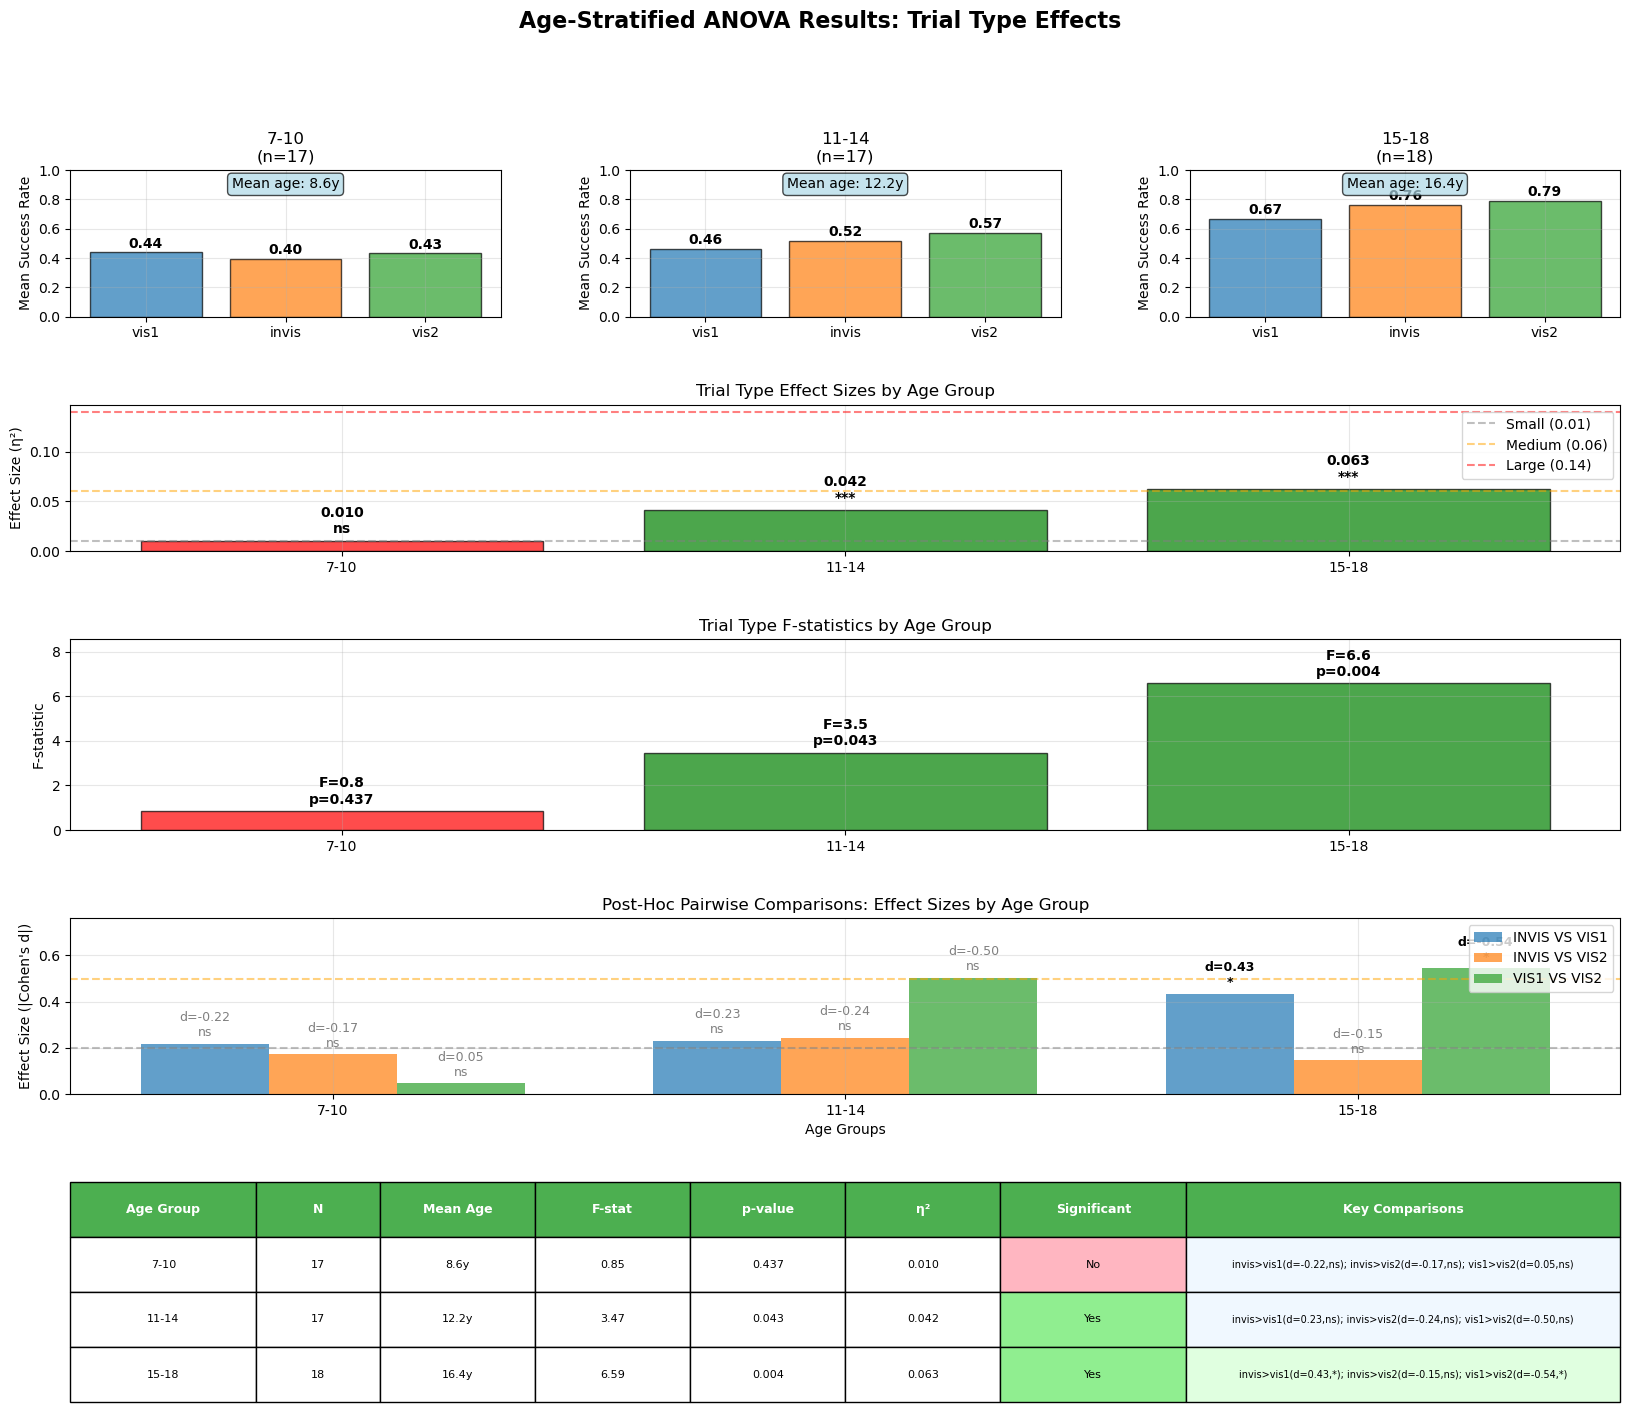

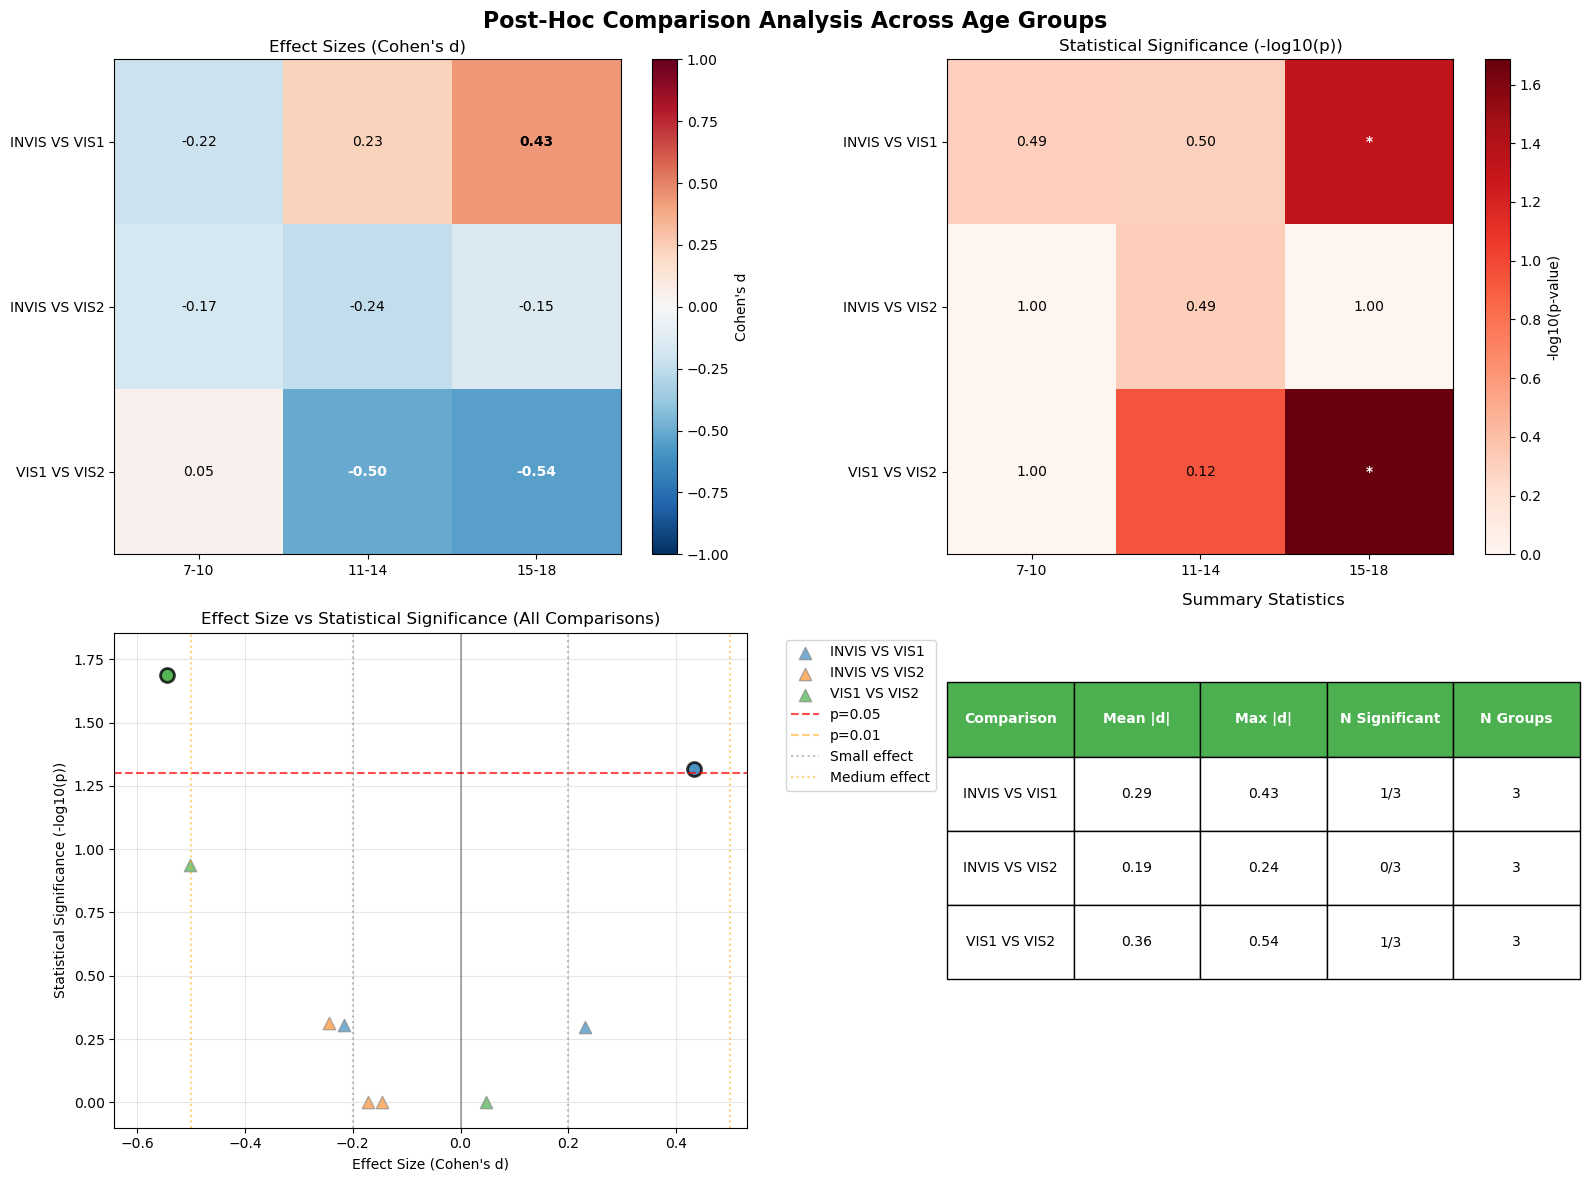

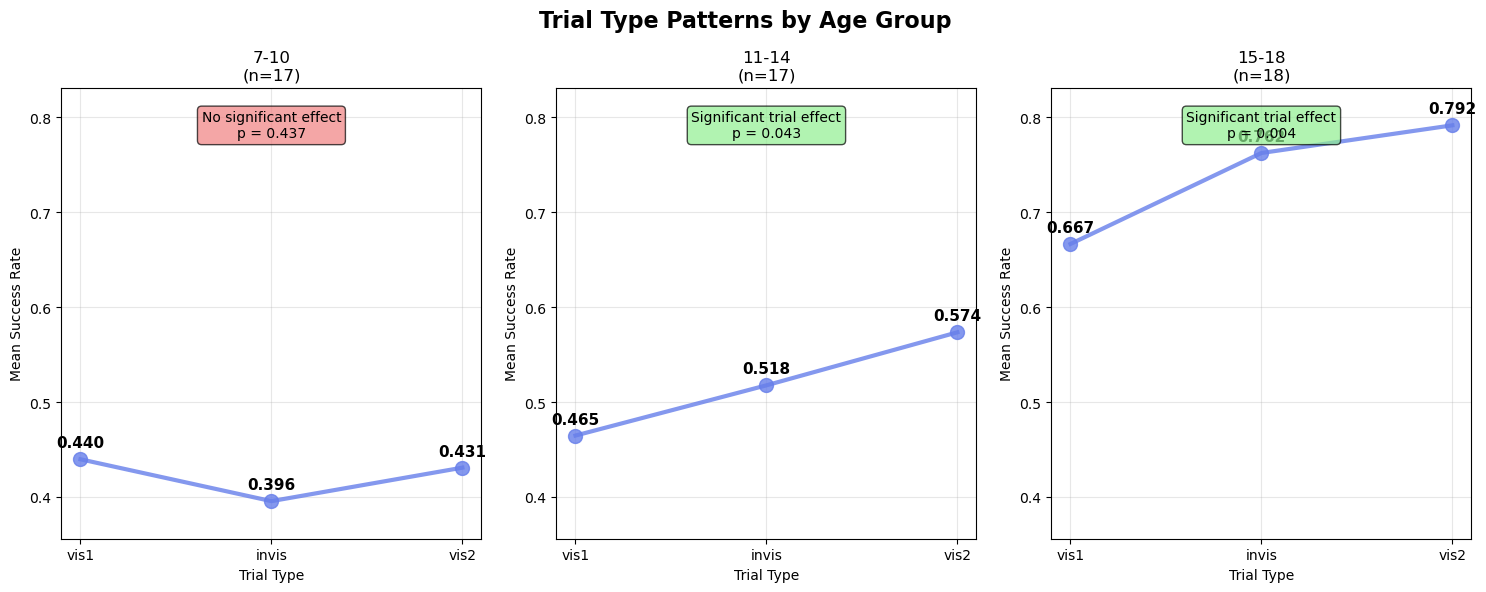

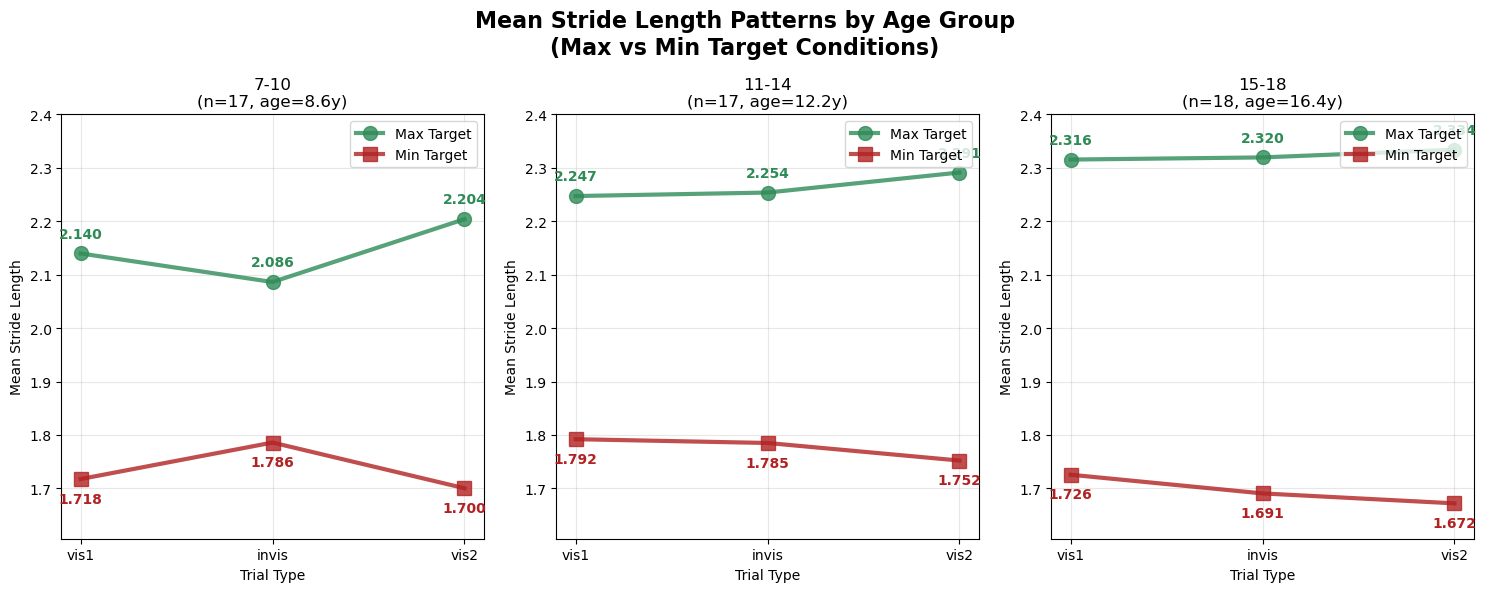

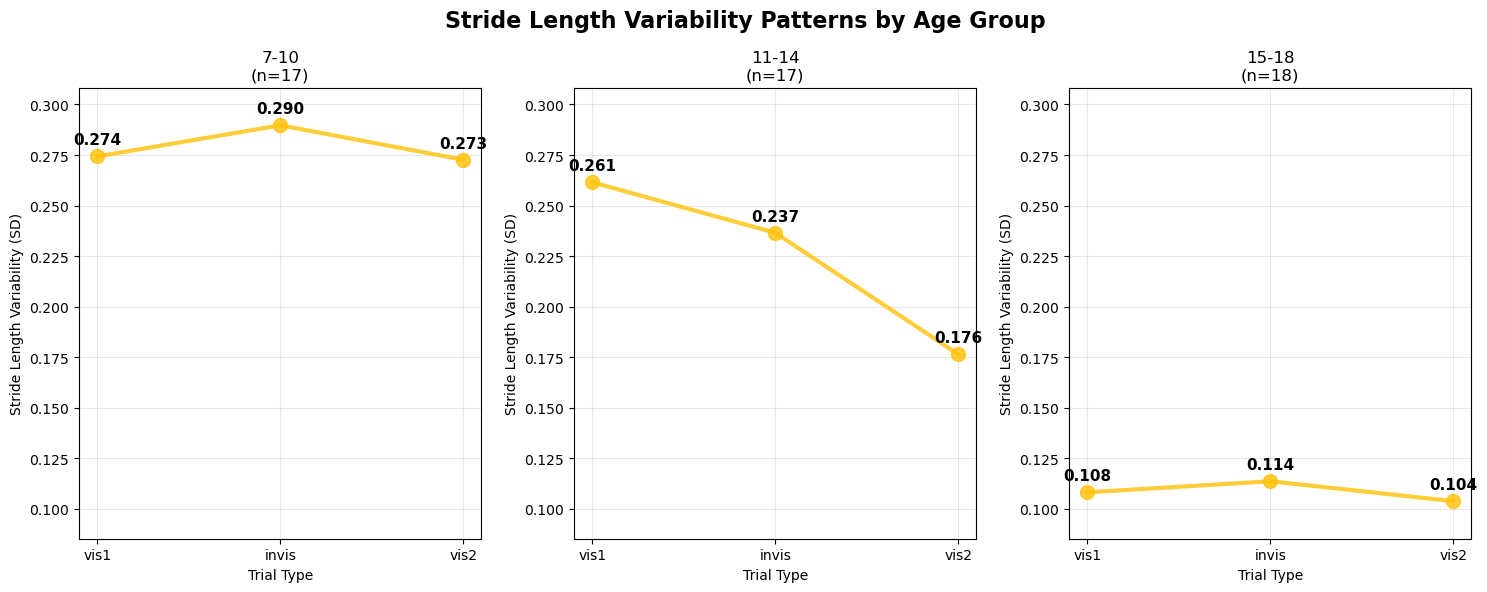

In [53]:
# Custom age groups if needed
custom_groups = {
    '7-10': [7, 10], 
    '11-14': [11, 14],
    '15-18': [15, 18]
}

custom_results = stats.run_age_stratified_anova(age_groups=custom_groups)

# Text report
#report = create_age_comparison_report(age_results)
#print(report)

# Visualizations (add to PopulationVisualizer)
# Enhanced main plot (now with post-hoc row)
fig1 = pop_viz.plot_age_stratified_results(custom_results, 'age_analysis_enhanced.png')

# Dedicated post-hoc heatmap
fig2 = pop_viz.plot_posthoc_heatmap(custom_results, 'posthoc_heatmap.png')

# Original trial patterns (with post-hoc annotations)
fig3 = pop_viz.plot_trial_patterns_by_age(custom_results, 'trial_patterns.png')

# Create individual pattern plots
print("Creating Mean Stride Length patterns by age group...")
fig_msl = pop_viz.plot_trial_patterns_msl_by_age(custom_results, 'trial_patterns_msl_by_age.png')

print("Creating Stride Variability patterns by age group...")
fig_sd = pop_viz.plot_trial_patterns_sd_by_age(custom_results, 'trial_patterns_sd_by_age.png')


Testing preparation analysis for subject MUH1085...

--- Testing vis1 trial ---
Result keys: ['n_successful_attempts', 'preparation_statistics', 'preparation_effectiveness', 'preparation_strategies', 'total_successes_in_trial']
Success! Result structure:
  n_successful_attempts: 211
  preparation_statistics: ['mean_prep_strides', 'mean_prep_variability', 'mean_distance_reduction', 'mean_direction_changes', 'mean_final_correction']
  preparation_effectiveness: ['correlation_prep_length_success', 'correlation_prep_variability_success', 'correlation_distance_reduction_success']
  preparation_strategies: ['converging_strategy_proportion', 'oscillating_strategy_proportion', 'direct_strategy_proportion']
  total_successes_in_trial: 212

Detailed results:
  Number of successful attempts analyzed: 211
  Total successes in trial: 212
  Preparation Statistics:
    mean_prep_strides: 4.972
    mean_prep_variability: 0.115
    mean_distance_reduction: 0.089
    mean_direction_changes: 2.123
    me

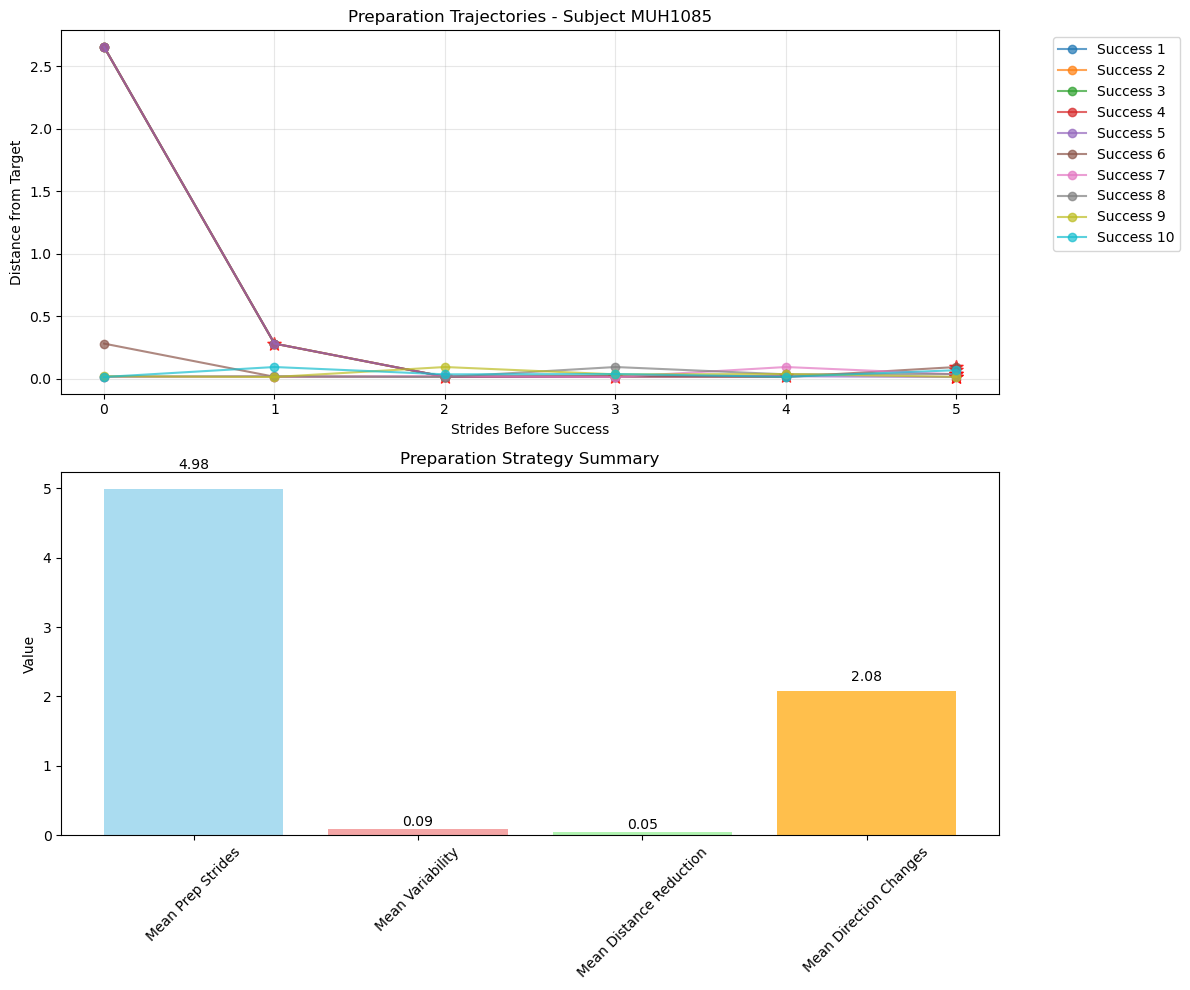

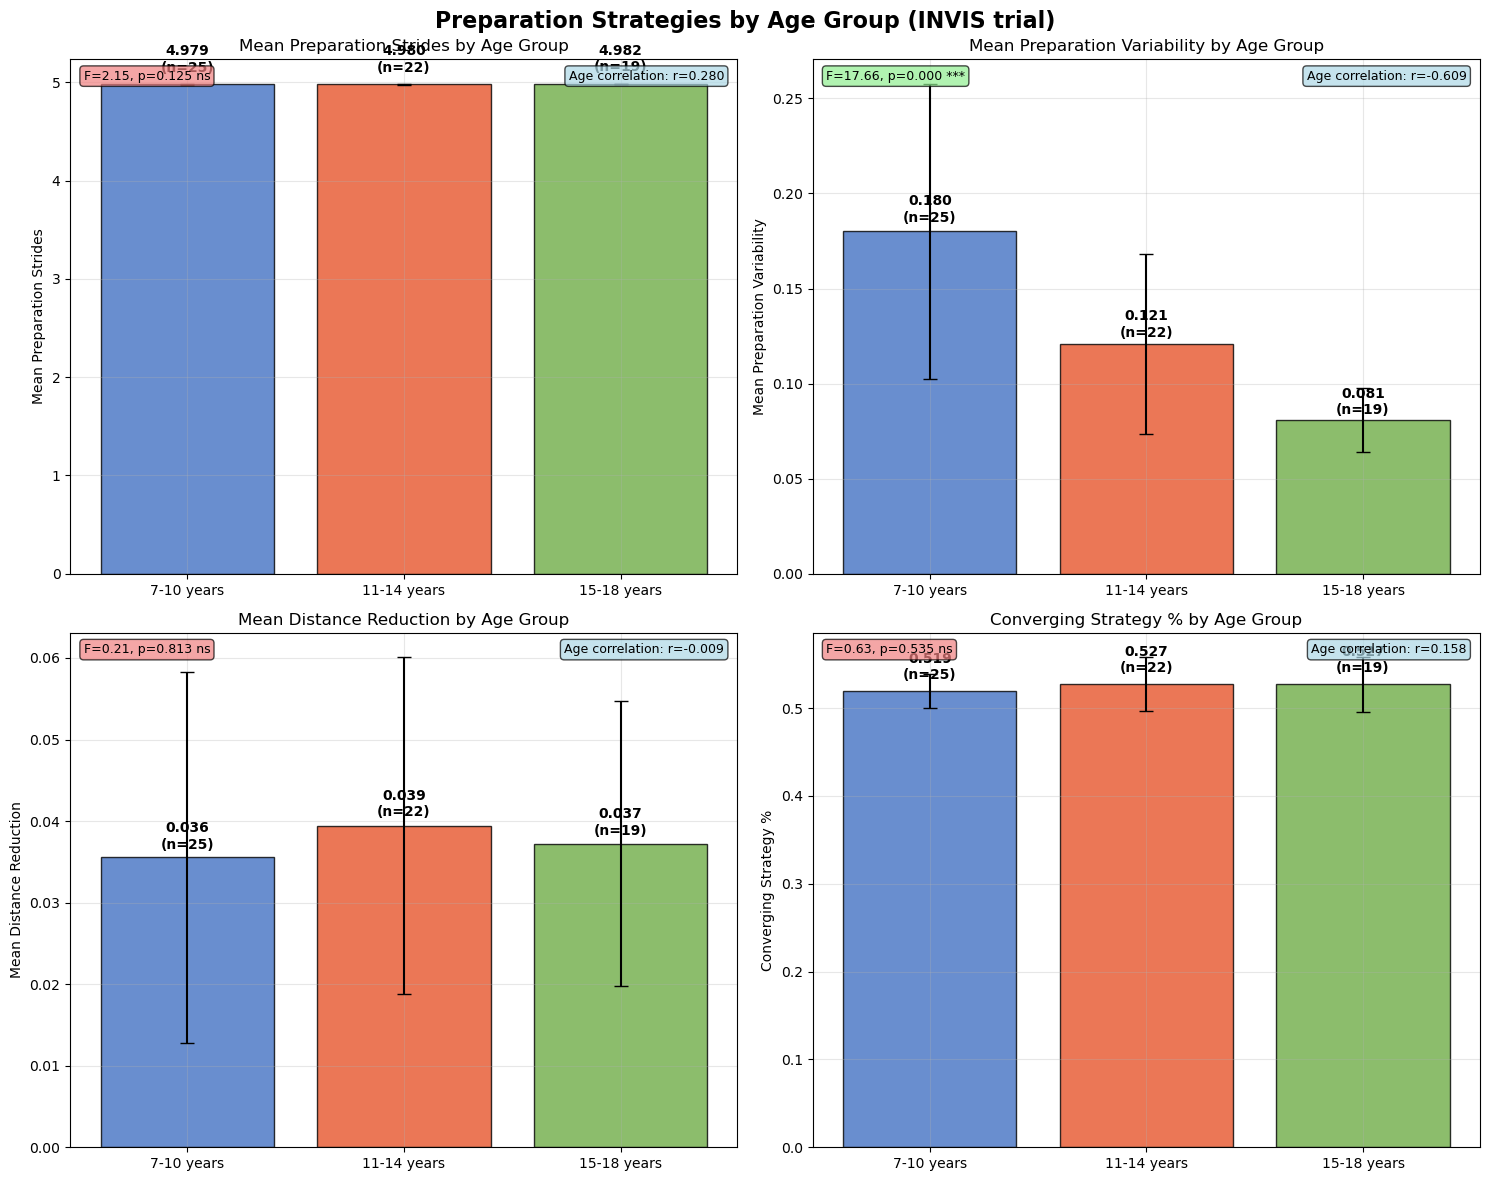

In [54]:
# Test the fixed preparation analysis
prep_analyzer = PreparationAnalysis(data_manager, analysis.config)

# Use an actual subject ID from your data
test_subject = 'MUH1085'  # From your debug output

print(f"Testing preparation analysis for subject {test_subject}...")

# Test with different trial types
for trial_type in ['vis1', 'invis', 'vis2']:
    print(f"\n--- Testing {trial_type} trial ---")
    prep_results = prep_analyzer.analyze_pre_success_patterns(test_subject, trial_type)
    
    print(f"Result keys: {list(prep_results.keys())}")
    
    if 'error' in prep_results:
        print(f"Error: {prep_results['error']}")
    else:
        print("Success! Result structure:")
        for key, value in prep_results.items():
            if isinstance(value, dict):
                print(f"  {key}: {list(value.keys())}")
            else:
                print(f"  {key}: {value}")
        
        # Show detailed results
        print(f"\nDetailed results:")
        print(f"  Number of successful attempts analyzed: {prep_results.get('n_successful_attempts', 'N/A')}")
        print(f"  Total successes in trial: {prep_results.get('total_successes_in_trial', 'N/A')}")
        
        if 'preparation_statistics' in prep_results:
            prep_stats = prep_results['preparation_statistics']
            print(f"  Preparation Statistics:")
            for stat_name, stat_value in prep_stats.items():
                print(f"    {stat_name}: {stat_value:.3f}" if isinstance(stat_value, (int, float)) else f"    {stat_name}: {stat_value}")
        
        if 'preparation_strategies' in prep_results:
            prep_strategies = prep_results['preparation_strategies']
            print(f"  Preparation Strategies:")
            for strategy_name, strategy_value in prep_strategies.items():
                print(f"    {strategy_name}: {strategy_value:.3f}" if isinstance(strategy_value, (int, float)) else f"    {strategy_name}: {strategy_value}")
        
        # Found working example, break
        break

# If the above works, test age comparison
print(f"\n{'='*60}")
print("Testing age comparison analysis...")

age_comparison = prep_analyzer.compare_preparation_strategies_by_age('invis')

if 'error' in age_comparison:
    print(f"Age comparison error: {age_comparison['error']}")
else:
    print("Age comparison successful!")
    print(f"Sample info: {age_comparison['sample_info']}")
    
    if 'group_statistics' in age_comparison:
        print(f"\nAge group statistics:")
        for group_name, group_data in age_comparison['group_statistics'].items():
            print(f"  {group_name}: n={group_data['n_subjects']}, mean_age={group_data['mean_age']:.1f}")

# Test visualization
print(f"\n{'='*60}")
print("Testing visualization...")

try:
    prep_viz = PreparationVisualizer(prep_analyzer, analysis.config)
    
    # Test individual trajectory plot
    fig1 = prep_viz.plot_preparation_trajectory(test_subject, 'invis', 
                                               analysis.config.individual_plots_dir / f'test_prep_trajectory_{test_subject}.png')
    
    if fig1:
        print(f"✓ Successfully created preparation trajectory plot")
    
    # Test age comparison plot
    fig2 = prep_viz.plot_age_vs_preparation_strategies('invis',
                                                      analysis.config.population_plots_dir / 'test_prep_strategies_by_age.png')
    
    if fig2:
        print(f"✓ Successfully created age comparison plot")
        
except Exception as e:
    print(f"Visualization error: {e}")
    import traceback
    traceback.print_exc()

print(f"\n{'='*60}")
print("Testing complete!")